In [75]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.signal import butter, filtfilt
from bfmtool.utils import get_bfm_columns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [76]:
df = pd.read_csv(r'Cleaned and combined/bfm_data.csv')

In [77]:
df['timestamp'] = pd.to_datetime(df.timestamp)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143214 entries, 0 to 143213
Columns: 477 entries, session_id to SCIDX_122_Ratio_Phase
dtypes: datetime64[ns, UTC](1), float64(468), object(8)
memory usage: 521.2+ MB


In [78]:
(df.timestamp.max() - df.timestamp.min()).total_seconds()

1267192.934337

In [79]:
df[df.session_id == '20251015_164911']

,session_id,environment,subject,activity,timestamp,receiver_address,destination_address,transmitter_address,source_address,SCIDX_-122_Ratio_Mag,...,SCIDX_113_Ratio_Phase,SCIDX_114_Ratio_Phase,SCIDX_115_Ratio_Phase,SCIDX_116_Ratio_Phase,SCIDX_117_Ratio_Phase,SCIDX_118_Ratio_Phase,SCIDX_119_Ratio_Phase,SCIDX_120_Ratio_Phase,SCIDX_121_Ratio_Phase,SCIDX_122_Ratio_Phase
47540,20251015_164911,foil,matthew,standing,2025-10-15 08:47:37.326462030+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,0.192541,...,4.865787,4.816700,4.792156,4.755340,4.743069,4.730797,4.681709,4.632622,4.632622,4.595806
47541,20251015_164911,foil,matthew,standing,2025-10-15 08:47:37.374907970+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,5.560376,...,0.607456,0.607456,0.595185,0.595185,0.595185,0.595185,0.582913,0.582913,0.582913,0.570641
47542,20251015_164911,foil,matthew,standing,2025-10-15 08:47:37.471718073+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,5.560376,...,0.619728,0.607456,0.607456,0.595185,0.595185,0.595185,0.582913,0.582913,0.582913,0.582913
47543,20251015_164911,foil,matthew,standing,2025-10-15 08:47:37.568948030+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,5.560376,...,0.619728,0.607456,0.607456,0.607456,0.607456,0.595185,0.595185,0.582913,0.582913,0.582913
47544,20251015_164911,foil,matthew,standing,2025-10-15 08:47:37.685987949+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,5.193689,...,0.619728,0.619728,0.607456,0.607456,0.607456,0.607456,0.595185,0.595185,0.595185,0.582913
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48561,20251015_164911,foil,matthew,standing,2025-10-15 08:49:07.511028051+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,0.558416,...,-1.368311,-1.368311,-1.392855,-1.392855,-1.380583,-1.392855,-1.417398,-1.441942,-1.417398,-1.429670
48562,20251015_164911,foil,matthew,standing,2025-10-15 08:49:07.525028944+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,7.717699,...,0.619728,0.619728,0.607456,0.607456,0.607456,0.607456,0.607456,0.607456,0.607456,0.607456
48563,20251015_164911,foil,matthew,standing,2025-10-15 08:49:07.624114037+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,7.717699,...,0.619728,0.619728,0.619728,0.619728,0.619728,0.619728,0.619728,0.619728,0.619728,0.619728
48564,20251015_164911,foil,matthew,standing,2025-10-15 08:49:07.721910+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,7.717699,...,0.619728,0.619728,0.619728,0.619728,0.619728,0.619728,0.619728,0.619728,0.632000,0.632000


In [80]:
# Exclude session '20251016_183114' - identified as corrupted/anomalous during data collection
df = df.loc[df.session_id != '20251016_183114']

df['timestamp_s'] = (df.timestamp - df.timestamp.min()).dt.total_seconds()

df.groupby('session_id').session_id.count().sum() / (df.groupby('session_id').timestamp_s.max() - df.groupby('session_id').timestamp_s.min()).sum()

10.623727173660313

In [81]:
df.groupby('session_id').session_id.count().mean()

960.8456375838927

In [82]:
(df.groupby('session_id').timestamp_s.max() - df.groupby('session_id').timestamp_s.min()).mean()

90.44336529708167

In [83]:

cols = get_bfm_columns(df)
mag_cols = cols['mag_col']
phase_cols = cols['phase_col']


In [84]:
cols.keys()

dict_keys(['real_col', 'real_scidx', 'imag_col', 'imag_scidx', 'mag_col', 'mag_scidx', 'phase_col', 'phase_scidx'])

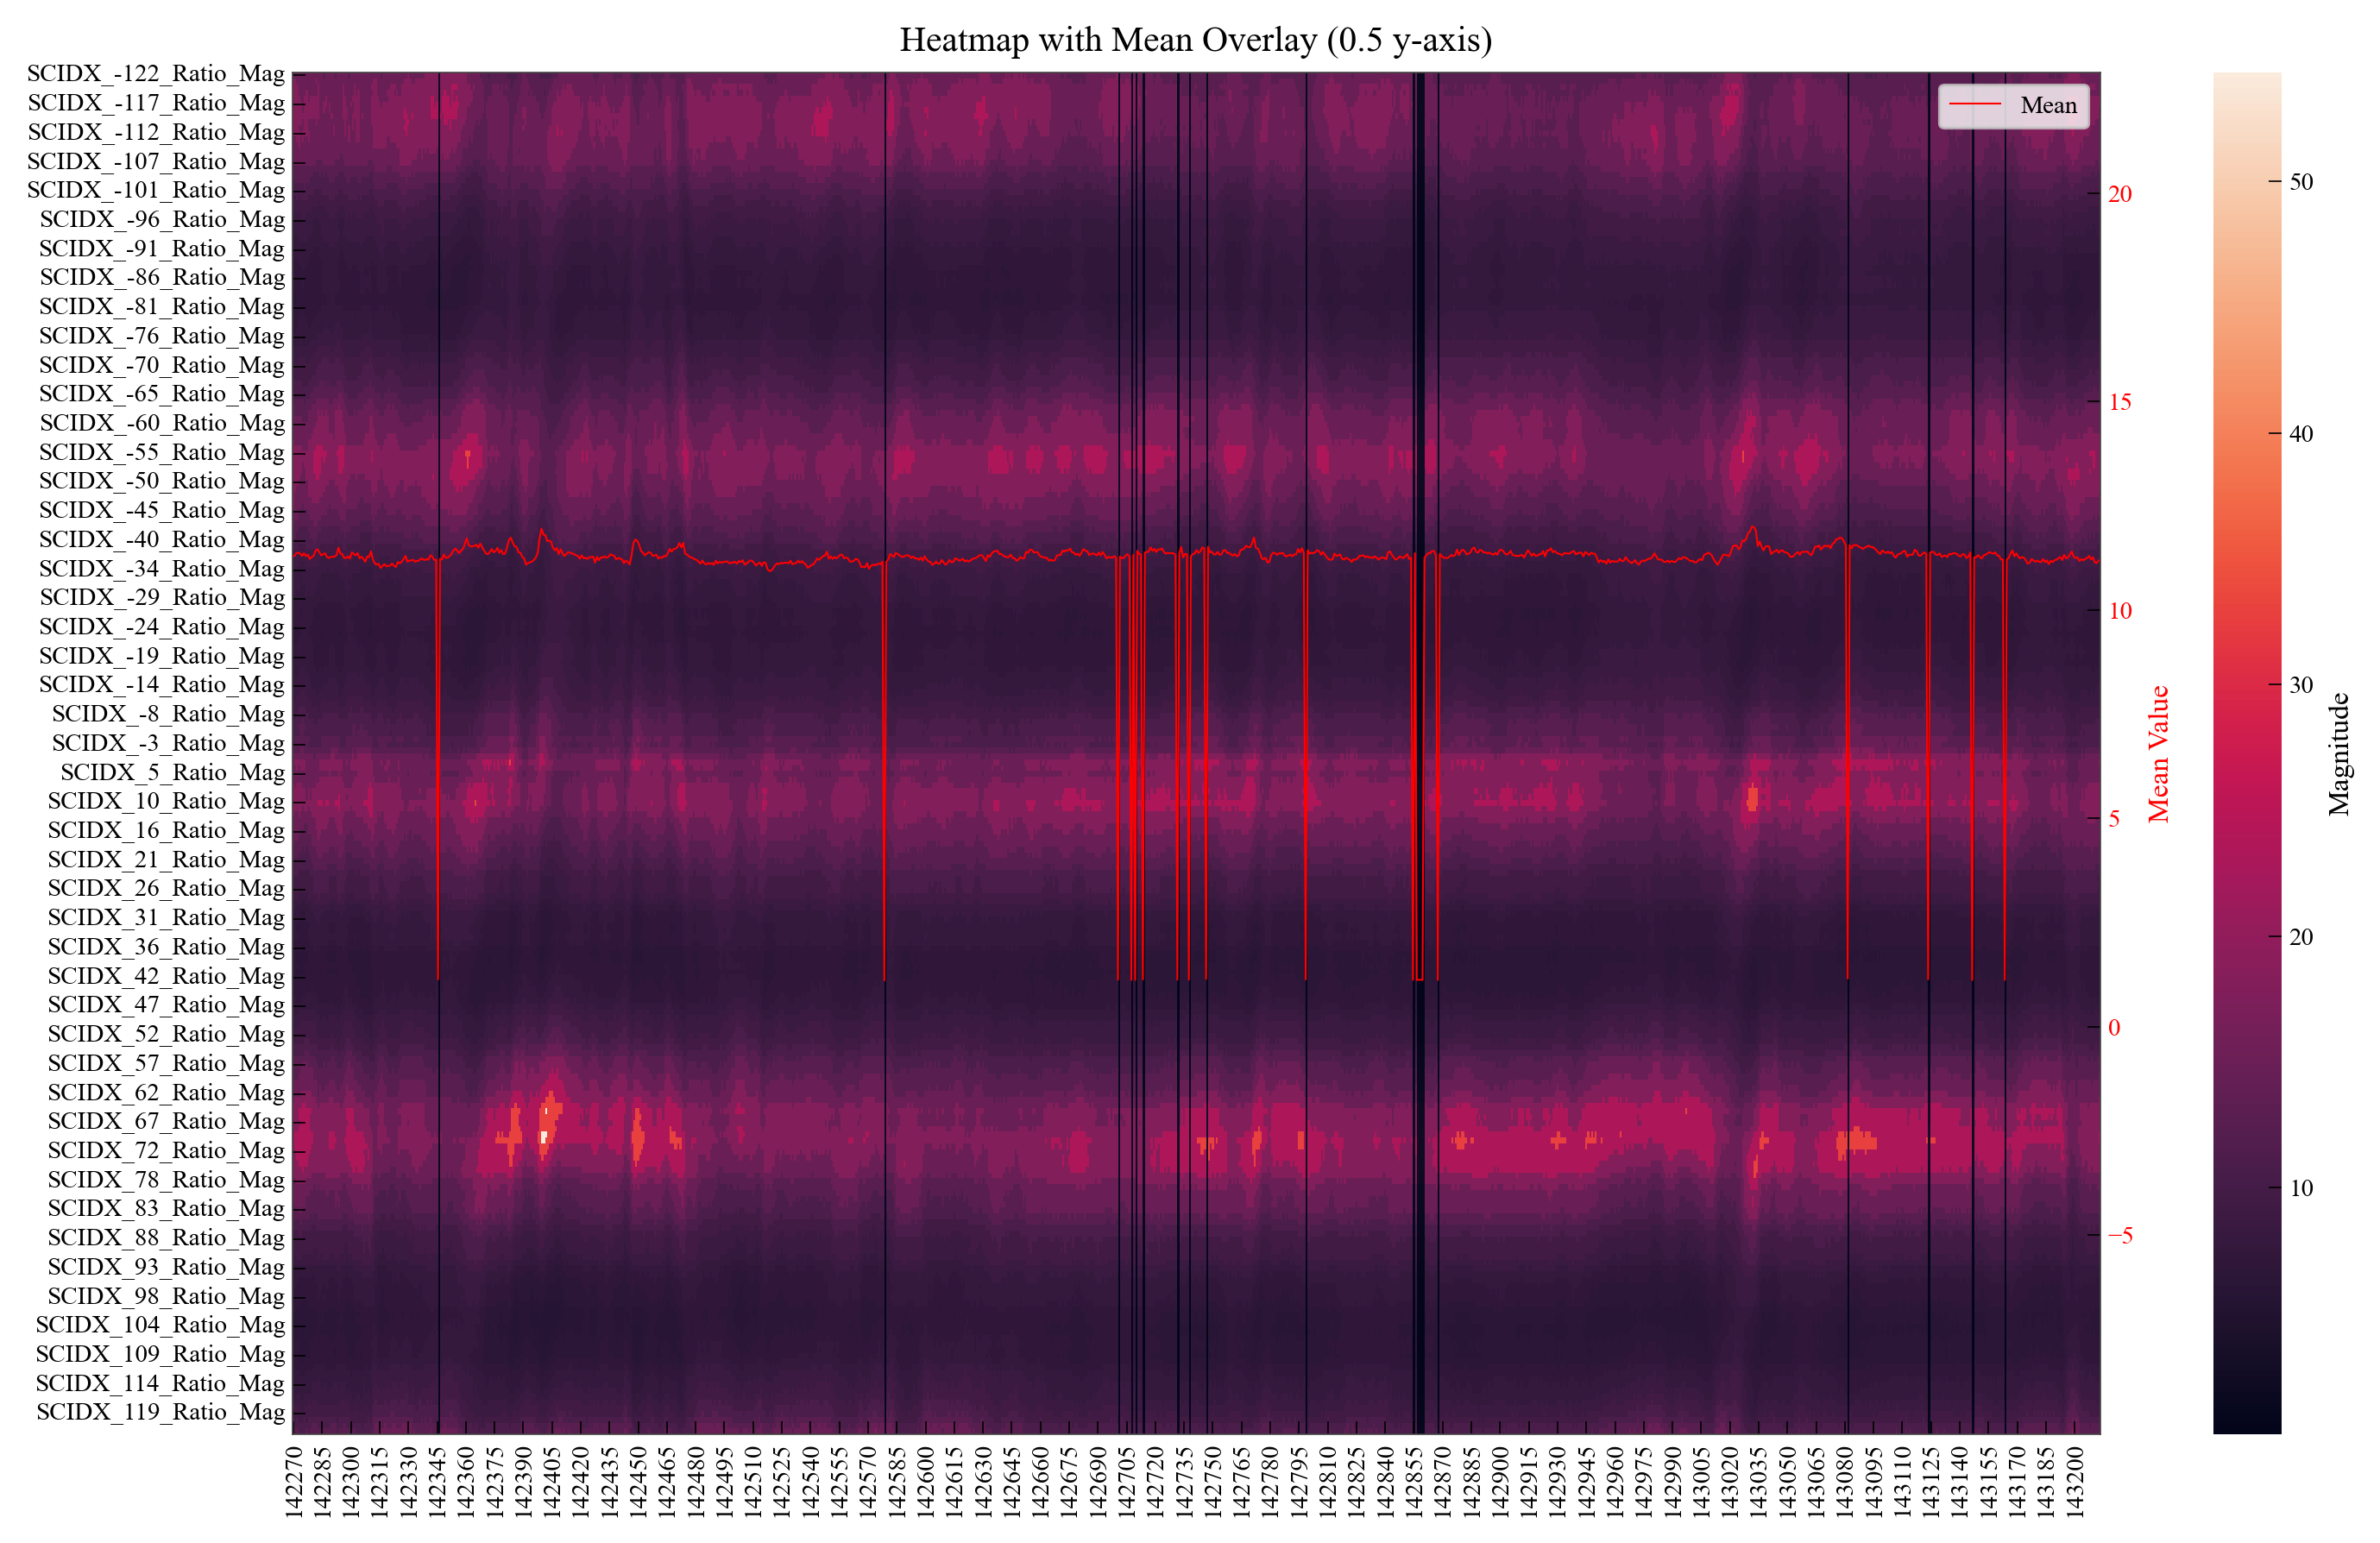

In [85]:

# df_selected = df[(df.environment == 'nofoil') & (np.isin(df.subject, ['matthew', 'collin', 'kenny']))]
df_selected = df[(df.session_id == '20251024_100806')]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Create the heatmap
sns.heatmap(df_selected[mag_cols].T, ax=ax1, cbar_kws={'label': 'Magnitude'})

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Calculate mean values
mean_values = df_selected[mag_cols].mean(axis=1)

# Plot the line on the second axis
sns.lineplot(x=np.arange(len(df_selected)), 
             y=mean_values, 
             ax=ax2, 
             color='red', 
             linewidth=0.5, 
             label='Mean')

# Stretch the y-axis so the mean line only uses bottom 50%
y_min, y_max = mean_values.min(), mean_values.max()
y_range = y_max - y_min
# Expand the axis limits so the data range fits in 50% of the plot
ax2.set_ylim(y_min - y_range, y_max + y_range)

# Align x-axis with heatmap
ax2.set_xlim(ax1.get_xlim())

# Optional: styling
ax2.set_ylabel('Mean Value', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Heatmap with Mean Overlay (0.5 y-axis)')
plt.tight_layout()
plt.show()

IEEE-style comparison plot saved as:
  - 'circular_mean_phase_comparison.png' (300 DPI)
  - 'circular_mean_phase_comparison.pdf' (vector format)


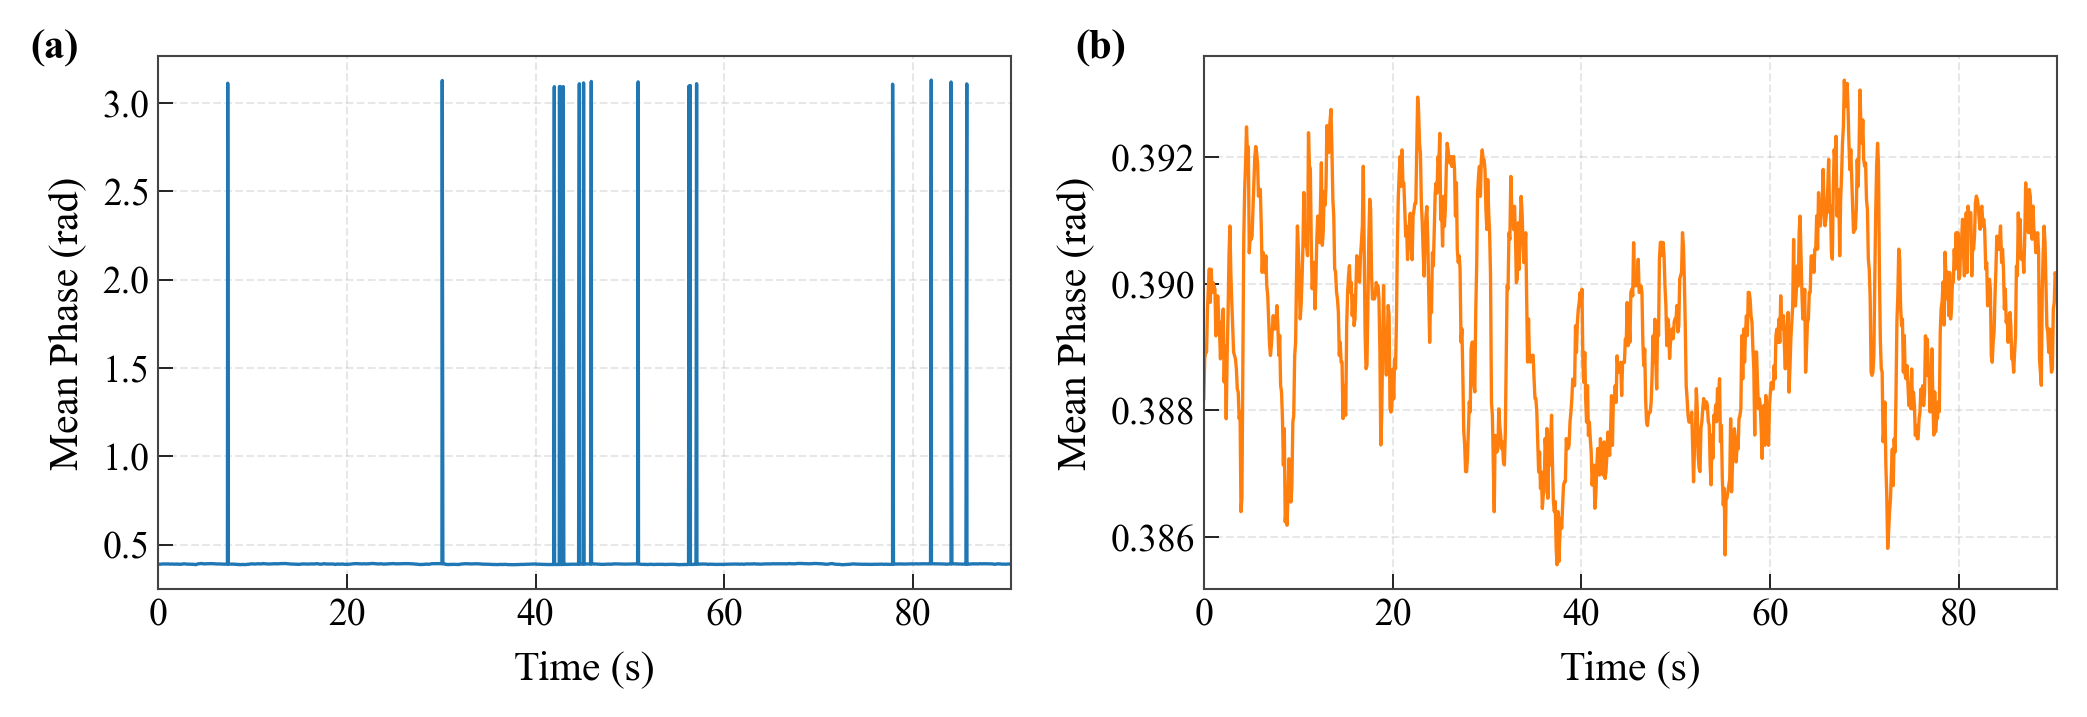

In [86]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

# Set IEEE-style plot parameters
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
})


import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

# Set IEEE-style plot parameters

# --- Setup ---
df_selected = df[df.session_id == '20251024_100806']
phases_df = df_selected[phase_cols]

# Calculate circular mean phase
mean_sin = np.sin(phases_df).mean(axis=1)
mean_cos = np.cos(phases_df).mean(axis=1)
circular_mean_phase = np.arctan2(mean_sin, mean_cos)

# Convert timestamp to Time (s) for full data
if df_selected['timestamp'].dtype == 'object':
    timestamps_full = pd.to_datetime(df_selected['timestamp'])
else:
    timestamps_full = df_selected['timestamp']

# Calculate time in seconds from start for full data
time_seconds_full = (timestamps_full - timestamps_full.iloc[0]).dt.total_seconds()

# Filter cleaned data
df_cleaned = df_selected[df_selected[mag_cols].mean(axis=1) > 5]

# Recalculate circular mean for cleaned data
phases_df_cleaned = df_cleaned[phase_cols]
mean_sin_cleaned = np.sin(phases_df_cleaned).mean(axis=1)
mean_cos_cleaned = np.cos(phases_df_cleaned).mean(axis=1)
circular_mean_phase_cleaned = np.arctan2(mean_sin_cleaned, mean_cos_cleaned)

# Convert timestamp to Time (s) for cleaned data
if df_cleaned['timestamp'].dtype == 'object':
    timestamps_cleaned = pd.to_datetime(df_cleaned['timestamp'])
else:
    timestamps_cleaned = df_cleaned['timestamp']

# Calculate time in seconds from start for cleaned data (same reference point)
time_seconds_cleaned = (timestamps_cleaned - timestamps_full.iloc[0]).dt.total_seconds()

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

# --- Subplot (a): Full data with Time (s) ---
axes[0].plot(time_seconds_full.values, circular_mean_phase.values, color='#1f77b4', linewidth=0.8)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Mean Phase (rad)')
axes[0].grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
axes[0].set_xlim(time_seconds_full.min(), time_seconds_full.max())

# Add subplot label (a)
axes[0].text(-0.15, 1.05, '(a)', transform=axes[0].transAxes, 
             fontsize=10, fontweight='bold', va='top')

# --- Subplot (b): Cleaned data with Time (s) ---
axes[1].plot(time_seconds_cleaned.values, circular_mean_phase_cleaned.values, color='#ff7f0e', linewidth=0.8)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Mean Phase (rad)')
axes[1].grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
axes[1].set_xlim(time_seconds_full.min(), time_seconds_full.max())

# Add subplot label (b)
axes[1].text(-0.15, 1.05, '(b)', transform=axes[1].transAxes, 
             fontsize=10, fontweight='bold', va='top')

# Adjust layout to prevent overlap
plt.tight_layout()

# Save figure with high DPI for publication quality
# plt.savefig('circular_mean_phase_comparison.png', dpi=300, bbox_inches='tight')
# plt.savefig('circular_mean_phase_comparison.pdf', bbox_inches='tight')

print("IEEE-style comparison plot saved as:")
print("  - 'circular_mean_phase_comparison.png' (300 DPI)")
print("  - 'circular_mean_phase_comparison.pdf' (vector format)")

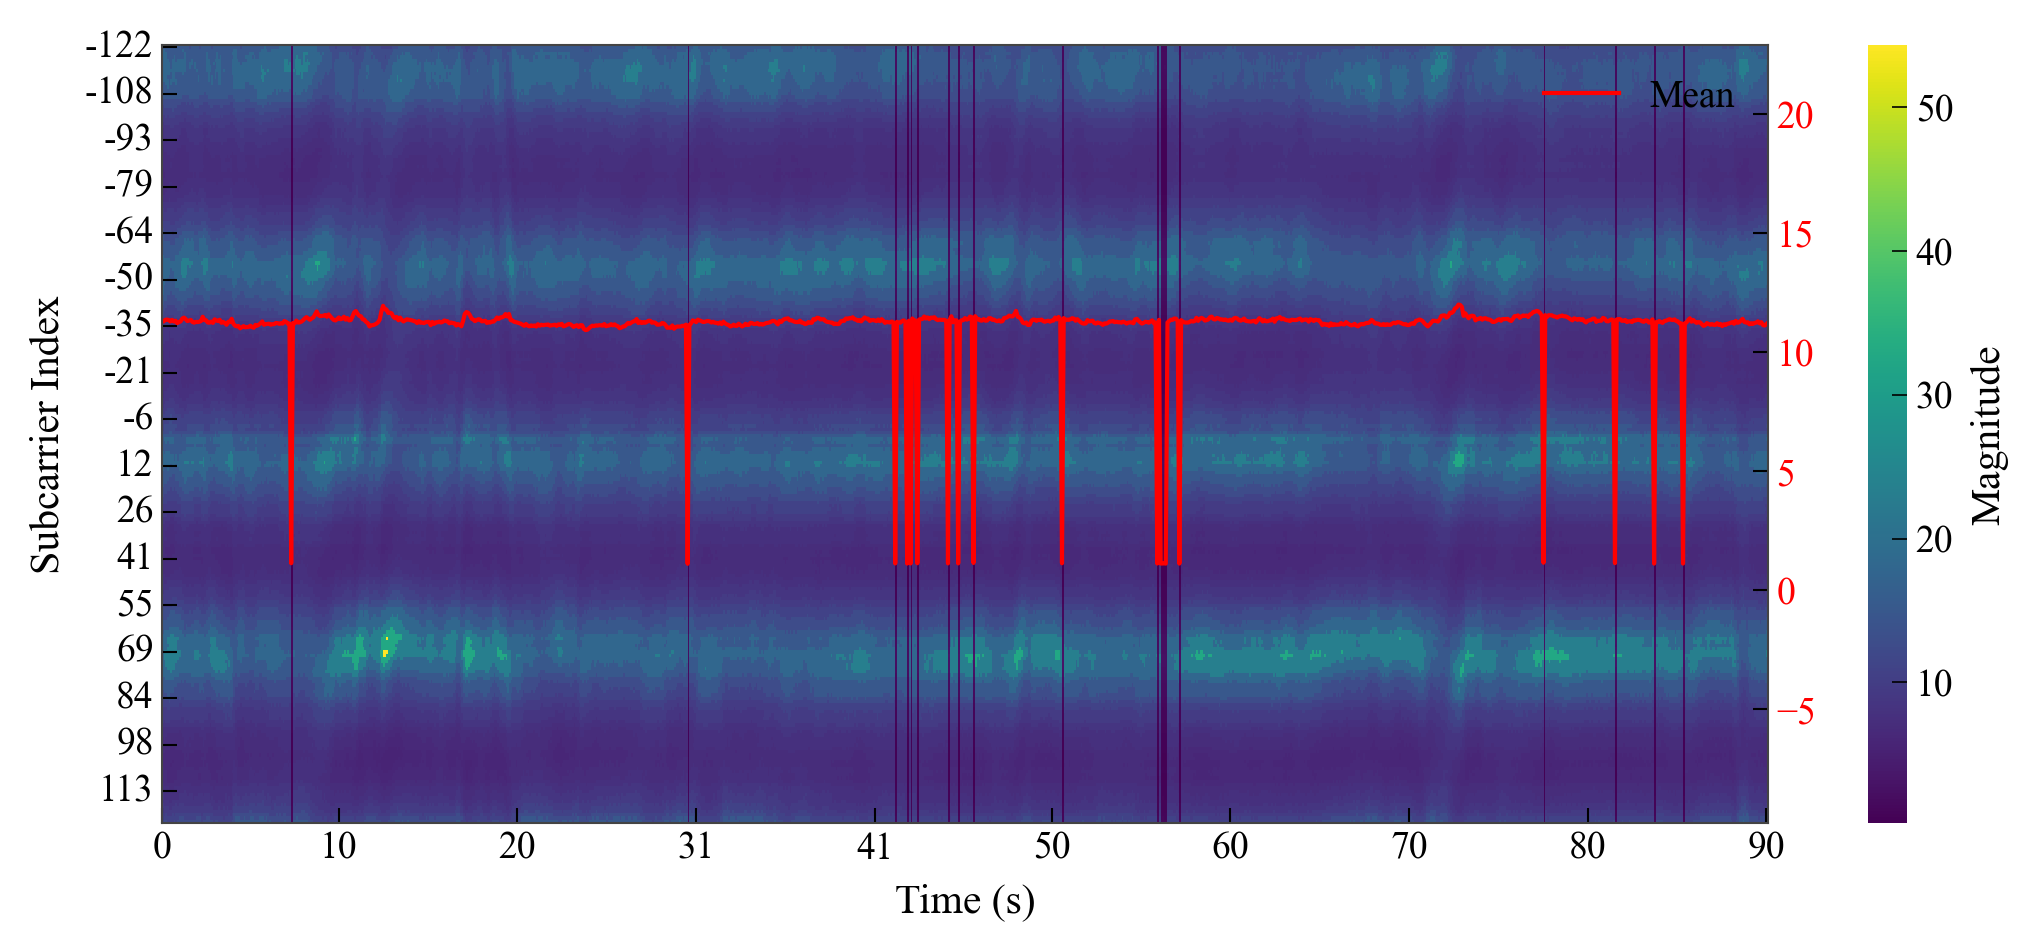

In [87]:
df_selected = df.loc[(df.session_id == '20251024_100806'), mag_cols + ['timestamp']].copy()
df_selected = df_selected.rename(columns = pd.Series(cols['mag_scidx'], index = mag_cols))
df_selected.index = (df_selected.timestamp - df_selected.timestamp.iloc[0]).dt.total_seconds()

# IEEE standard plot settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
})

# IEEE standard two-column width: 7.16 inches
fig, ax1 = plt.subplots(figsize=(7.16, 3.0))

# Create the heatmap
sns.heatmap(df_selected[cols['mag_scidx']].T, ax=ax1, 
            cbar_kws={'label': 'Magnitude'},
            cmap='viridis',
            xticklabels=False)  # Disable seaborn's default labels

# Create a second y-axis
ax2 = ax1.twinx()

# Calculate mean values
mean_values = df_selected[cols['mag_scidx']].mean(axis=1)

# Plot the line on the second axis
ax2.plot(np.arange(len(df_selected)), 
         mean_values,
         color='red', 
         linewidth=1.0, 
         label='Mean')

# Stretch the y-axis so the mean line only uses bottom 50%
y_min, y_max = mean_values.min(), mean_values.max()
y_range = y_max - y_min
ax2.set_ylim(y_min - y_range, y_max + y_range)

# Align x-axis with heatmap
ax2.set_xlim(ax1.get_xlim())

# Set custom x-axis ticks with proper formatting
# Get the actual time values from the index
time_values = df_selected.index.values
x_positions = np.arange(len(df_selected))

# Create evenly spaced ticks (e.g., every ~10 seconds or adjust as needed)
num_ticks = 10  # Adjust this for more/fewer labels
tick_indices = np.linspace(0, len(df_selected)-1, num_ticks, dtype=int)
tick_positions = x_positions[tick_indices]
tick_labels = [f'{time_values[i]:.0f}' for i in tick_indices]  # No decimal places

ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels)

# Labels (IEEE style - clear and concise)
# Standard convention: "Time (s)" or "Time [s]"
ax1.set_xlabel('Time (s)')  # IEEE prefers parentheses for units
ax1.set_ylabel('Subcarrier Index')
ax2.tick_params(axis='y', labelcolor='red', width=0.5)
ax1.tick_params(width=0.5)

# Legend with no frame (IEEE style)
legend = ax2.legend(loc='upper right', frameon=False)

plt.tight_layout(pad=0.1)

# Save as PDF (IEEE prefers vector format)
# plt.savefig('heatmap_overlay.pdf', bbox_inches='tight', pad_inches=0.01)
plt.show()

In [88]:
df.loc[(df.session_id == '20251009_180944')]

,session_id,environment,subject,activity,timestamp,receiver_address,destination_address,transmitter_address,source_address,SCIDX_-122_Ratio_Mag,...,SCIDX_114_Ratio_Phase,SCIDX_115_Ratio_Phase,SCIDX_116_Ratio_Phase,SCIDX_117_Ratio_Phase,SCIDX_118_Ratio_Phase,SCIDX_119_Ratio_Phase,SCIDX_120_Ratio_Phase,SCIDX_121_Ratio_Phase,SCIDX_122_Ratio_Phase,timestamp_s
0,20251009_180944,nofoil,kenny,standing,2025-10-09 10:08:10.345310926+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,2.148330,...,0.153398,0.116583,0.128854,0.104311,0.116583,0.104311,0.104311,0.079767,0.067495,0.000000
1,20251009_180944,nofoil,kenny,standing,2025-10-09 10:08:10.400350094+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,18.089884,...,0.018408,0.018408,0.018408,0.018408,0.018408,0.018408,0.006136,0.006136,0.006136,0.055039
2,20251009_180944,nofoil,kenny,standing,2025-10-09 10:08:10.500664949+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,18.089884,...,0.018408,0.006136,0.018408,0.006136,0.006136,0.006136,0.006136,0.006136,0.779262,0.155354
3,20251009_180944,nofoil,kenny,standing,2025-10-09 10:08:10.597796917+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,18.089884,...,0.018408,0.018408,0.018408,0.018408,0.006136,0.006136,0.006136,0.006136,0.779262,0.252486
4,20251009_180944,nofoil,kenny,standing,2025-10-09 10:08:10.693922043+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,18.089884,...,0.018408,0.018408,0.018408,0.006136,0.006136,0.006136,0.006136,0.006136,0.006136,0.348611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
966,20251009_180944,nofoil,kenny,standing,2025-10-09 10:09:40.443325043+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,23.267776,...,0.067495,0.055223,0.055223,0.042951,0.030680,0.018408,0.006136,0.779262,0.779262,90.098014
967,20251009_180944,nofoil,kenny,standing,2025-10-09 10:09:40.560925007+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,32.584705,...,0.067495,0.055223,0.055223,0.042951,0.042951,0.030680,0.018408,0.006136,0.779262,90.215614
968,20251009_180944,nofoil,kenny,standing,2025-10-09 10:09:40.613593102+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,3.225184,...,0.558369,0.460194,0.447922,0.374291,0.288388,0.239301,0.202485,0.079767,-0.030680,90.268282
969,20251009_180944,nofoil,kenny,standing,2025-10-09 10:09:40.661818027+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,23.267776,...,0.067495,0.055223,0.055223,0.042951,0.042951,0.030680,0.030680,0.006136,0.779262,90.316507


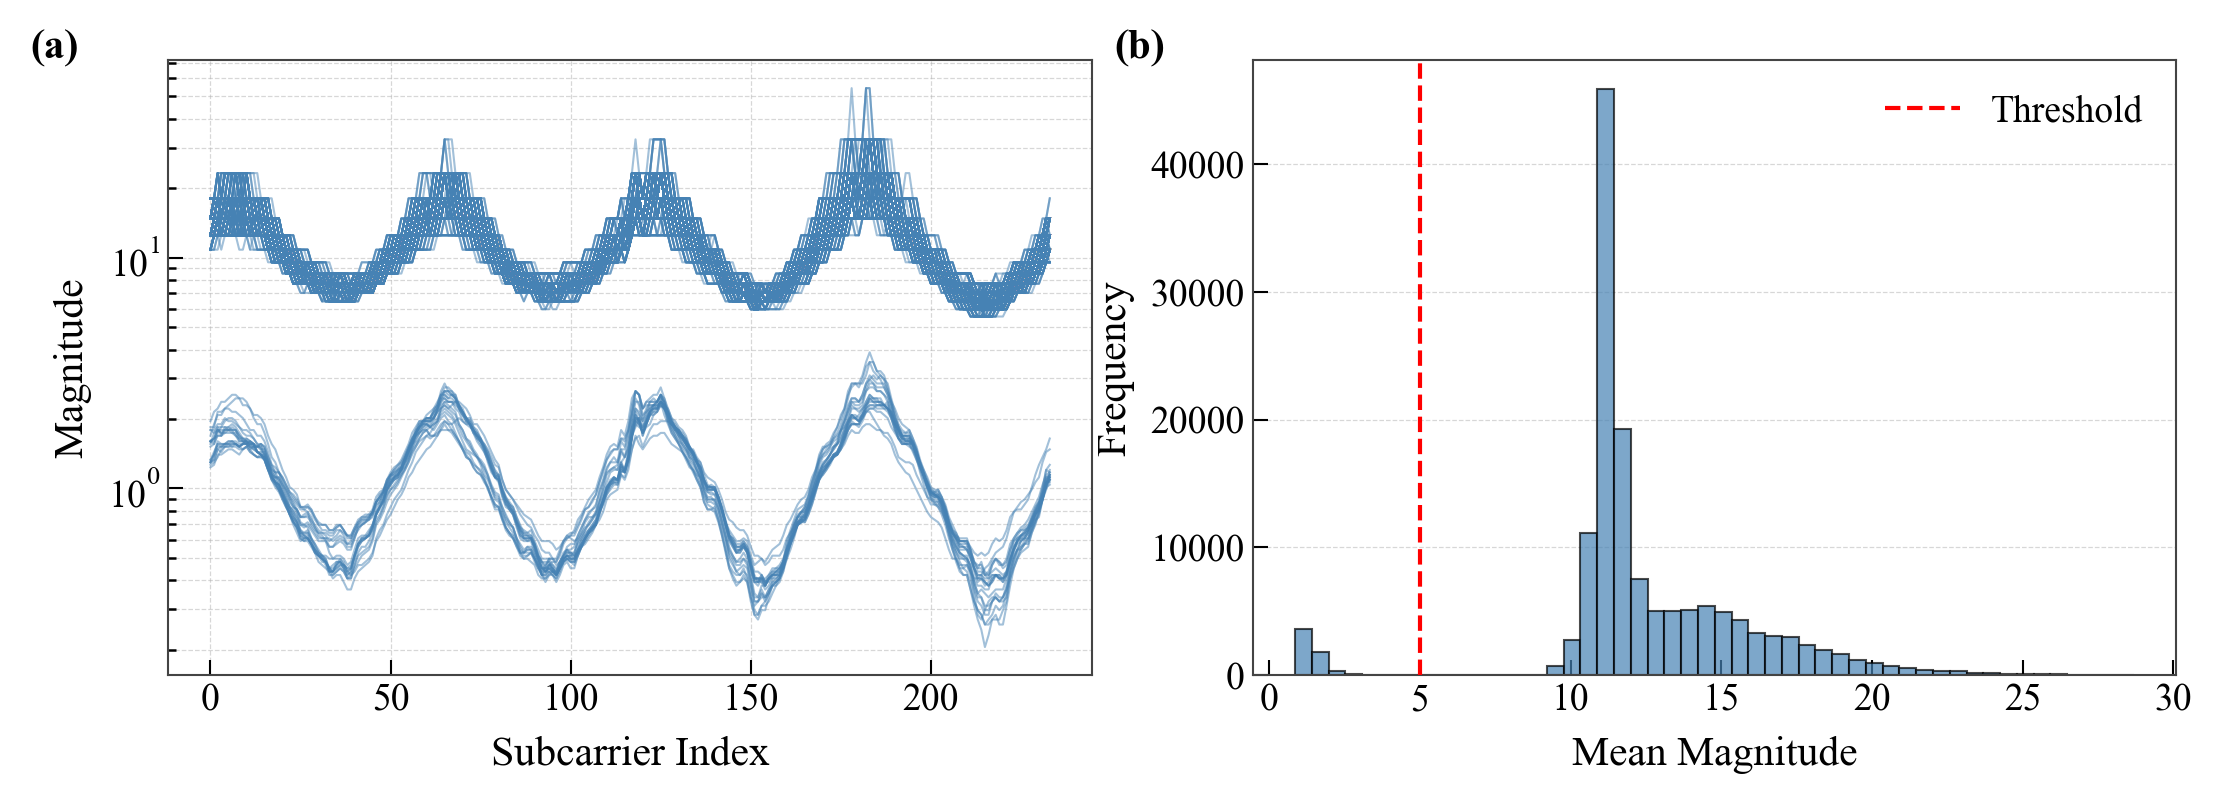

In [89]:
import numpy as np
# Note: pandas and other necessary imports (df, mag_cols, cols) 
# are assumed to be available from preceding cells.
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

# --- IEEE standard plot settings (Unchanged) ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
})

# --- Create figure with enhanced spacing ---
# Use w_pad or adjust layout after creation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.16, 2.5)) 

# --- Left plot (a): Overlaid line plots (Magnitude Profiles) ---
# Assuming df_selected is filtered and available from previous step
for i in range(len(df_selected)):
    # Assuming 'cols' and 'df_selected' contain the necessary BFM ratio data
    ax1.plot(df_selected.iloc[i][cols['mag_scidx']].values, 
             color='steelblue', 
             alpha=0.5, 
             linewidth=0.5)

ax1.set_yscale('log')
ax1.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(1, 10), numticks=100))
ax1.yaxis.set_minor_formatter(NullFormatter())
ax1.set_xlabel('Subcarrier Index')
ax1.set_ylabel('Magnitude')
ax1.tick_params(width=0.5)
ax1.grid(True, linestyle='--', alpha=0.5, linewidth=0.3, which='both')

# Add (a) label
ax1.text(-0.15, 1.05, '(a)', transform=ax1.transAxes, 
         fontsize=10, fontweight='bold', va='top')

# --- Right plot (b): Histogram with threshold line ---
# Assuming 'df' contains the full data and 'mag_cols' are available
mean_magnitudes = df[mag_cols].mean(axis=1)
threshold = 5

ax2.hist(mean_magnitudes, 
         bins=50, 
         color='steelblue', 
         alpha=0.7, 
         edgecolor='black', 
         linewidth=0.5,
         zorder=2)

# Add threshold line
ax2.axvline(x=threshold, color='red', linestyle='--', linewidth=1, label='Threshold', zorder=4)

ax2.set_xlabel('Mean Magnitude')
ax2.set_ylabel('Frequency')
ax2.tick_params(width=0.5)

# Grid with higher zorder to appear on top of histogram bars
ax2.grid(True, linestyle='--', alpha=0.5, linewidth=0.3, axis='y', zorder=5)
ax2.legend(loc='upper right', frameon=False) # IEEE prefers no frame on legend

# Add (b) label
ax2.text(-0.15, 1.05, '(b)', transform=ax2.transAxes, 
         fontsize=10, fontweight='bold', va='top')

# --- Improvement: Adjust Subplot Spacing ---
# Use plt.subplots_adjust to manually increase the width space (wspace) between plots.
# Setting wspace > 0.3 typically resolves crowding issues in dual-column figures.
plt.subplots_adjust(wspace=0.45) # Increased horizontal spacing for the long Y-label.

# Final layout adjustment
plt.tight_layout(pad=0.1)

# Save as PDF
# plt.savefig('combined_plots_fixed.pdf', bbox_inches='tight', pad_inches=0.01)
plt.show()

IEEE-style comparison plot saved as:
  - 'circular_mean_phase_comparison.png' (300 DPI)
  - 'circular_mean_phase_comparison.pdf' (vector format)


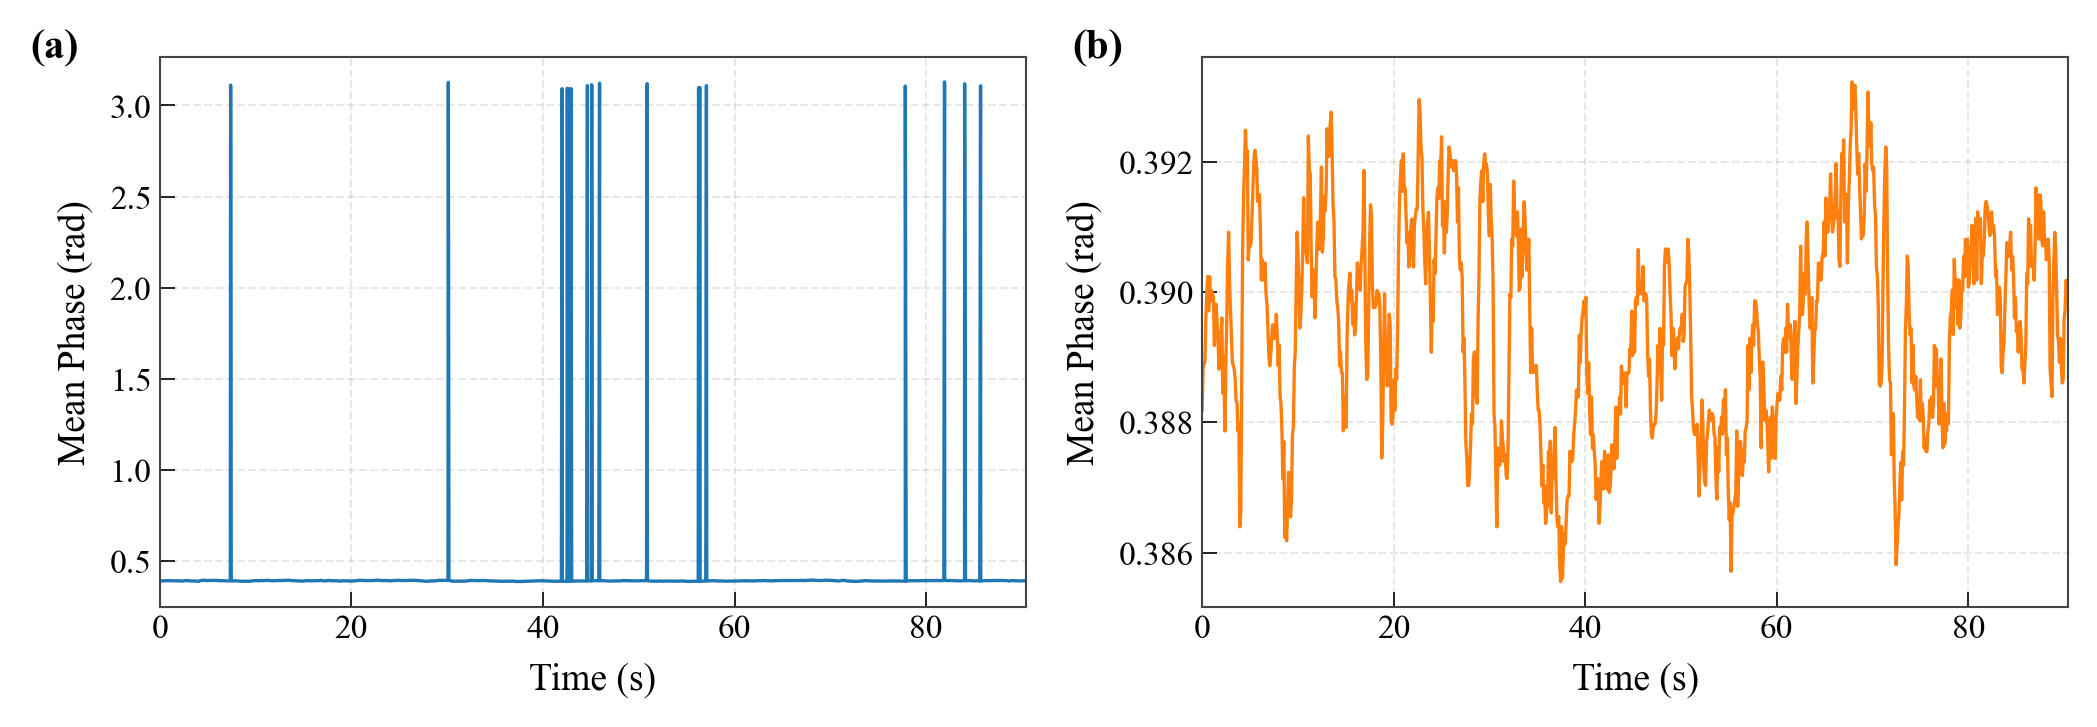

In [90]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

# Set IEEE-style plot parameters
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['axes.titlesize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# --- Setup ---
df_selected = df[df.session_id == '20251024_100806']
phases_df = df_selected[phase_cols]

# Calculate circular mean phase
mean_sin = np.sin(phases_df).mean(axis=1)
mean_cos = np.cos(phases_df).mean(axis=1)
circular_mean_phase = np.arctan2(mean_sin, mean_cos)

# Convert timestamp to Time (s) for full data
if df_selected['timestamp'].dtype == 'object':
    timestamps_full = pd.to_datetime(df_selected['timestamp'])
else:
    timestamps_full = df_selected['timestamp']

# Calculate time in seconds from start for full data
time_seconds_full = (timestamps_full - timestamps_full.iloc[0]).dt.total_seconds()

# Filter cleaned data
df_cleaned = df_selected[df_selected[mag_cols].mean(axis=1) > 5]

# Recalculate circular mean for cleaned data
phases_df_cleaned = df_cleaned[phase_cols]
mean_sin_cleaned = np.sin(phases_df_cleaned).mean(axis=1)
mean_cos_cleaned = np.cos(phases_df_cleaned).mean(axis=1)
circular_mean_phase_cleaned = np.arctan2(mean_sin_cleaned, mean_cos_cleaned)

# Convert timestamp to Time (s) for cleaned data
if df_cleaned['timestamp'].dtype == 'object':
    timestamps_cleaned = pd.to_datetime(df_cleaned['timestamp'])
else:
    timestamps_cleaned = df_cleaned['timestamp']

# Calculate time in seconds from start for cleaned data (same reference point)
time_seconds_cleaned = (timestamps_cleaned - timestamps_full.iloc[0]).dt.total_seconds()

# Create figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

# --- Subplot (a): Full data with Time (s) ---
axes[0].plot(time_seconds_full.values, circular_mean_phase.values, 
             linewidth=0.8, color='#1f77b4')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Mean Phase (rad)')
axes[0].grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
axes[0].set_xlim(time_seconds_full.min(), time_seconds_full.max())

# Add subplot label (a)
axes[0].text(-0.15, 1.05, '(a)', transform=axes[0].transAxes, 
             fontsize=10, fontweight='bold', va='top')

# --- Subplot (b): Cleaned data with Time (s) ---
axes[1].plot(time_seconds_cleaned.values, circular_mean_phase_cleaned.values, 
             linewidth=0.8, color='#ff7f0e')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Mean Phase (rad)')
axes[1].grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
axes[1].set_xlim(time_seconds_full.min(), time_seconds_full.max())

# Add subplot label (b)
axes[1].text(-0.15, 1.05, '(b)', transform=axes[1].transAxes, 
             fontsize=10, fontweight='bold', va='top')

# Adjust layout to prevent overlap
plt.tight_layout()

# Save figure with high DPI for publication quality
plt.savefig('circular_mean_phase_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('circular_mean_phase_comparison.pdf', bbox_inches='tight')

print("IEEE-style comparison plot saved as:")
print("  - 'circular_mean_phase_comparison.png' (300 DPI)")
print("  - 'circular_mean_phase_comparison.pdf' (vector format)")

$$BFM\ Ratio = \frac{BFM_0}{BFM_1} = \frac{\frac{a_0}{\sigma_1} e^{j(\theta_M - \theta_0)}}{\frac{a_1}{\sigma_1} e^{j(\theta_M - \theta_1)}} = \left(\frac{a_0}{a_1}\right) \cdot \left(\frac{1/\sigma_1}{1/\sigma_1}\right) \cdot \left(\frac{e^{j\theta_M} \cdot e^{-j\theta_0}}{e^{j\theta_M} \cdot e^{-j\theta_1}}\right) = \frac{a_0 e^{-j\theta_0}}{a_1 e^{-j\theta_1}} $$

In [91]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from scipy.stats import median_abs_deviation

# ============================================================================
# PIPELINE CONSTANTS
# ============================================================================
W_SPREAD = 100    # Lookback for IQR winsorization and MAD scale
W_LOCATION = 100  # Lookback for rolling median (centering baseline)
W_FEATURE = 53    # Observations for LMAD (~5.3s at 10 Hz)
IQR_F = 1.5
DIFF_ORDER = 3    # 3rd-order difference (proven)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def apply_pca_separate(df, scidx_mag_cols, scidx_phase_cols, n_components_mag=1, n_components_phase=1):
    """
    Apply PCA separately to BFM Magnitude Ratio and Phase Ratio columns.
    """
    df_out = df.copy()
    
    # --- PCA on Magnitude Ratio ---
    if scidx_mag_cols:
        mag_data = df_out[scidx_mag_cols].values
        if np.isnan(mag_data).any():
            col_means = np.nanmean(mag_data, axis=0)
            inds = np.where(np.isnan(mag_data))
            mag_data[inds] = np.take(col_means, inds[1])
            
        pca_mag = PCA(n_components=n_components_mag)
        mag_comps = pca_mag.fit_transform(mag_data)
        for i in range(n_components_mag):
            df_out[f'PCA_Mag_{i+1}'] = mag_comps[:, i]

    # --- PCA on Phase Ratio ---
    if scidx_phase_cols:
        phase_data = df_out[scidx_phase_cols].values
        if np.isnan(phase_data).any():
            col_means = np.nanmean(phase_data, axis=0)
            inds = np.where(np.isnan(phase_data))
            phase_data[inds] = np.take(col_means, inds[1])

        pca_phase = PCA(n_components=n_components_phase)
        phase_comps = pca_phase.fit_transform(phase_data)
        for i in range(n_components_phase):
            df_out[f'PCA_Phase_{i+1}'] = phase_comps[:, i]
            
    return df_out

def calculate_rolling_mad(x):
    """
    Calculate Median Absolute Deviation (MAD) for a window.
    Uses scipy consistent scaling (scale='normal' => * 1.4826).
    """
    if len(x) < 1: return np.nan
    mad = median_abs_deviation(x, scale='normal', nan_policy='omit')
    return mad if mad > 0 else 1e-6

def calculate_acceleration_feature(x):
    """
    3rd-order LMAD feature:
    F_t = ln( mean(|diff^3(Z)|) )
    """
    if len(x) < (DIFF_ORDER + 1): return np.nan
    
    d = np.diff(x, n=DIFF_ORDER)
    mean_abs_d = np.mean(np.abs(d))
    
    if mean_abs_d <= 0:
        return -10.0
    return np.log(mean_abs_d)

def create_r_features(df_in, base_col='PCA_Mag_1'):
    """
    Feature engineering pipeline:
    1. Winsorization (Window=W_SPREAD, 1.5 IQR)
    2. Robust Standardization (Window=W_LOCATION/W_SPREAD, Median/MAD)
    3. 3rd-order LMAD Feature (Window=W_FEATURE)
    """
    df = df_in.copy()
    df = df.sort_values(by=['session_id', 'timestamp']).reset_index(drop=True)
    
    z_col_name = f"{base_col}_robust_z"
    accel_col_name = f"feature_{base_col.lower()}_accel"
    
    grouper = df.groupby('session_id')[base_col]
    
    # --- Step 1: Winsorization ---
    roll = grouper.rolling(window=W_SPREAD, min_periods=1)
    
    q1 = roll.quantile(0.25).reset_index(level=0, drop=True)
    q3 = roll.quantile(0.75).reset_index(level=0, drop=True)
    iqr = q3 - q1
    
    lower_bound = q1 - (IQR_F * iqr)
    upper_bound = q3 + (IQR_F * iqr)
    
    df['winsorized'] = df[base_col].clip(lower=lower_bound, upper=upper_bound)
    df['winsorized'] = df['winsorized'].fillna(df[base_col])
    
    # --- Step 2: Robust Moving Standardization ---
    winsor_grouper = df.groupby('session_id')['winsorized']
    roll_winsor = winsor_grouper.rolling(window=W_LOCATION, min_periods=1)
    
    rolling_median = roll_winsor.median().reset_index(level=0, drop=True)
    
    roll_spread = winsor_grouper.rolling(window=W_SPREAD, min_periods=1)
    rolling_mad = roll_spread.apply(calculate_rolling_mad, raw=True).reset_index(level=0, drop=True)
    
    df[z_col_name] = (df['winsorized'] - rolling_median) / rolling_mad
    df[z_col_name] = df[z_col_name].fillna(0)
    
    # --- Step 3: 3rd-order LMAD Feature ---
    z_grouper = df.groupby('session_id')[z_col_name]
    
    df[accel_col_name] = z_grouper.rolling(window=W_FEATURE).apply(
        calculate_acceleration_feature, raw=True
    ).reset_index(level=0, drop=True)
    
    df = df.drop(columns=['winsorized'])
    
    return df

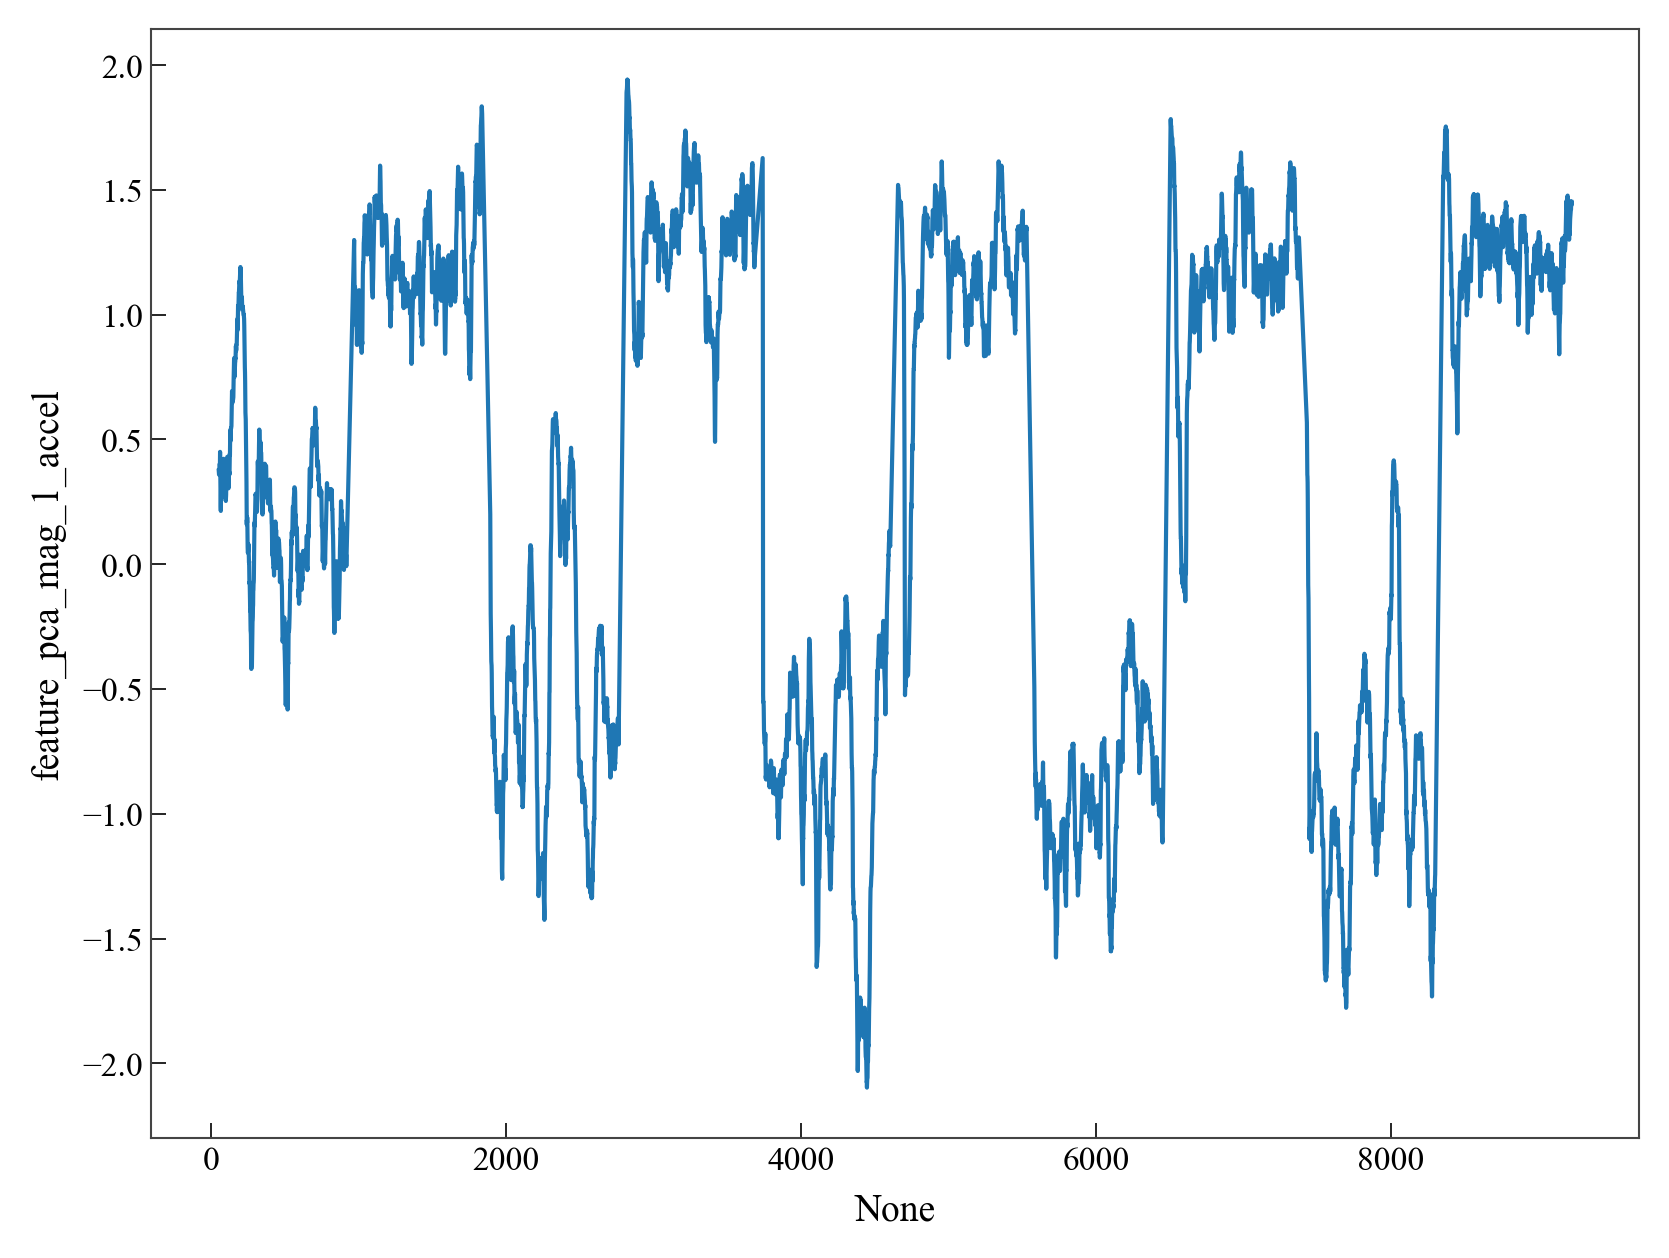

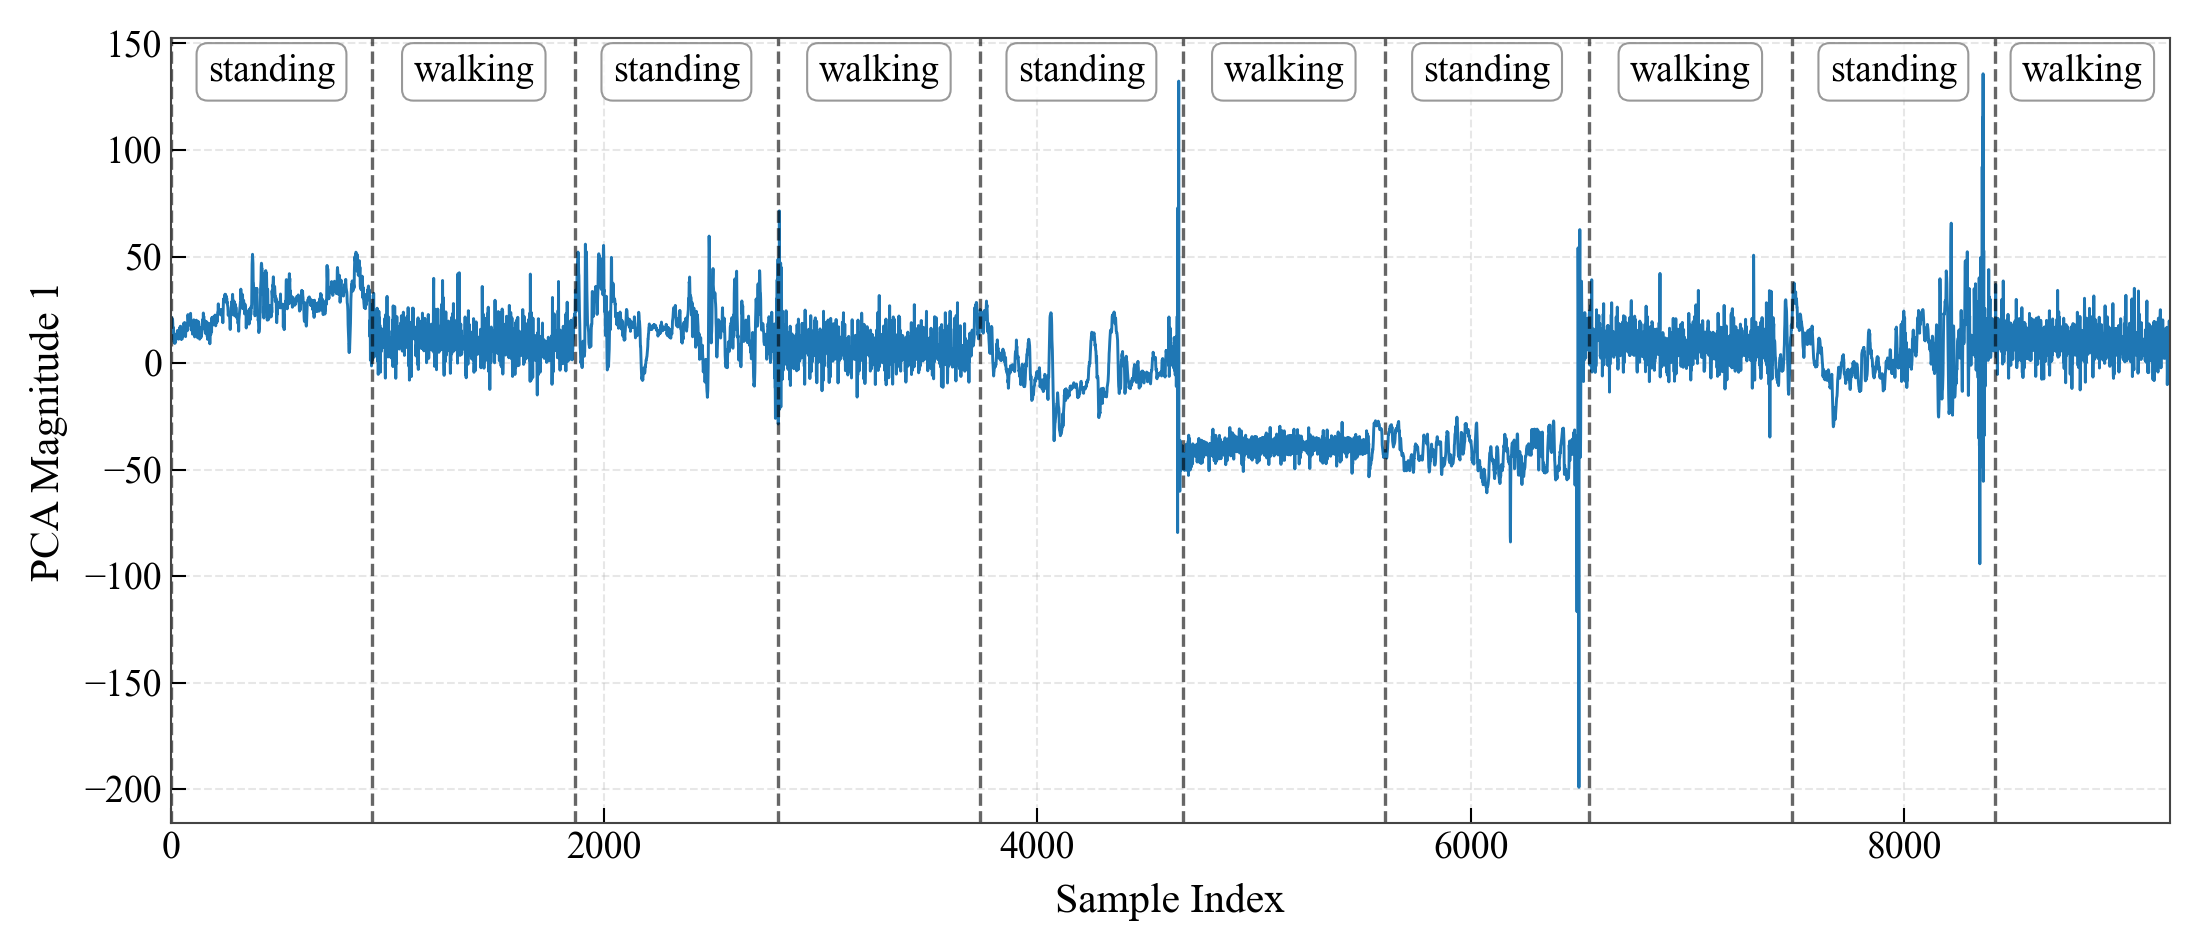

In [92]:
df_selected = df[(df.environment == 'nofoil') & (df.subject.isin(['collin']))].copy()
df_selected['timestamp'] = pd.to_datetime(df_selected['timestamp'])

df_selected = df_selected[df_selected.session_id.isin(df_selected.session_id.unique()[:])]
df_selected = df_selected.sort_values(by=['timestamp']).reset_index(drop=True)
df_selected['Magnitude'] = df_selected[mag_cols].mean(axis=1)
df_selected = df_selected[df_selected['Magnitude'] > 5].copy()
df_selected = apply_pca_separate(df_selected, mag_cols, phase_cols, 1, 1)

start_index = pd.merge(df_selected.reset_index().groupby('session_id').index.min(), df_selected['activity'].reset_index(), on = 'index')


pca_col = f'PCA_Mag_1'
df_selected = create_r_features(df_selected, base_col=pca_col)
sns.lineplot(df_selected, x = df_selected.index, y = 'feature_pca_mag_1_accel')


import numpy as np
from matplotlib.ticker import LogLocator, NullFormatter

# IEEE standard plot settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
})

# Create figure
fig, ax = plt.subplots(figsize=(7.16, 3))

# Plot the main line
ax.plot(df_selected.index, df_selected['PCA_Mag_1'], 
        color='#1f77b4', 
        linewidth=0.7)

# Get y-axis limits for vertical lines
y_min, y_max = ax.get_ylim()

# Add vertical dashed lines at session starts
for idx, row in start_index.iterrows():
    start_idx = row['index']
    ax.axvline(x=start_idx, color='black', linestyle='--', 
               linewidth=0.8, alpha=0.6)

# Add activity labels in each region
for i in range(len(start_index)):
    # Get start of current region
    start_idx = start_index.iloc[i]['index']
    activity = start_index.iloc[i]['activity']
    
    # Get end of current region (start of next region or end of data)
    if i < len(start_index) - 1:
        end_idx = start_index.iloc[i + 1]['index']
    else:
        end_idx = df_selected.index[-1]
    
    # Calculate middle position for text
    mid_idx = (start_idx + end_idx) / 2
    
    # Place text at the top of the plot
    ax.text(mid_idx, y_max * 0.95, activity, 
            ha='center', va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', 
                     facecolor='white', 
                     edgecolor='gray',
                     alpha=0.8,
                     linewidth=0.5))

ax.set_xlabel('Sample Index')
ax.set_ylabel('PCA Magnitude 1')
ax.set_xlim(0, len(df_selected))
ax.tick_params(width=0.5)
ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout(pad=0.1)

# Save as PDF
# plt.savefig('pca_phase_sessions.pdf', bbox_inches='tight', pad_inches=0.01)
plt.show()




<Axes: xlabel='None', ylabel='feature_pca_mag_1_accel'>

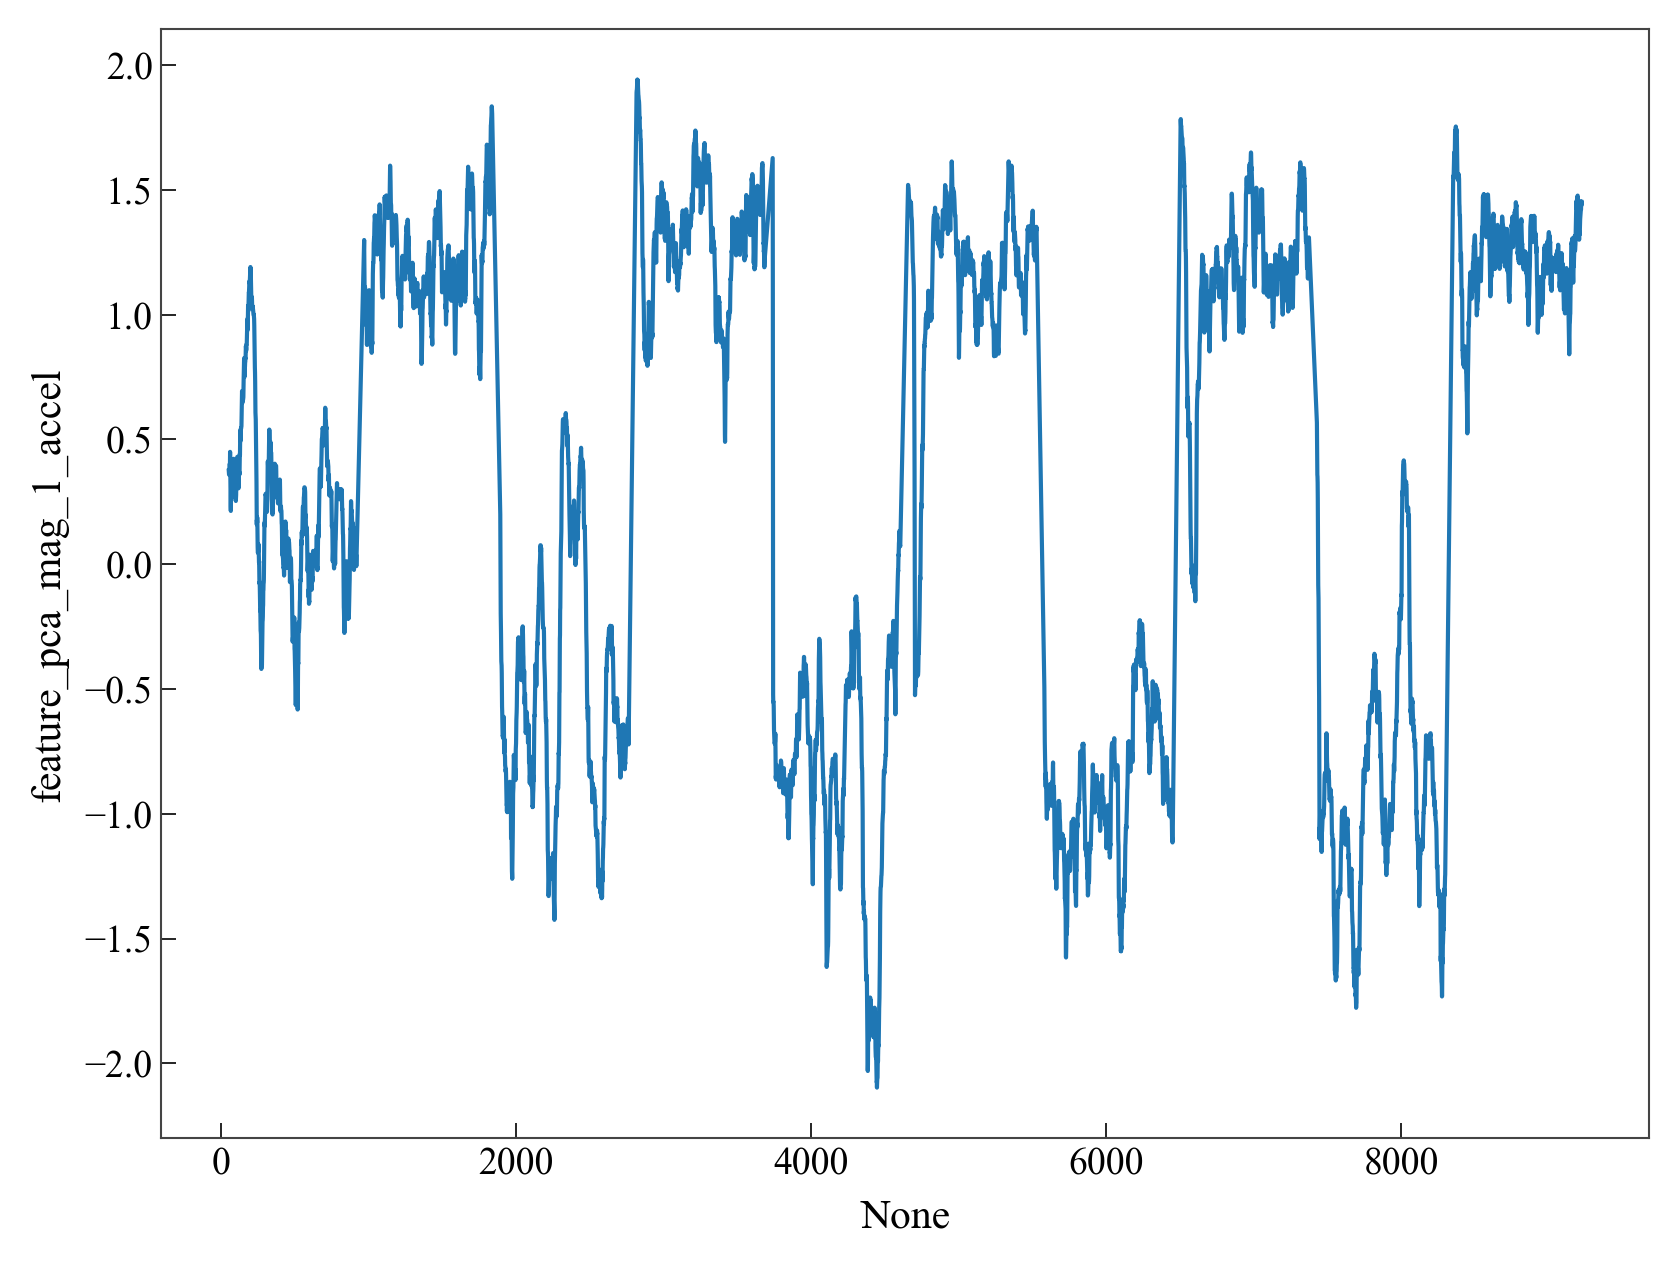

In [93]:

pca_col = f'PCA_Mag_1'
df_selected = create_r_features(df_selected, base_col=pca_col)
sns.lineplot(df_selected, x = df_selected.index, y = 'feature_pca_mag_1_accel')

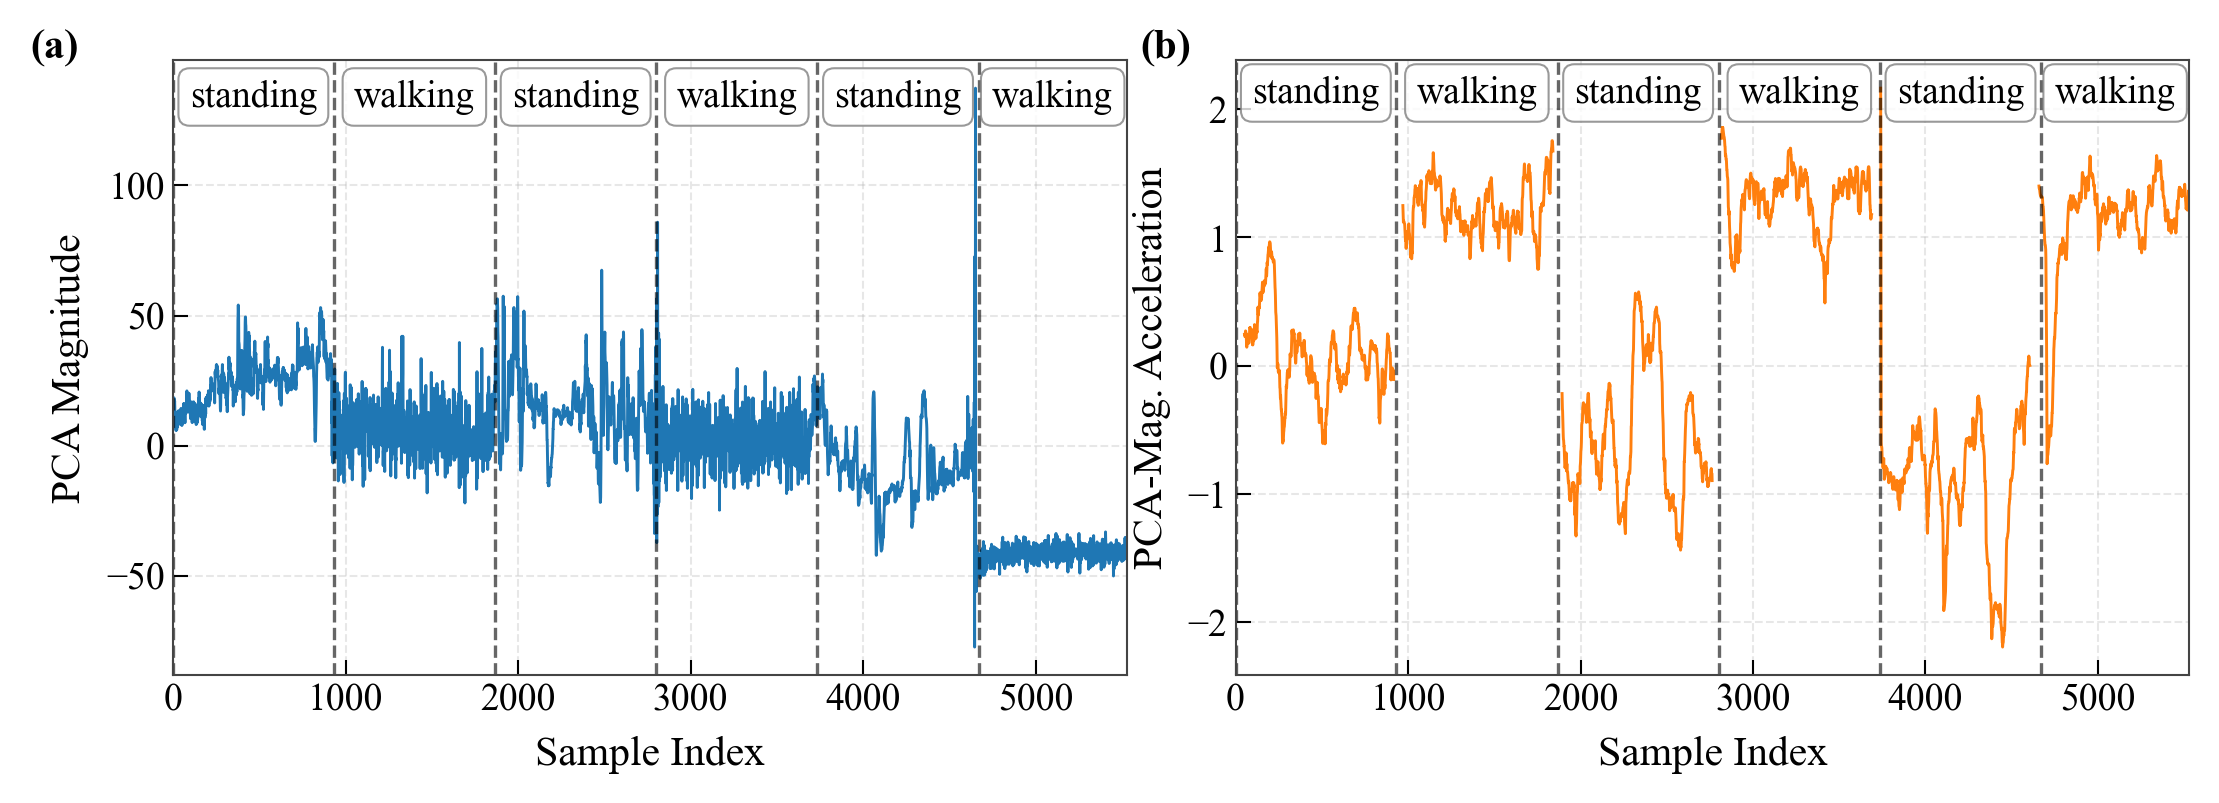

In [94]:
import numpy as np
from matplotlib.ticker import LogLocator, NullFormatter


df_selected = df[(df.environment == 'nofoil') & (df.subject.isin(['collin']))].copy()
df_selected['timestamp'] = pd.to_datetime(df_selected['timestamp'])

df_selected = df_selected[df_selected.session_id.isin(df_selected.session_id.unique()[:6])]
df_selected = df_selected.sort_values(by=['timestamp']).reset_index(drop=True)
df_selected['Magnitude'] = df_selected[mag_cols].mean(axis=1)
df_selected = df_selected[df_selected['Magnitude'] > 5].copy()
df_selected = apply_pca_separate(df_selected, mag_cols, phase_cols, 1, 1)

start_index = pd.merge(df_selected.reset_index().groupby('session_id').index.min(), df_selected['activity'].reset_index(), on = 'index')


pca_col = f'PCA_Mag_1'
df_selected = create_r_features(df_selected, base_col=pca_col)

# IEEE standard plot settings
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
})

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.16, 2.5))

# ============ Left plot (a): PCA_Mag_1 ============
ax1.plot(df_selected.index, df_selected['PCA_Mag_1'], 
        color='#1f77b4', 
        linewidth=0.7)

# Get y-axis limits for vertical lines
y_min1, y_max1 = ax1.get_ylim()

# Add vertical dashed lines at session starts
for idx, row in start_index.iterrows():
    start_idx = row['index']
    ax1.axvline(x=start_idx, color='black', linestyle='--', 
               linewidth=0.8, alpha=0.6)

# Add activity labels in each region
for i in range(len(start_index)):
    start_idx = start_index.iloc[i]['index']
    activity = start_index.iloc[i]['activity']
    
    if i < len(start_index) - 1:
        end_idx = start_index.iloc[i + 1]['index']
    else:
        end_idx = df_selected.index[-1]
    
    mid_idx = (start_idx + end_idx) / 2
    
    ax1.text(mid_idx, y_max1 * 0.95, activity, 
            ha='center', va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', 
                     facecolor='white', 
                     edgecolor='gray',
                     alpha=0.8,
                     linewidth=0.5))

ax1.set_xlabel('Sample Index')
ax1.set_ylabel('PCA Magnitude')
ax1.set_xlim(0, len(df_selected))
ax1.tick_params(width=0.5)
ax1.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

# Add (a) label - IEEE style
ax1.text(-0.15, 1.05, '(a)', transform=ax1.transAxes, 
         fontsize=10, fontweight='bold', va='top')

# ============ Right plot (b): Acceleration Feature ============
ax2.plot(df_selected.index, df_selected['feature_pca_mag_1_accel'], 
        color='#ff7f0e', 
        linewidth=0.7)

# Get y-axis limits for vertical lines
y_min2, y_max2 = ax2.get_ylim()

# Add vertical dashed lines at session starts
for idx, row in start_index.iterrows():
    start_idx = row['index']
    ax2.axvline(x=start_idx, color='black', linestyle='--', 
               linewidth=0.8, alpha=0.6)

# Add activity labels in each region
for i in range(len(start_index)):
    start_idx = start_index.iloc[i]['index']
    activity = start_index.iloc[i]['activity']
    
    if i < len(start_index) - 1:
        end_idx = start_index.iloc[i + 1]['index']
    else:
        end_idx = df_selected.index[-1]
    
    mid_idx = (start_idx + end_idx) / 2
    
    ax2.text(mid_idx, y_max2 * 0.95, activity, 
            ha='center', va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', 
                     facecolor='white', 
                     edgecolor='gray',
                     alpha=0.8,
                     linewidth=0.5))

ax2.set_xlabel('Sample Index')
ax2.set_ylabel('PCA-Mag. Acceleration')
ax2.set_xlim(0, len(df_selected))
ax2.tick_params(width=0.5)
ax2.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)

# Add (b) label - IEEE style
ax2.text(-0.1, 1.05, '(b)', transform=ax2.transAxes, 
         fontsize=10, fontweight='bold', va='top')

plt.tight_layout(pad=0.1)

# Save as PDF
# plt.savefig('pca_mag_comparison.pdf', bbox_inches='tight', pad_inches=0.01)
plt.show()



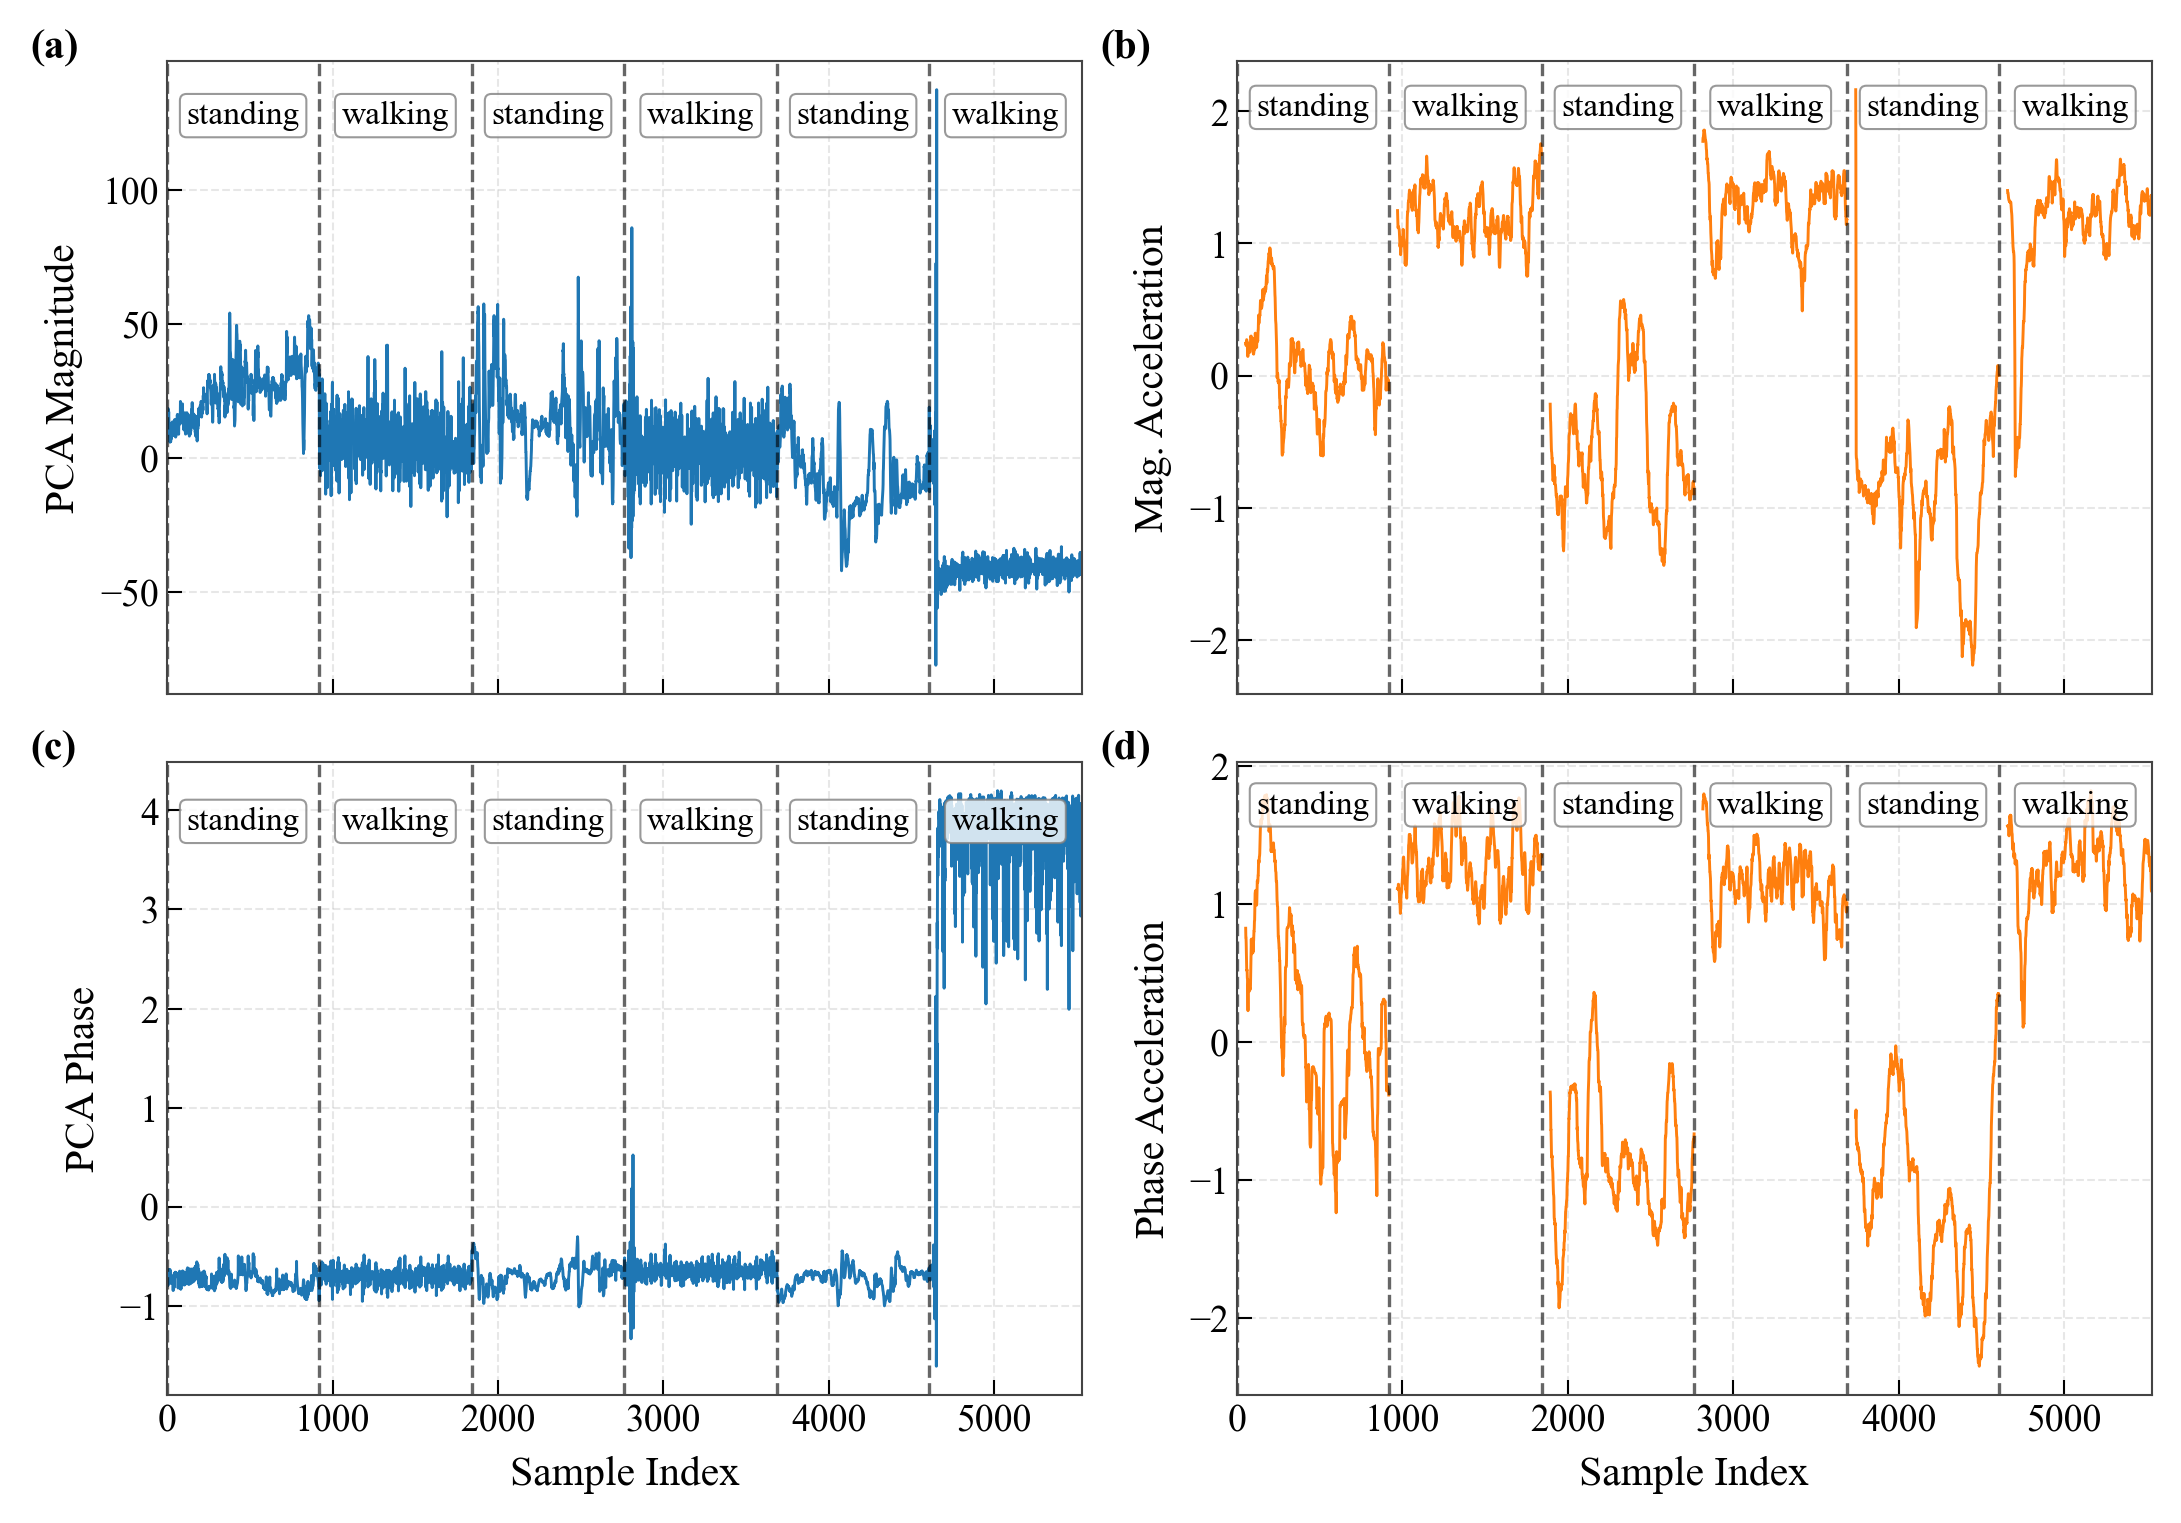

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter

# ============================================================================
# 1. Data Prep (Assumes df, mag_cols, phase_cols, apply_pca_separate, create_r_features exist)
# ============================================================================

# Select specific subject and environment
df_selected = df[(df.environment == 'nofoil') & (df.subject.isin(['collin']))].copy()
df_selected['timestamp'] = pd.to_datetime(df_selected['timestamp'])

# Limit to first 6 sessions for clarity
df_selected = df_selected[df_selected.session_id.isin(df_selected.session_id.unique()[:6])]
df_selected = df_selected.sort_values(by=['timestamp']).reset_index(drop=True)

# Filter low magnitude
df_selected['Magnitude'] = df_selected[mag_cols].mean(axis=1)
df_selected = df_selected[df_selected['Magnitude'] > 5].copy()

# Apply PCA for both Magnitude and Phase
# This creates 'PCA_Mag_1' and 'PCA_Phase_1' columns
df_selected = apply_pca_separate(df_selected, mag_cols, phase_cols, 1, 1)

# Generate Acceleration Features for both
df_selected = create_r_features(df_selected, base_col='PCA_Mag_1')
df_selected = create_r_features(df_selected, base_col='PCA_Phase_1')

# Get start indices for vertical lines (session boundaries)
start_index = pd.merge(
    df_selected.reset_index().groupby('session_id').index.min(), 
    df_selected['activity'].reset_index(), 
    on='index'
)

# ============================================================================
# 2. IEEE Plotting Setup
# ============================================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.format': 'pdf',
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.0,
})

# Create 2x2 grid: (7.16 inches width for double column, height adjusted)
fig, axes = plt.subplots(2, 2, figsize=(7.16, 5.0), sharex=True)
((ax1, ax2), (ax3, ax4)) = axes

# Define configurations for loop
plots_config = [
    {
        'ax': ax1, 'data_col': 'PCA_Mag_1', 'color': '#1f77b4', 
        'ylabel': 'PCA Magnitude', 'label': '(a)'
    },
    {
        'ax': ax2, 'data_col': 'feature_pca_mag_1_accel', 'color': '#ff7f0e', 
        'ylabel': 'Mag. Acceleration', 'label': '(b)'
    },
    {
        'ax': ax3, 'data_col': 'PCA_Phase_1', 'color': '#1f77b4', 
        'ylabel': 'PCA Phase', 'label': '(c)'
    },
    {
        'ax': ax4, 'data_col': 'feature_pca_phase_1_accel', 'color': '#ff7f0e', 
        'ylabel': 'Phase Acceleration', 'label': '(d)'
    }
]

# ============================================================================
# 3. Plotting Loop
# ============================================================================
for config in plots_config:
    ax = config['ax']
    col = config['data_col']
    
    # Plot Data
    ax.plot(df_selected.index, df_selected[col], color=config['color'], linewidth=0.7)
    
    # Y-Limits for text placement
    y_min, y_max = ax.get_ylim()
    
    # Add vertical session lines
    for _, row in start_index.iterrows():
        ax.axvline(x=row['index'], color='black', linestyle='--', linewidth=0.8, alpha=0.6)
        
    # Add activity labels (Only for top row to avoid clutter, or all if preferred)
    # Here we add to all for clarity, or you can restrict to `if ax in [ax1, ax2]:`
    for i in range(len(start_index)):
        s_idx = start_index.iloc[i]['index']
        act = start_index.iloc[i]['activity']
        
        # Determine end index
        if i < len(start_index) - 1:
            e_idx = start_index.iloc[i + 1]['index']
        else:
            e_idx = df_selected.index[-1]
            
        mid_idx = (s_idx + e_idx) / 2
        
        # Add Label Text
        ax.text(mid_idx, y_max * 0.90, act, 
                ha='center', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                          edgecolor='gray', alpha=0.8, linewidth=0.5))

    # Formatting
    ax.set_ylabel(config['ylabel'])
    ax.set_xlim(0, len(df_selected))
    ax.tick_params(width=0.5)
    ax.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
    
    # Subplot Label (a, b, c, d)
    ax.text(-0.15, 1.05, config['label'], transform=ax.transAxes, 
            fontsize=10, fontweight='bold', va='top')

# Set X-labels only for bottom row
ax3.set_xlabel('Sample Index')
ax4.set_xlabel('Sample Index')

plt.tight_layout(pad=0.5, w_pad=1.0, h_pad=1.0)

# Save
# plt.savefig('pca_mag_phase_grid.pdf', bbox_inches='tight', pad_inches=0.01)
plt.show()

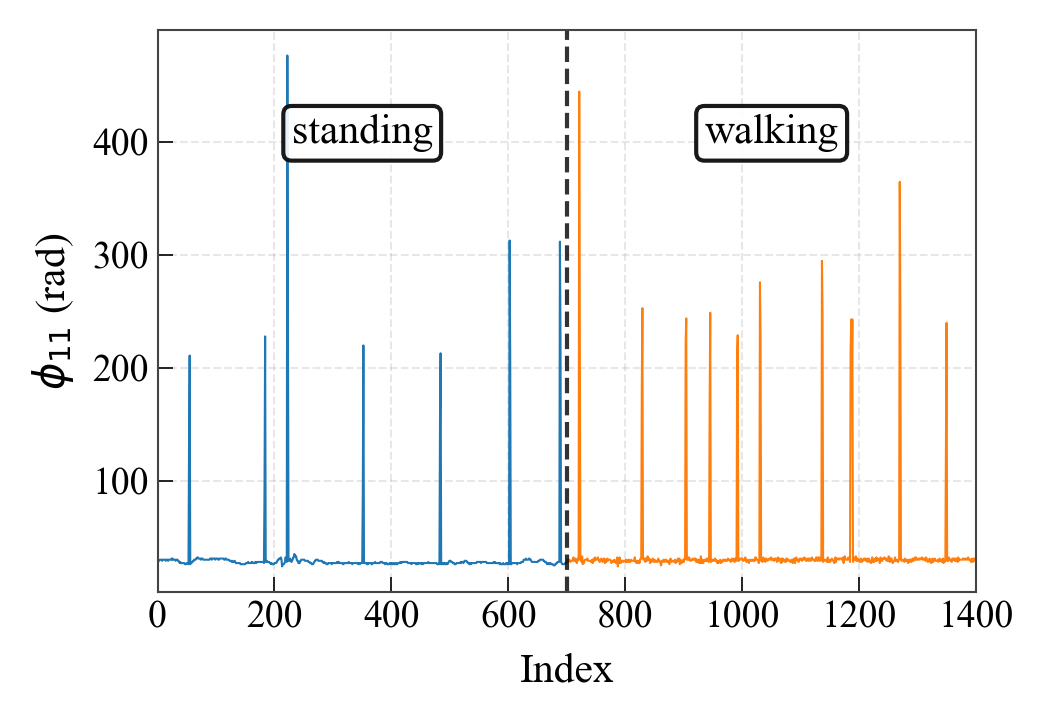

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- IEEE Styling ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 0.8,
})

# --- Configuration ---
N_SAMPLES = 700
path_stand = "bfm_raw_csv/bfm_data_standing_abel_alt_nofoil_20251010_143551.csv"
path_walk = "bfm_raw_csv/bfm_data_walking_abel_alt_nofoil_20251010_143736.csv"

try:
    # Load and Slice Raw Data
    raw_stand = pd.read_csv(path_stand)['SCIDX_-122_phi11'].iloc[:N_SAMPLES]
    raw_walk = pd.read_csv(path_walk)['SCIDX_-122_phi11'].iloc[:N_SAMPLES]
    
    # Concatenate
    raw_combined = np.concatenate([raw_stand, raw_walk])
    
    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(3.58, 2.5))

    ax.plot(np.arange(700), raw_stand, color='#1f77b4', linewidth=0.5)
    ax.plot(np.arange(700, 1400), raw_walk, color='#ff7f0e', linewidth=0.5)
    
    # Add Divider
    ax.axvline(x=N_SAMPLES, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
    
    # Annotations
    y_min, y_max = ax.get_ylim()
    y_txt = y_max - (y_max - y_min) * 0.15
    
    ax.text(N_SAMPLES / 2, y_txt, 'standing', ha='center', va='top', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
    ax.text(N_SAMPLES + (N_SAMPLES / 2), y_txt, 'walking', ha='center', va='top', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

    ax.set_ylabel(r'$\phi_{11}$ (rad)')
    ax.set_xlabel('Index')
    ax.set_xlim(0, len(raw_combined))
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/step1.png')
    plt.show()

except FileNotFoundError as e:
    print(f"Error loading raw files: {e}")

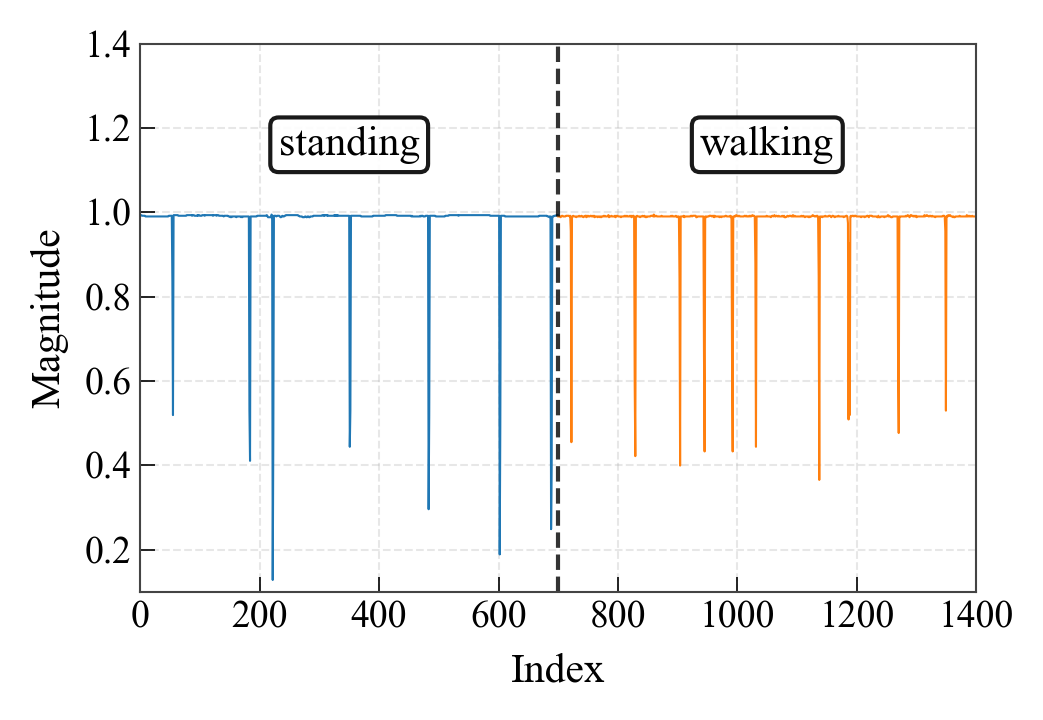

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- IEEE Styling ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 0.8,
})

# ============================================================================
# 1. VECTORIZED DECOMPRESSION FUNCTION
# ============================================================================
def decompress_bfm_target_sc(df, sc_idx, N_samples):
    """
    Extracts and decompresses BFM for a specific subcarrier using vectorized ops.
    Returns complex h1 and h2 arrays.
    """
    # Bit precision constants (802.11ac/ax)
    phi_bit, psi_bit = 9, 7
    const1_phi, const2_phi = 1 / (2 ** (phi_bit - 1)), 1 / (2 ** phi_bit)
    const1_psi, const2_psi = 1 / (2 ** (psi_bit + 1)), 1 / (2 ** (psi_bit + 2))

    # Extract columns for specific subcarrier
    phi_col = f'SCIDX_{sc_idx}_phi11'
    psi_col = f'SCIDX_{sc_idx}_psi21'
    
    # Get values (sliced to N_samples)
    raw_phi = df[phi_col].values[:N_samples]
    raw_psi = df[psi_col].values[:N_samples]

    # Vectorized Angle Conversion
    phi_11 = np.pi * (const2_phi + const1_phi * raw_phi)
    psi_21 = np.pi * (const2_psi + const1_psi * raw_psi)

    # Vectorized Givens Rotation (Decompression)
    cos_psi = np.cos(psi_21)
    sin_psi = np.sin(psi_21)
    exp_phi = np.exp(1j * phi_11)

    h1 = exp_phi * cos_psi
    h2 = sin_psi
    
    return h1, h2

# ============================================================================
# 2. DATA LOADING & PROCESSING
# ============================================================================
N_SAMPLES = 700
TARGET_SC = -122
path_stand = "bfm_raw_csv/bfm_data_standing_abel_alt_nofoil_20251010_143551.csv"
path_walk = "bfm_raw_csv/bfm_data_walking_abel_alt_nofoil_20251010_143736.csv"

try:
    # Load Data
    df_stand = pd.read_csv(path_stand)
    df_walk = pd.read_csv(path_walk)

    # Decompress
    h1_stand, h2_stand = decompress_bfm_target_sc(df_stand, TARGET_SC, N_SAMPLES)
    h1_walk, h2_walk = decompress_bfm_target_sc(df_walk, TARGET_SC, N_SAMPLES)

    # Concatenate Magnitude of h1 (|h1|)
    decompressed_signal = np.concatenate([np.abs(h1_stand), np.abs(h1_walk)])

    # ============================================================================
    # 3. PLOTTING
    # ============================================================================
    fig, ax = plt.subplots(figsize=(3.58, 2.5))

    # Plot Data
    ax.plot(np.arange(N_SAMPLES), decompressed_signal[:N_SAMPLES], 
            color='#1f77b4', linewidth=0.5, label='Standing')
    ax.plot(np.arange(N_SAMPLES, N_SAMPLES*2), decompressed_signal[N_SAMPLES:], 
            color='#ff7f0e', linewidth=0.5, label='Walking')

    # Add Divider
    ax.axvline(x=N_SAMPLES, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

    # Annotations
    ax.set_ylim(0.1, 1.4)
    y_min, y_max = ax.get_ylim()
    y_txt = y_max - (y_max - y_min) * 0.15
    ax.text(N_SAMPLES / 2, y_txt, 'standing', ha='center', va='top', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
    ax.text(N_SAMPLES + (N_SAMPLES / 2), y_txt, 'walking', ha='center', va='top', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

    ax.set_ylabel(r'Magnitude')
    ax.set_xlabel('Index')
    ax.set_xlim(0, len(decompressed_signal))
    ax.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/step2mag.png')
    plt.show()

except FileNotFoundError as e:
    print(f"Error loading files: {e}")

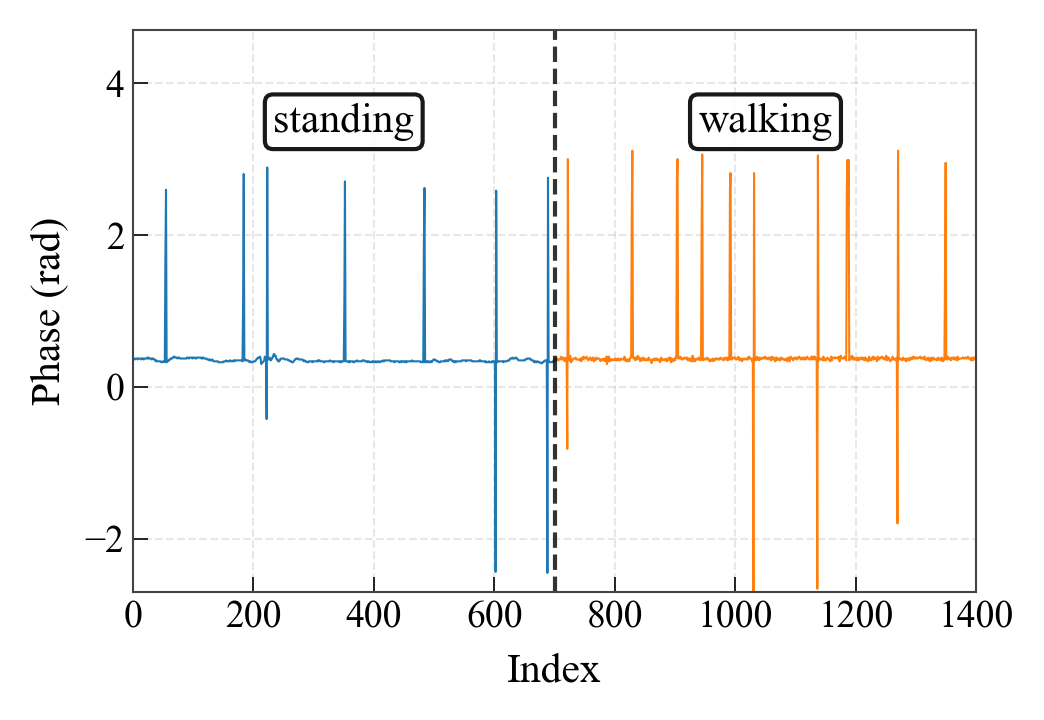

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- IEEE Styling ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 0.8,
})

# ============================================================================
# DATA LOADING & PROCESSING (Phase)
# ============================================================================
N_SAMPLES = 700
TARGET_SC = -122
path_stand = "bfm_raw_csv/bfm_data_standing_abel_alt_nofoil_20251010_143551.csv"
path_walk = "bfm_raw_csv/bfm_data_walking_abel_alt_nofoil_20251010_143736.csv"

try:
    # Load Data
    df_stand = pd.read_csv(path_stand)
    df_walk = pd.read_csv(path_walk)

    # Decompress
    h1_stand, h2_stand = decompress_bfm_target_sc(df_stand, TARGET_SC, N_SAMPLES)
    h1_walk, h2_walk = decompress_bfm_target_sc(df_walk, TARGET_SC, N_SAMPLES)

    # Concatenate PHASE of h1 (np.angle)
    decompressed_signal = np.concatenate([np.angle(h1_stand), np.angle(h1_walk)])

    # ============================================================================
    # PLOTTING
    # ============================================================================
    fig, ax = plt.subplots(figsize=(3.58, 2.5))

    ax.set_ylim(-2.7, 4.7)
    # Plot Data
    ax.plot(np.arange(N_SAMPLES), decompressed_signal[:N_SAMPLES], 
            color='#1f77b4', linewidth=0.5, label='Standing')
    ax.plot(np.arange(N_SAMPLES, N_SAMPLES*2), decompressed_signal[N_SAMPLES:], 
            color='#ff7f0e', linewidth=0.5, label='Walking')

    # Add Divider
    ax.axvline(x=N_SAMPLES, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

    # Annotations
    y_min, y_max = -np.pi, np.pi 
    y_txt = y_max + 0.1
    
    ax.text(N_SAMPLES / 2, y_txt, 'standing', ha='center', va='bottom', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
    ax.text(N_SAMPLES + (N_SAMPLES / 2), y_txt, 'walking', ha='center', va='bottom', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

    ax.set_ylabel(r'Phase (rad)')
    ax.set_xlabel('Index')
    ax.set_xlim(0, len(decompressed_signal))
    ax.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('plots/step2phase.png')
    plt.show()

except FileNotFoundError as e:
    print(f"Error loading files: {e}")

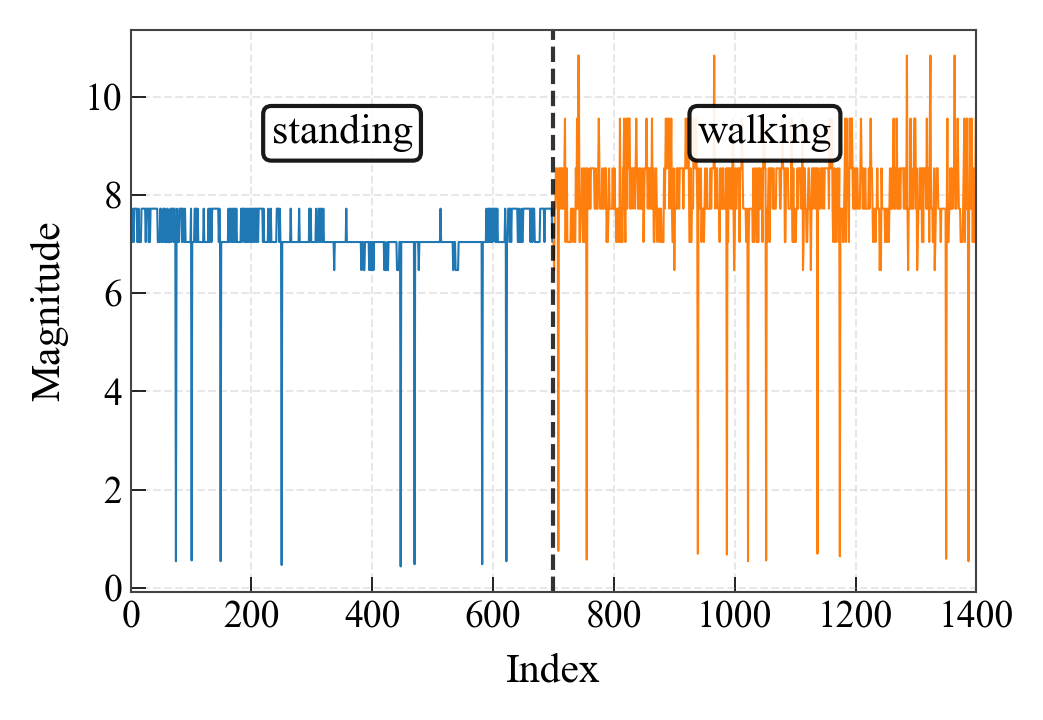

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# BFM RATIO CALCULATION & PLOTTING
# ============================================================================
N_SAMPLES = 700
# Ensure variables from Cell 1 exist
if 'h1_stand' in locals() and 'h2_stand' in locals():
    
    # Calculate Ratio: h1 / h2
    # Add epsilon to avoid division by zero
    epsilon = 1e-9
    
    ratio_stand = h1_stand / (h2_stand + epsilon)
    ratio_walk = h1_walk / (h2_walk + epsilon)
    
    # Calculate Magnitude: |Ratio|
    # This effectively computes cot(psi_21)
    mag_ratio_combined = np.concatenate([np.abs(ratio_stand), np.abs(ratio_walk)])
    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(3.58, 2.5)) # Half-page width

    mag_ratio1 = df[df.session_id == '20251010_140858']['SCIDX_-122_Ratio_Mag'].iloc[:700]
    mag_ratio2 = df[df.session_id == '20251010_141044']['SCIDX_-122_Ratio_Mag'].iloc[:700]

    # Plot Standing
    ax.plot(np.arange(N_SAMPLES), mag_ratio1, 
            color='#1f77b4', linewidth=0.5)
    
    # Plot Walking
    ax.plot(np.arange(N_SAMPLES, N_SAMPLES*2), mag_ratio2, 
            color='#ff7f0e', linewidth=0.5)

    # Add Divider
    ax.axvline(x=N_SAMPLES, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

    # Annotations
#     ax.set_ylim(0, 12)
    y_min, y_max = ax.get_ylim()
    y_txt = y_max - (y_max - y_min) * 0.15
    ax.text(N_SAMPLES / 2, y_txt, 'standing', ha='center', va='top', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
    ax.text(N_SAMPLES + (N_SAMPLES / 2), y_txt, 'walking', ha='center', va='top', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

    ax.set_ylabel(r'Magnitude')
    ax.set_xlabel('Index')
    ax.set_xlim(0, len(mag_ratio_combined))
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig('plots/step3mag.png')
    plt.show()

else:
    print("Error: Decompressed data (h1_stand, h2_stand) not found. Please run Cell 1 first.")

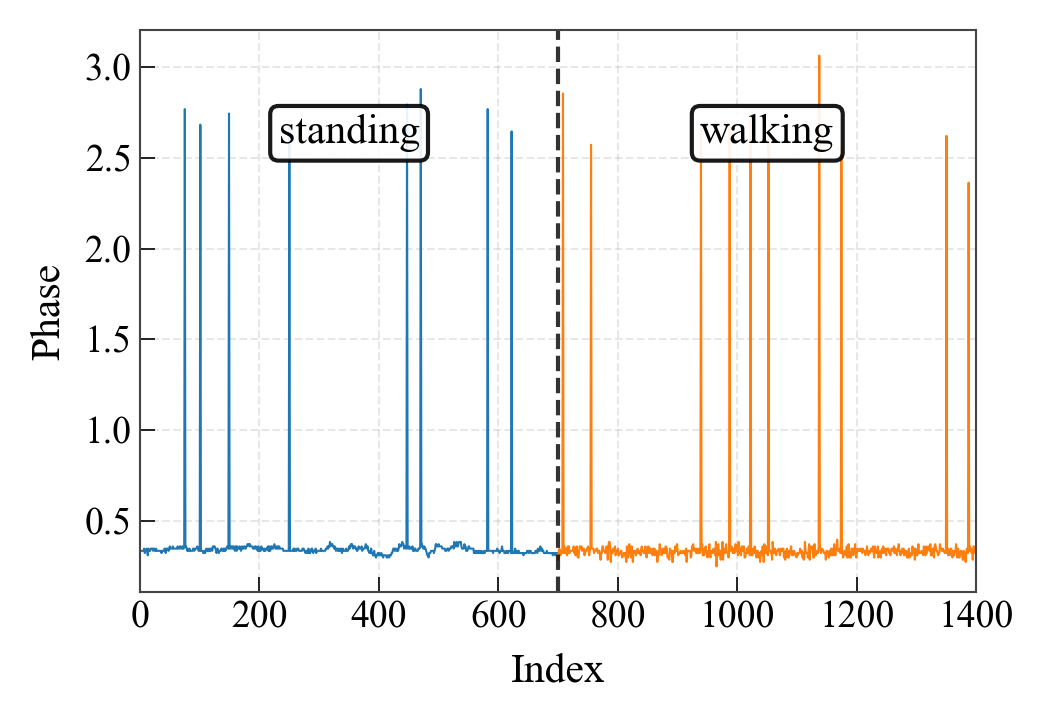

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# BFM RATIO CALCULATION & PLOTTING
# ============================================================================
N_SAMPLES = 700
# Ensure variables from Cell 1 exist
if 'h1_stand' in locals() and 'h2_stand' in locals():
    
    # Calculate Ratio: h1 / h2
    # Add epsilon to avoid division by zero
    epsilon = 1e-9
    
    ratio_stand = h1_stand / (h2_stand + epsilon)
    ratio_walk = h1_walk / (h2_walk + epsilon)
    
    # Calculate Magnitude: |Ratio|
    # This effectively computes cot(psi_21)
    mag_ratio_combined = np.concatenate([np.abs(ratio_stand), np.abs(ratio_walk)])
    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(3.58, 2.5)) # Half-page width

    mag_ratio1 = df[df.session_id == '20251010_140858']['SCIDX_-122_Ratio_Phase'].iloc[:700]
    mag_ratio2 = df[df.session_id == '20251010_141044']['SCIDX_-122_Ratio_Phase'].iloc[:700]

    # Plot Standing
    ax.plot(np.arange(N_SAMPLES), mag_ratio1, 
            color='#1f77b4', linewidth=0.5)
    
    # Plot Walking
    ax.plot(np.arange(N_SAMPLES, N_SAMPLES*2), mag_ratio2, 
            color='#ff7f0e', linewidth=0.5)

    # Add Divider
    ax.axvline(x=N_SAMPLES, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

    # Annotations
#     ax.set_ylim(0, 12)
    y_min, y_max = ax.get_ylim()
    y_txt = y_max - (y_max - y_min) * 0.15
    ax.text(N_SAMPLES / 2, y_txt, 'standing', ha='center', va='top', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
    ax.text(N_SAMPLES + (N_SAMPLES / 2), y_txt, 'walking', ha='center', va='top', 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))

    ax.set_ylabel(r'Phase')
    ax.set_xlabel('Index')
    ax.set_xlim(0, len(mag_ratio_combined))
    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig('plots/step3phase.png')
    plt.show()

else:
    print("Error: Decompressed data (h1_stand, h2_stand) not found. Please run Cell 1 first.")

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import median_abs_deviation

# --- IEEE Styling ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 300,
    'axes.linewidth': 0.5,
    'grid.linewidth': 0.5,
    'lines.linewidth': 0.8,
})

# --- Configuration ---
N_SAMPLES = 700  # Samples per session to visualize

try:
    # 1. Identify Magnitude Columns
    mag_cols = [c for c in df.columns if 'Ratio_Mag' in c]
    phase_cols = [c for c in df.columns if 'Ratio_Phase' in c]
    
    # 2. Select Sessions
    # Filter for valid sessions (must have enough samples)
    valid_sessions = df.groupby('session_id').filter(lambda x: len(x) >= N_SAMPLES)
    
    sess_stand = '20251010_140858'
    sess_walk = '20251010_141044'

    print(f"Selected Standing Session: {sess_stand}")
    print(f"Selected Walking Session: {sess_walk}")
    
    # 3. Extract Data & Concatenate
    data_stand_mag = df[df.session_id == sess_stand][mag_cols].iloc[:N_SAMPLES].values
    data_walk_mag = df[df.session_id == sess_walk][mag_cols].iloc[:N_SAMPLES].values
    
    data_stand_phase = df[df.session_id == sess_stand][phase_cols].iloc[:N_SAMPLES].values
    data_walk_phase = df[df.session_id == sess_walk][phase_cols].iloc[:N_SAMPLES].values
    
    # Concatenate: Standing first (0-700), Walking second (700-1400)
    matrix_combined_mag = np.vstack([data_stand_mag, data_walk_mag])
    matrix_combined_phase = np.vstack([data_stand_phase, data_walk_phase])
    
    print(f"Data prepared. Mag shape: {matrix_combined_mag.shape}, Phase shape: {matrix_combined_phase.shape}")

except Exception as e:
    print(f"Error during setup: {e}")

Selected Standing Session: 20251010_140858
Selected Walking Session: 20251010_141044
Data prepared. Mag shape: (1400, 234), Phase shape: (1400, 234)


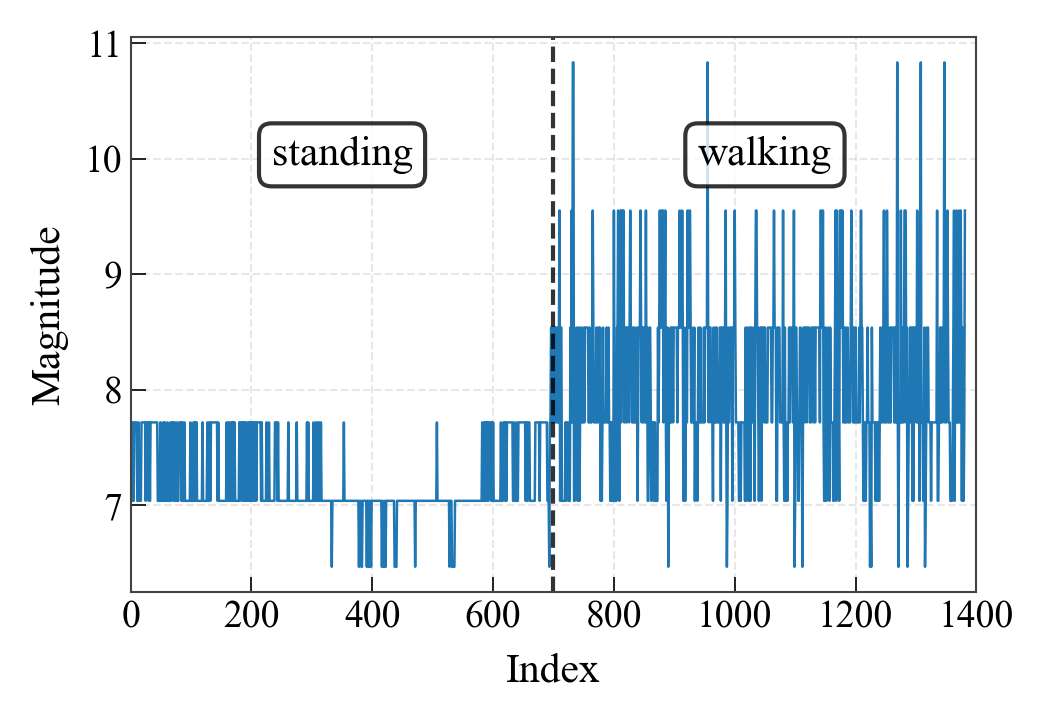

In [102]:
# --- Calculate Mean Magnitude (filtered by SNR) ---
mean_mag_combined = matrix_combined_mag[np.mean(matrix_combined_mag, axis=1) > 5, 0]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(3.58, 2.5))

ax.plot(mean_mag_combined, color='#1f77b4', linewidth=0.6)

# Divider & Annotations
ax.axvline(x=N_SAMPLES, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
y_txt = ax.get_ylim()[1] * 0.9
ax.text(N_SAMPLES/2, y_txt, 'standing', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(N_SAMPLES*1.5, y_txt, 'walking', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_ylabel('Magnitude')
ax.set_xlabel('Index')
ax.set_xlim(0, N_SAMPLES*2)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/step4mag.png')
plt.show()

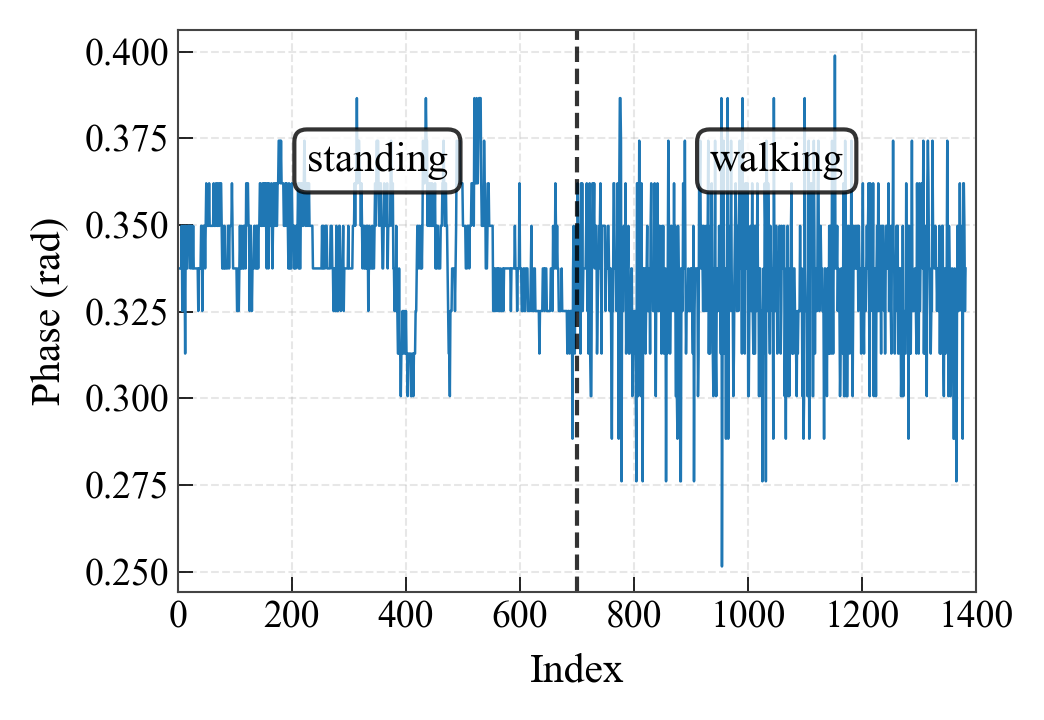

In [103]:
# --- Calculate Mean Phase (filtered by magnitude SNR) ---
mean_phase_combined = matrix_combined_phase[np.mean(matrix_combined_mag, axis=1) > 5, 0]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(3.58, 2.5))

ax.plot(mean_phase_combined, color='#1f77b4', linewidth=0.6)

# Divider & Annotations
ax.axvline(x=N_SAMPLES, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
y_txt = ax.get_ylim()[1] * 0.9
ax.text(N_SAMPLES/2, y_txt, 'standing', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(N_SAMPLES*1.5, y_txt, 'walking', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_ylabel('Phase (rad)')
ax.set_xlabel('Index')
ax.set_xlim(0, N_SAMPLES*2)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/step4phase.png')
plt.show()

In [104]:
df_selected.session_id.unique()

array(['20251010_140858', '20251010_141044', '20251010_141229',
       '20251010_141413', '20251010_141559', '20251010_141742'],
      dtype=object)

In [105]:
df_selected_pca = df[(df.environment == 'nofoil') & (df.subject.isin(['collin']))].copy()
df_selected_pca['timestamp'] = pd.to_datetime(df_selected_pca['timestamp'])

df_selected_pca = df_selected_pca[df_selected_pca.session_id.isin(df_selected_pca.session_id.unique()[:6])]
df_selected_pca = df_selected_pca.sort_values(by=['timestamp']).reset_index(drop=True)
df_selected_pca['Magnitude'] = df_selected_pca[mag_cols].mean(axis=1)
df_selected_pca = df_selected_pca[df_selected_pca['Magnitude'] > 5].copy()
df_selected_pca = apply_pca_separate(df_selected_pca, mag_cols, phase_cols, 1, 1)

start_index = pd.merge(df_selected_pca.reset_index().groupby('session_id').index.min(), df_selected_pca['activity'].reset_index(), on = 'index')


pca_col = f'PCA_Mag_1'

In [106]:
mag_ratio1_pca = df_selected_pca[df_selected_pca.session_id == '20251010_140858'][pca_col].iloc[:700]
mag_ratio2_pca = df_selected_pca[df_selected_pca.session_id == '20251010_141044'][pca_col].iloc[:700]
phase_ratio1_pca = df_selected_pca[df_selected_pca.session_id == '20251010_140858']['PCA_Phase_1'].iloc[:700]
phase_ratio2_pca = df_selected_pca[df_selected_pca.session_id == '20251010_141044']['PCA_Phase_1'].iloc[:700]


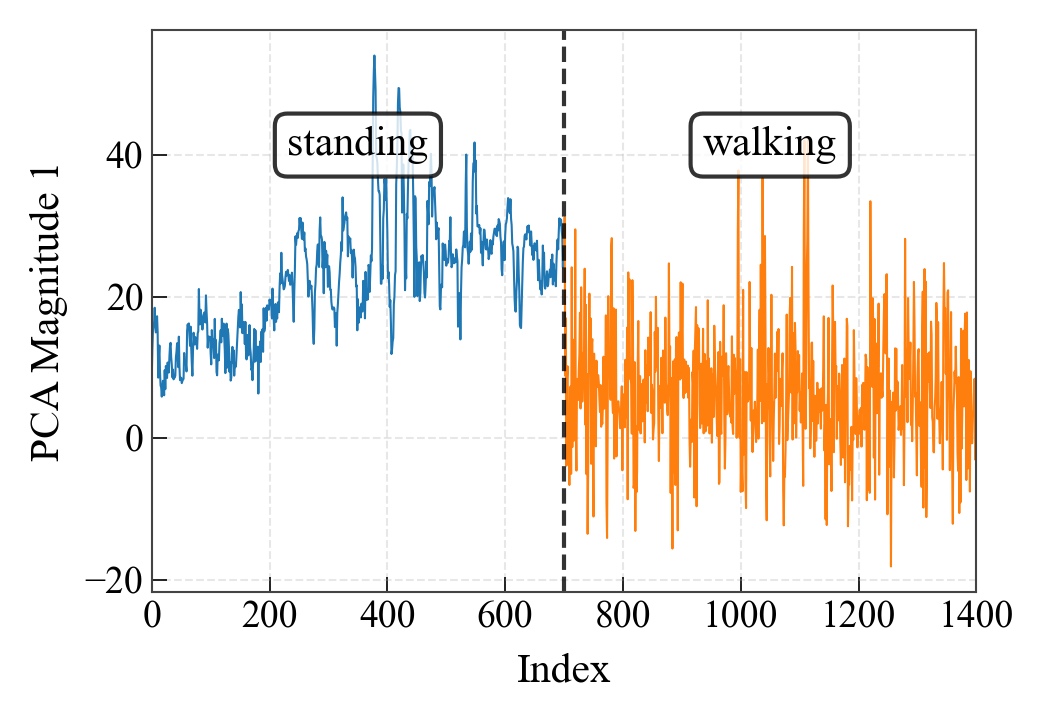

In [107]:
# --- Apply PCA ---

# --- Plotting ---
fig, ax = plt.subplots(figsize=(3.58, 2.5))

ax.plot(np.arange(N_SAMPLES), mag_ratio1_pca, 
        color='#1f77b4', linewidth=0.5)

# Plot Walking
ax.plot(np.arange(N_SAMPLES, N_SAMPLES*2), mag_ratio2_pca, 
            color='#ff7f0e', linewidth=0.5)

# Divider & Annotations
ax.axvline(x=N_SAMPLES, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
y_txt = ax.get_ylim()[1] * 0.9
ax.text(N_SAMPLES/2, 40, 'standing', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(N_SAMPLES*1.5, 40, 'walking', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_ylabel('PCA Magnitude 1')
ax.set_xlabel('Index')
ax.set_xlim(0, N_SAMPLES*2)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/step5mag.png')
plt.show()

In [108]:
phase_ratio1_pca

0     -0.722134
1     -0.721504
2     -0.717350
3     -0.705712
4     -0.799704
         ...   
703   -0.813173
704   -0.801623
705   -0.808082
707   -0.691697
708   -0.818820
Name: PCA_Phase_1, Length: 700, dtype: float64

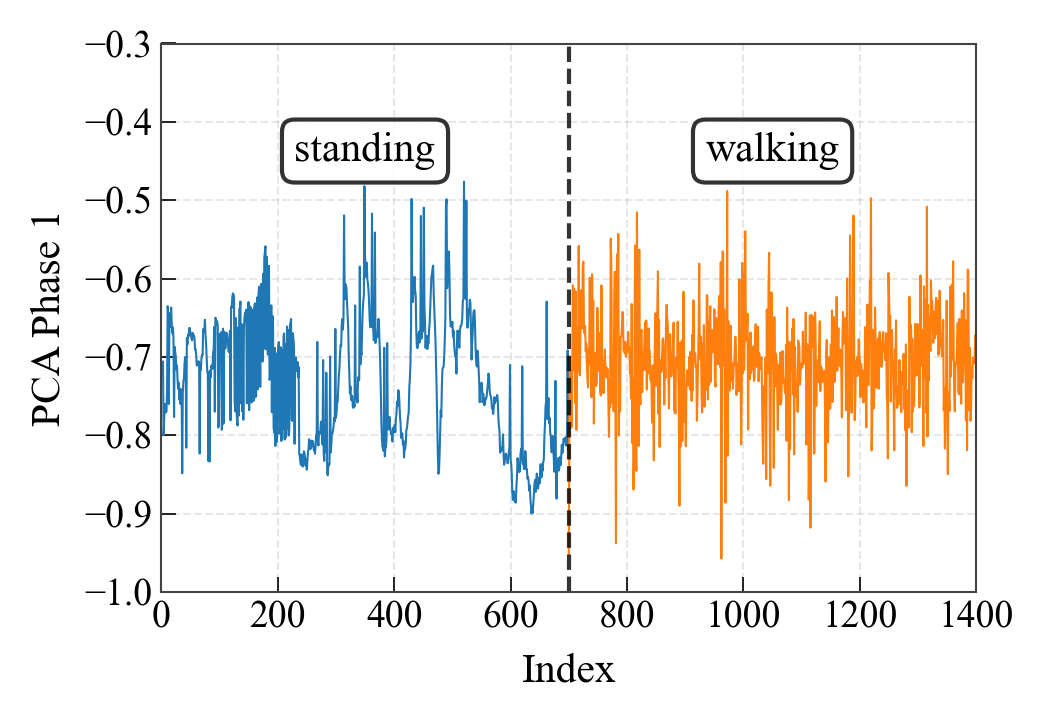

In [109]:
# --- Apply PCA ---

# --- Plotting ---
fig, ax = plt.subplots(figsize=(3.58, 2.5))

ax.plot(np.arange(N_SAMPLES), phase_ratio1_pca, 
        color='#1f77b4', linewidth=0.5)

# Plot Walking
ax.plot(np.arange(N_SAMPLES, N_SAMPLES*2), phase_ratio2_pca, 
            color='#ff7f0e', linewidth=0.5)

ax.set_ylim(-1, -0.3)
# Divider & Annotations
ax.axvline(x=N_SAMPLES, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
y_txt = ax.get_ylim()[1] * 0.9
ax.text(N_SAMPLES/2, -0.45, 'standing', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.text(N_SAMPLES*1.5, -0.45, 'walking', ha='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_ylabel('PCA Phase 1')
ax.set_xlabel('Index')
ax.set_xlim(0, N_SAMPLES*2)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/step5phase.png')
plt.show()

In [110]:
import pandas as pd
import numpy as np

# ============================================================================
# Visualization of intermediate pipeline steps (uses constants from Cell 17)
# ============================================================================
pca_stand = mag_ratio1_pca
pca_walk  = mag_ratio2_pca

def process_pipeline_steps(data_array, session_id='dummy_session'):
    """
    Runs the pipeline on a single array to visualize intermediate steps.
    Uses W_SPREAD, W_LOCATION, IQR_F from Cell 17.
    """
    df_temp = pd.DataFrame({
        'session_id': [session_id] * len(data_array),
        'timestamp': np.arange(len(data_array)),
        'PCA_Mag_1': data_array
    })
    
    # 1. Winsorization (Window=W_SPREAD, 1.5 IQR)
    grouper = df_temp.groupby('session_id')['PCA_Mag_1']
    roll = grouper.rolling(window=W_SPREAD, min_periods=1)
    
    q1 = roll.quantile(0.25).reset_index(level=0, drop=True)
    q3 = roll.quantile(0.75).reset_index(level=0, drop=True)
    iqr = q3 - q1
    lower = q1 - (IQR_F * iqr)
    upper = q3 + (IQR_F * iqr)
    
    winsorized = df_temp['PCA_Mag_1'].clip(lower=lower, upper=upper)
    winsorized = winsorized.fillna(df_temp['PCA_Mag_1'])
    
    # 2. Moving Standardization (Window=W_LOCATION, Median/MAD)
    df_temp['winsorized'] = winsorized
    winsor_grouper = df_temp.groupby('session_id')['winsorized']
    roll_loc = winsor_grouper.rolling(window=W_LOCATION, min_periods=1)
    roll_spread = winsor_grouper.rolling(window=W_SPREAD, min_periods=1)
    
    rolling_median = roll_loc.median().reset_index(level=0, drop=True)
    rolling_mad = roll_spread.apply(calculate_rolling_mad, raw=True).reset_index(level=0, drop=True)
    
    standardized = (winsorized - rolling_median) / rolling_mad
    standardized = standardized.fillna(0)
    
    return winsorized.values, standardized.values

# Process Standing
win_stand, std_stand = process_pipeline_steps(pca_stand, 'sess_stand')

# Process Walking
win_walk, std_walk = process_pipeline_steps(pca_walk, 'sess_walk')

# Concatenate for Plotting
win_combined = np.concatenate([win_stand, win_walk])
std_combined = np.concatenate([std_stand, std_walk])

print("Calculation complete.")
print(f"Winsorized Shape: {win_combined.shape}")
print(f"Standardized Shape: {std_combined.shape}")

Calculation complete.
Winsorized Shape: (1400,)
Standardized Shape: (1400,)


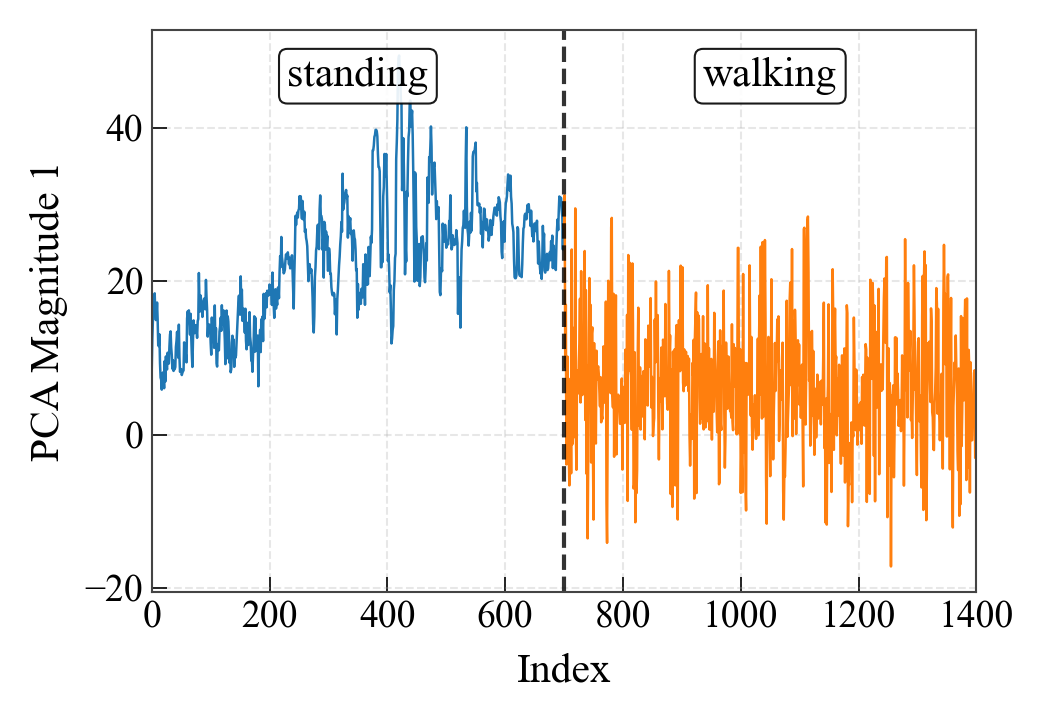

In [111]:
import matplotlib.pyplot as plt

# --- IEEE Styling ---
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman'], 'font.size': 10, 'figure.dpi': 300, 'axes.linewidth': 0.5})

# --- Plotting Winsorization ---
fig, ax = plt.subplots(figsize=(3.58, 2.5)) # Half-page width
N = 700

# Plot Left (Standing) - Blue
ax.plot(np.arange(N), win_stand, color='#1f77b4', linewidth=0.6)

# Plot Right (Walking) - Orange
ax.plot(np.arange(N, N*2), win_walk, color='#ff7f0e', linewidth=0.6)

# Visual Separator
ax.axvline(x=N, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

# Annotations
y_lim = ax.get_ylim()
y_txt = y_lim[1] - (y_lim[1] - y_lim[0]) * 0.1
ax.text(N/2, y_txt, 'standing', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))
ax.text(N*1.5, y_txt, 'walking', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))

# Formatting
ax.set_ylabel('PCA Magnitude 1')
ax.set_xlabel('Index')
ax.set_xlim(0, N*2)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/step6mag.png')
plt.show()

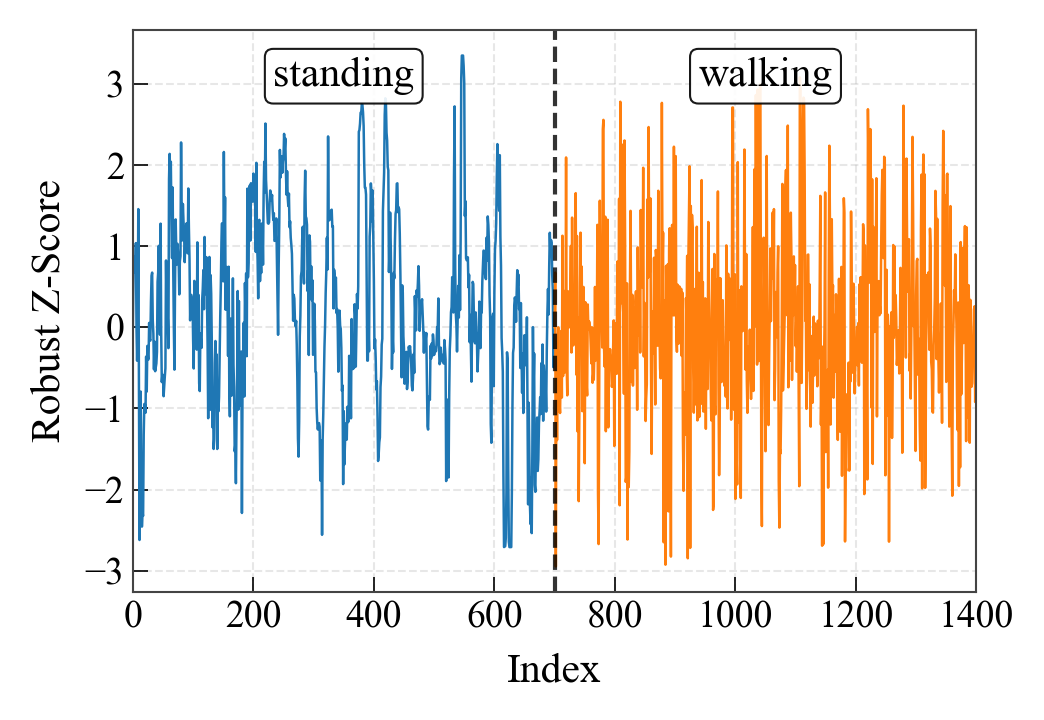

In [112]:
# --- Plotting Standardization ---
fig, ax = plt.subplots(figsize=(3.58, 2.5)) # Half-page width
N = 700

# Plot Left (Standing) - Blue
ax.plot(np.arange(N), std_stand, color='#1f77b4', linewidth=0.6)

# Plot Right (Walking) - Orange
ax.plot(np.arange(N, N*2), std_walk, color='#ff7f0e', linewidth=0.6)

# Visual Separator
ax.axvline(x=N, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

# Annotations
y_lim = ax.get_ylim()
y_txt = y_lim[1] - (y_lim[1] - y_lim[0]) * 0.1
ax.text(N/2, y_txt, 'standing', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))
ax.text(N*1.5, y_txt, 'walking', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))

# Formatting
ax.set_ylabel('Robust Z-Score')
ax.set_xlabel('Index')
ax.set_xlim(0, N*2)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/step7mag.png')
plt.show()

In [113]:
finalfeature1 = df_selected[df_selected.session_id == '20251010_140858']['feature_pca_mag_1_accel'].iloc[:700]
finalfeature2 = df_selected[df_selected.session_id == '20251010_141044']['feature_pca_mag_1_accel'].iloc[:700]


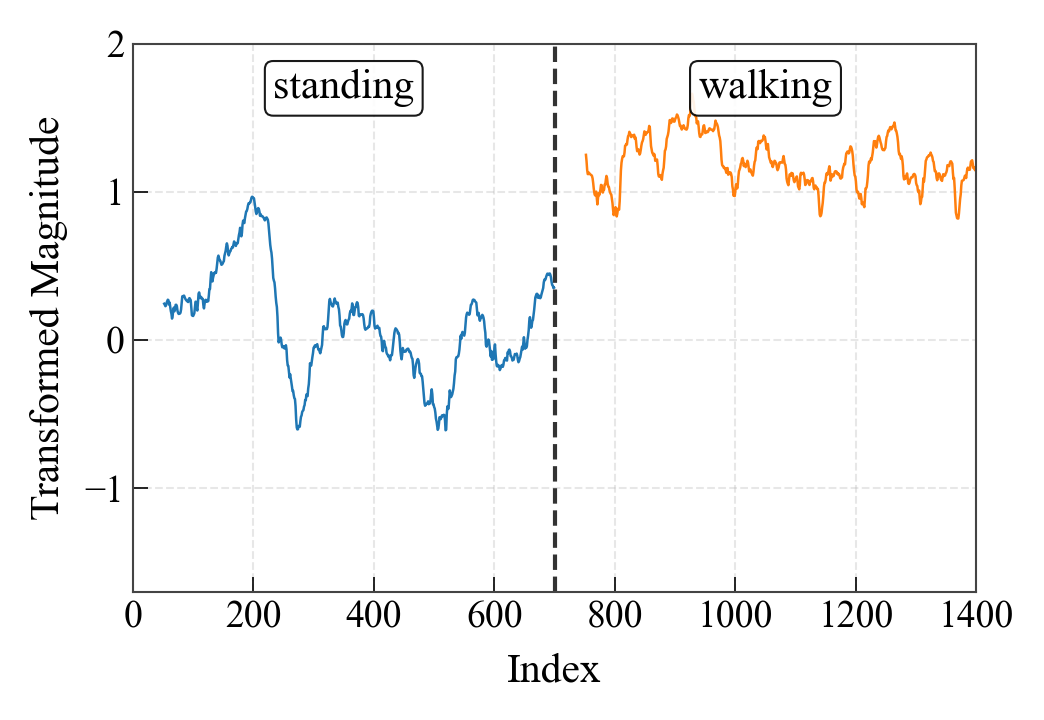

In [114]:
# --- Plotting Standardization ---
fig, ax = plt.subplots(figsize=(3.58, 2.5)) # Half-page width
N = 700

# Plot Left (Standing) - Blue
ax.plot(np.arange(N), finalfeature1, color='#1f77b4', linewidth=0.6)

# Plot Right (Walking) - Orange
ax.plot(np.arange(N, N*2), finalfeature2, color='#ff7f0e', linewidth=0.6)

# Visual Separator
ax.axvline(x=N, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

# Annotations
ax.set_ylim(-1.7, 2)
y_lim = ax.get_ylim()
y_txt = y_lim[1] - (y_lim[1] - y_lim[0]) * 0.1
ax.text(N/2, y_txt, 'standing', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))
ax.text(N*1.5, y_txt, 'walking', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))

# Formatting
ax.set_ylabel('Transformed Magnitude')
ax.set_xlabel('Index')
ax.set_xlim(0, N*2)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/step8mag.png')
plt.show()

In [115]:
import pandas as pd
import numpy as np

# ============================================================================
# Phase pipeline visualization (reuses process_pipeline_steps from Cell 37)
# ============================================================================
pca_stand = phase_ratio1_pca
pca_walk  = phase_ratio2_pca

# Process Standing
win_stand, std_stand = process_pipeline_steps(pca_stand, 'sess_stand')

# Process Walking
win_walk, std_walk = process_pipeline_steps(pca_walk, 'sess_walk')

# Concatenate for Plotting
win_combined = np.concatenate([win_stand, win_walk])
std_combined = np.concatenate([std_stand, std_walk])

print("Calculation complete.")
print(f"Winsorized Shape: {win_combined.shape}")
print(f"Standardized Shape: {std_combined.shape}")

Calculation complete.
Winsorized Shape: (1400,)
Standardized Shape: (1400,)


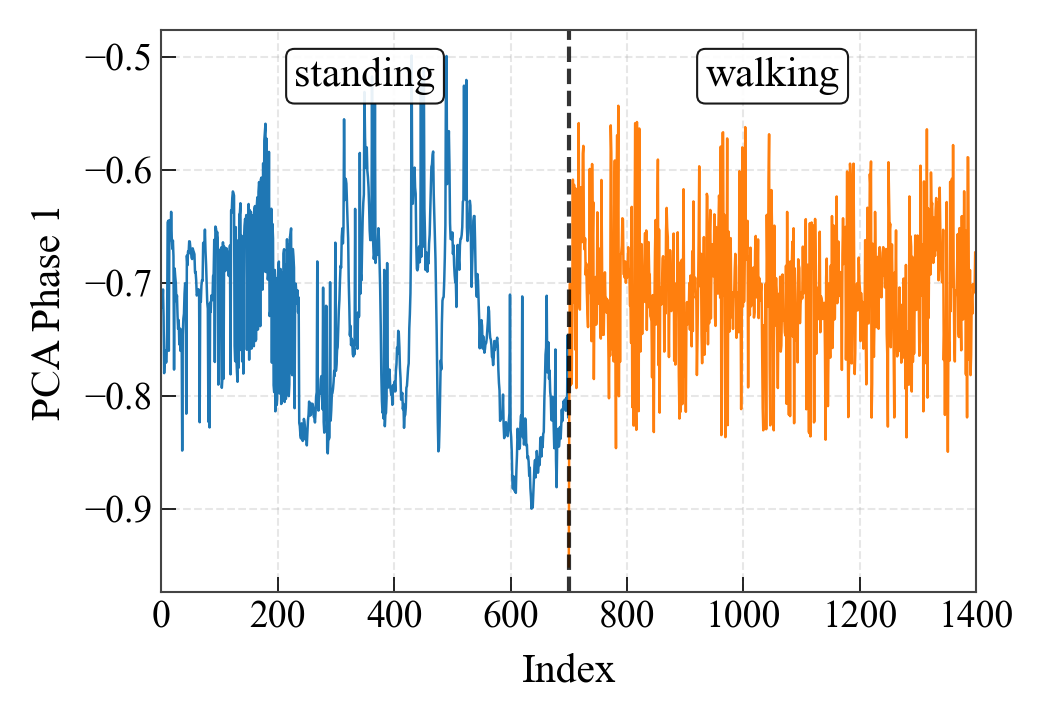

In [116]:
import matplotlib.pyplot as plt

# --- IEEE Styling ---
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman'], 'font.size': 10, 'figure.dpi': 300, 'axes.linewidth': 0.5})

# --- Plotting Winsorization ---
fig, ax = plt.subplots(figsize=(3.58, 2.5)) # Half-page width
N = 700

# Plot Left (Standing) - Blue
ax.plot(np.arange(N), win_stand, color='#1f77b4', linewidth=0.6)

# Plot Right (Walking) - Orange
ax.plot(np.arange(N, N*2), win_walk, color='#ff7f0e', linewidth=0.6)

# Visual Separator
ax.axvline(x=N, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

# Annotations
y_lim = ax.get_ylim()
y_txt = y_lim[1] - (y_lim[1] - y_lim[0]) * 0.1
ax.text(N/2, y_txt, 'standing', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))
ax.text(N*1.5, y_txt, 'walking', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))

# Formatting
ax.set_ylabel('PCA Phase 1')
ax.set_xlabel('Index')
ax.set_xlim(0, N*2)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/step6phase.png')
plt.show()

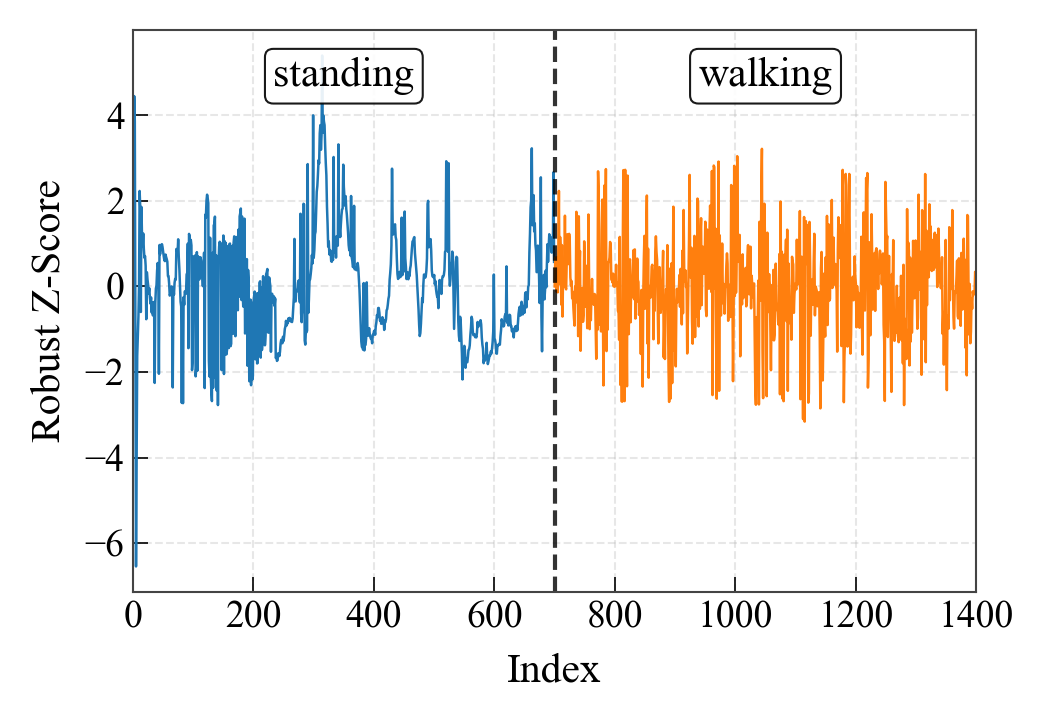

In [117]:
# --- Plotting Standardization ---
fig, ax = plt.subplots(figsize=(3.58, 2.5)) # Half-page width
N = 700

# Plot Left (Standing) - Blue
ax.plot(np.arange(N), std_stand, color='#1f77b4', linewidth=0.6)

# Plot Right (Walking) - Orange
ax.plot(np.arange(N, N*2), std_walk, color='#ff7f0e', linewidth=0.6)

# Visual Separator
ax.axvline(x=N, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

# Annotations
y_lim = ax.get_ylim()
y_txt = y_lim[1] - (y_lim[1] - y_lim[0]) * 0.1
ax.text(N/2, y_txt, 'standing', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))
ax.text(N*1.5, y_txt, 'walking', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))

# Formatting
ax.set_ylabel('Robust Z-Score')
ax.set_xlabel('Index')
ax.set_xlim(0, N*2)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/step7phase.png')
plt.show()

In [118]:
finalfeature1 = df_selected[df_selected.session_id == '20251010_140858']['feature_pca_phase_1_accel'].iloc[:700]
finalfeature2 = df_selected[df_selected.session_id == '20251010_141044']['feature_pca_phase_1_accel'].iloc[:700]


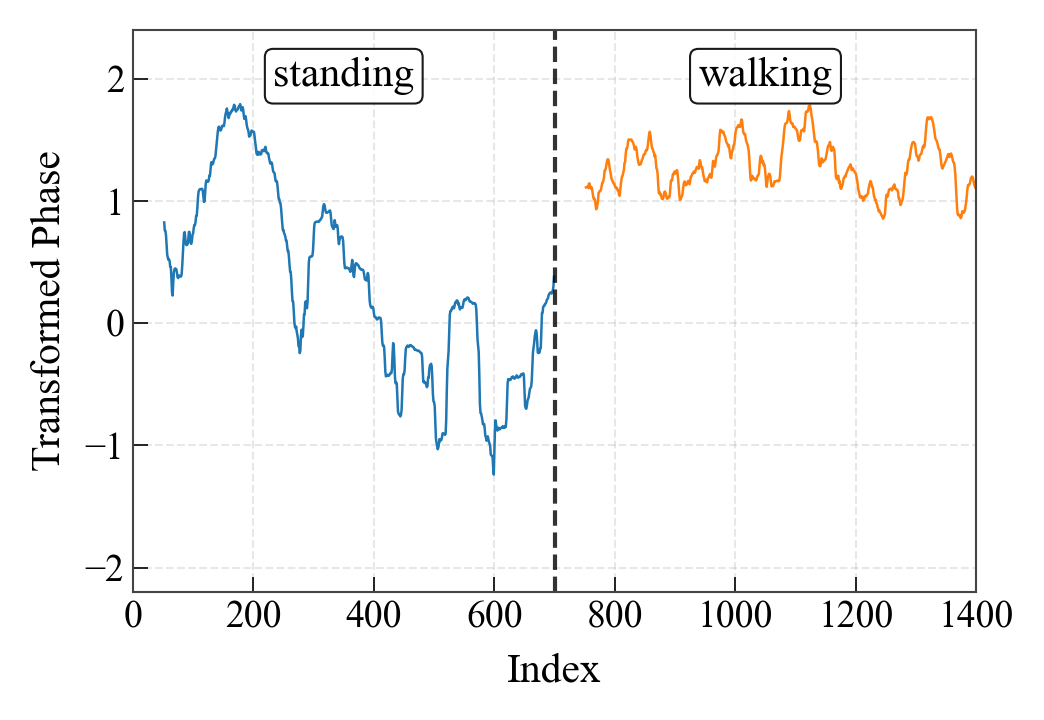

In [119]:
# --- Plotting Standardization ---
fig, ax = plt.subplots(figsize=(3.58, 2.5)) # Half-page width
N = 700

# Plot Left (Standing) - Blue
ax.plot(np.arange(N), finalfeature1, color='#1f77b4', linewidth=0.6)

# Plot Right (Walking) - Orange
ax.plot(np.arange(N, N*2), finalfeature2, color='#ff7f0e', linewidth=0.6)

# Visual Separator
ax.axvline(x=N, color='black', linestyle='--', linewidth=1.0, alpha=0.8)

ax.set_ylim(-2.2, 2.4)
# Annotations
y_lim = ax.get_ylim()
y_txt = y_lim[1] - (y_lim[1] - y_lim[0]) * 0.1
ax.text(N/2, y_txt, 'standing', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))
ax.text(N*1.5, y_txt, 'walking', ha='center', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9, linewidth=0.5))

# Formatting
ax.set_ylabel('Transformed Phase')
ax.set_xlabel('Index')
ax.set_xlim(0, N*2)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/step8phase.png')
plt.show()

## Comprehensive Pipeline Visualization (IEEE Sensors Journal Figure)

Samples — raw: 700, clean: 700/700, LMAD: 700/700


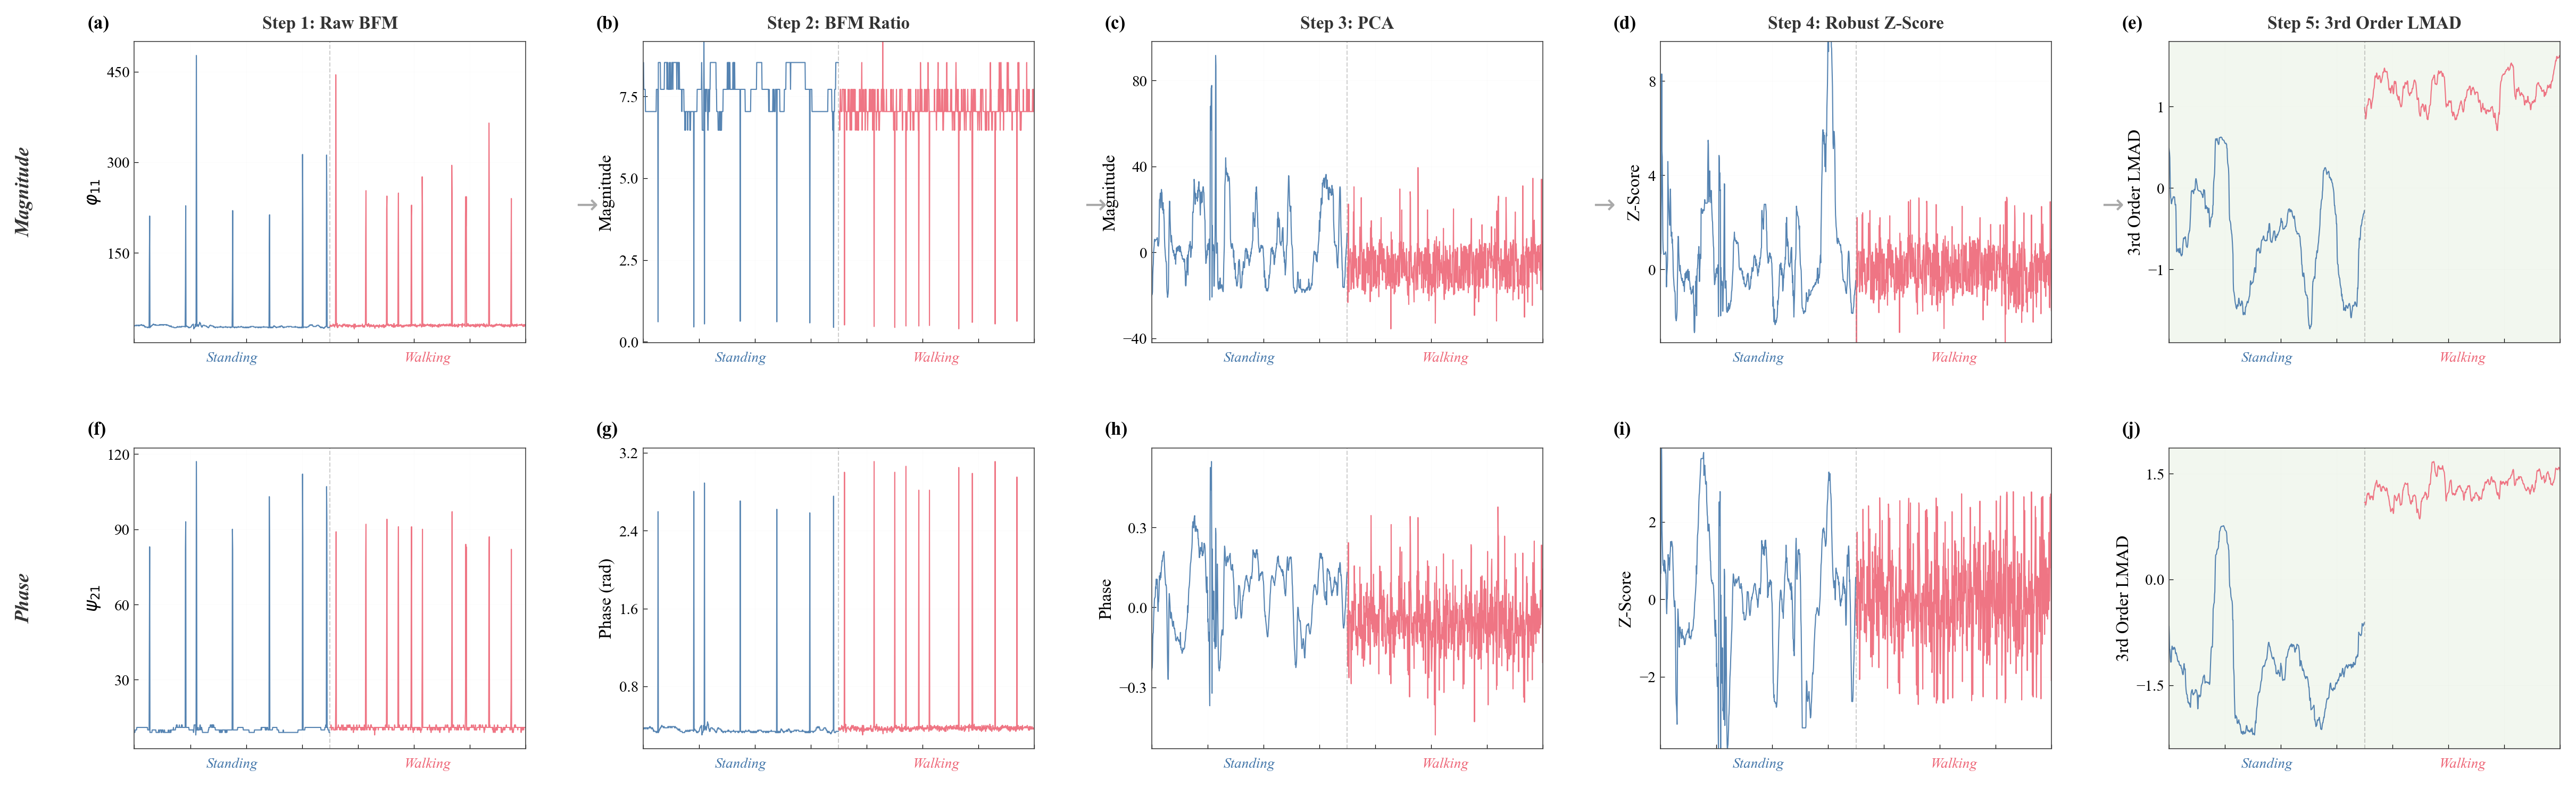

Saved → plots/fig_pipeline_overview.pdf & .png


In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ============================================================================
# IEEE Sensors Journal — Full Pipeline Figure (Horizontal Layout)
# 2 rows × 5 columns: Magnitude (top), Phase (bottom)
# Steps flow left → right: Raw BFM → BFM Ratio → PCA → Z-Score → 3rd Order LMAD
# ============================================================================

SESS_STAND = '20251010_143551'
SESS_WALK  = '20251010_143736'
SC_IDX     = -122
N          = 700

# --- Color Palette (Tol Bright — colorblind + grayscale safe) ---
C_STAND  = '#4477AA'
C_WALK   = '#EE6677'
C_DIV    = '#888888'
C_FINAL  = '#F2F7EF'

# ============================================================================
# IEEE STYLING
# ============================================================================
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'axes.linewidth': 0.4,
    'grid.linewidth': 0.15,
    'lines.linewidth': 0.5,
    'axes.edgecolor': '#444444',
    'xtick.major.width': 0.4,
    'ytick.major.width': 0.4,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.pad': 2,
    'ytick.major.pad': 2,
})

# ============================================================================
# 1. DATA
# ============================================================================

# Stage 1: Raw Compressed BFM
raw_s_df = pd.read_csv(f'bfm_raw_csv/bfm_data_standing_abel_alt_nofoil_{SESS_STAND}.csv')
raw_w_df = pd.read_csv(f'bfm_raw_csv/bfm_data_walking_abel_alt_nofoil_{SESS_WALK}.csv')
raw_phi_s = raw_s_df[f'SCIDX_{SC_IDX}_phi11'].iloc[:N].values
raw_phi_w = raw_w_df[f'SCIDX_{SC_IDX}_phi11'].iloc[:N].values
raw_psi_s = raw_s_df[f'SCIDX_{SC_IDX}_psi21'].iloc[:N].values
raw_psi_w = raw_w_df[f'SCIDX_{SC_IDX}_psi21'].iloc[:N].values

# Stage 2: BFM Ratio (from combined df)
ratio_mag_s = df[df.session_id == SESS_STAND][f'SCIDX_{SC_IDX}_Ratio_Mag'].iloc[:N].values
ratio_mag_w = df[df.session_id == SESS_WALK][f'SCIDX_{SC_IDX}_Ratio_Mag'].iloc[:N].values
ratio_pha_s = df[df.session_id == SESS_STAND][f'SCIDX_{SC_IDX}_Ratio_Phase'].iloc[:N].values
ratio_pha_w = df[df.session_id == SESS_WALK][f'SCIDX_{SC_IDX}_Ratio_Phase'].iloc[:N].values

# Stage 3–5: PCA → Z-Score → LMAD
df_pipe = df[df.session_id.isin([SESS_STAND, SESS_WALK])].copy()
df_pipe['timestamp'] = pd.to_datetime(df_pipe['timestamp'])
df_pipe = df_pipe.sort_values('timestamp').reset_index(drop=True)
df_pipe = df_pipe[df_pipe[mag_cols].mean(axis=1) > 5].copy().reset_index(drop=True)
df_pipe = apply_pca_separate(df_pipe, mag_cols, phase_cols, 1, 1)
df_pipe = create_r_features(df_pipe.copy(), base_col='PCA_Mag_1')
df_pipe = create_r_features(df_pipe, base_col='PCA_Phase_1')

def get(sess, col):
    v = df_pipe[df_pipe.session_id == sess][col].dropna().values
    return v[:min(len(v), N)]

pca_mag_s, pca_mag_w = get(SESS_STAND, 'PCA_Mag_1'),     get(SESS_WALK, 'PCA_Mag_1')
pca_pha_s, pca_pha_w = get(SESS_STAND, 'PCA_Phase_1'),    get(SESS_WALK, 'PCA_Phase_1')
z_mag_s,   z_mag_w   = get(SESS_STAND, 'PCA_Mag_1_robust_z'),   get(SESS_WALK, 'PCA_Mag_1_robust_z')
z_pha_s,   z_pha_w   = get(SESS_STAND, 'PCA_Phase_1_robust_z'), get(SESS_WALK, 'PCA_Phase_1_robust_z')
lm_mag_s,  lm_mag_w  = get(SESS_STAND, 'feature_pca_mag_1_accel'),   get(SESS_WALK, 'feature_pca_mag_1_accel')
lm_pha_s,  lm_pha_w  = get(SESS_STAND, 'feature_pca_phase_1_accel'), get(SESS_WALK, 'feature_pca_phase_1_accel')

print(f"Samples — raw: {N}, clean: {len(pca_mag_s)}/{len(pca_mag_w)}, "
      f"LMAD: {len(lm_mag_s)}/{len(lm_mag_w)}")

# ============================================================================
# 2. FIGURE — 2 rows × 5 columns  (16:9 ratio)
#    Row 0 = Magnitude path,  Row 1 = Phase path
#    Col 0–4 = Step 1–5 (left → right)
# ============================================================================
fig, axes = plt.subplots(
    2, 5, figsize=(16, 5.4),
    gridspec_kw={'hspace': 0.35, 'wspace': 0.30}
)
fig.subplots_adjust(top=0.88, bottom=0.06, left=0.04, right=0.99)

# Step titles for column headers
step_titles = [
    'Step 1: Raw BFM',
    'Step 2: BFM Ratio',
    'Step 3: PCA',
    'Step 4: Robust Z-Score',
    'Step 5: 3rd Order LMAD',
]

# --- Panel config: [row][col] ---
#   row 0 = magnitude, row 1 = phase
#   col 0-4 = steps 1-5
cfg = [
    # (row, col, stand, walk, ylabel, label, ylim_pct)
    (0, 0, raw_phi_s,   raw_phi_w,   r'$\varphi_{11}$',     '(a)', None),
    (0, 1, ratio_mag_s,  ratio_mag_w, 'Magnitude',           '(b)', (1, 97)),
    (0, 2, pca_mag_s,   pca_mag_w,   'Magnitude',            '(c)', None),
    (0, 3, z_mag_s,     z_mag_w,     'Z-Score',              '(d)', (1, 99)),
    (0, 4, lm_mag_s,    lm_mag_w,    '3rd Order LMAD',       '(e)', None),
    (1, 0, raw_psi_s,   raw_psi_w,   r'$\psi_{21}$',         '(f)', None),
    (1, 1, ratio_pha_s,  ratio_pha_w, 'Phase (rad)',          '(g)', None),
    (1, 2, pca_pha_s,   pca_pha_w,   'Phase',                '(h)', None),
    (1, 3, z_pha_s,     z_pha_w,     'Z-Score',              '(i)', (1, 99)),
    (1, 4, lm_pha_s,    lm_pha_w,    '3rd Order LMAD',       '(j)', None),
]

for (row, col, s, w, ylabel, label, ylim_pct) in cfg:
    ax = axes[row, col]
    n_s, n_w = len(s), len(w)

    # Highlight final column
    if col == 4:
        ax.set_facecolor(C_FINAL)

    # Plot
    ax.plot(np.arange(n_s), s,
            color=C_STAND, lw=0.5, alpha=0.9, rasterized=True)
    ax.plot(np.arange(n_s, n_s + n_w), w,
            color=C_WALK, lw=0.5, alpha=0.9, rasterized=True)

    # Robust y-limits to handle outlier spikes
    if ylim_pct is not None:
        all_vals = np.concatenate([s, w])
        lo = np.nanpercentile(all_vals, ylim_pct[0])
        hi = np.nanpercentile(all_vals, ylim_pct[1])
        margin = (hi - lo) * 0.08
        ax.set_ylim(lo - margin, hi + margin)

    # Divider
    ax.axvline(x=n_s, color=C_DIV, ls='--', lw=0.5, alpha=0.4)

    # Formatting
    ax.set_ylabel(ylabel, labelpad=2)
    ax.set_xlim(0, n_s + n_w)
    ax.grid(True, ls='-', alpha=0.08, lw=0.12)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    ax.tick_params(width=0.3, length=2)

    # Hide x-axis numbers — activity labels replace them
    ax.tick_params(labelbottom=False)
    ax.set_xlabel('')

    # Activity labels below each panel
    ax.text(n_s * 0.5, -0.03, 'Standing', ha='center', va='top',
            fontsize=6.5, color=C_STAND, fontstyle='italic',
            transform=ax.get_xaxis_transform(), clip_on=False)
    ax.text(n_s + n_w * 0.5, -0.03, 'Walking', ha='center', va='top',
            fontsize=6.5, color=C_WALK, fontstyle='italic',
            transform=ax.get_xaxis_transform(), clip_on=False)

    # Panel label
    ax.text(-0.12, 1.03, label, transform=ax.transAxes,
            fontsize=8.5, fontweight='bold', va='bottom')

# --- Column headers (step titles above top row) ---
for c, title in enumerate(step_titles):
    ax_top = axes[0, c]
    ax_top.set_title(title, fontsize=8, fontweight='bold', color='#333333',
                     pad=6)

# --- Row labels on the left ---
axes[0, 0].text(-0.28, 0.5, 'Magnitude', transform=axes[0, 0].transAxes,
                fontsize=9, fontweight='bold', fontstyle='italic',
                color='#333333', ha='center', va='center', rotation=90)
axes[1, 0].text(-0.28, 0.5, 'Phase', transform=axes[1, 0].transAxes,
                fontsize=9, fontweight='bold', fontstyle='italic',
                color='#333333', ha='center', va='center', rotation=90)

# --- Right-arrows between columns ---
for c in range(4):
    pos_r = axes[0, c].get_position()
    pos_l = axes[0, c + 1].get_position()
    x_mid = (pos_r.x1 + pos_l.x0) / 2
    y_mid = (axes[0, 0].get_position().y0 + axes[1, 0].get_position().y1) / 2 + 0.22
    fig.text(x_mid, y_mid, r'$\rightarrow$', ha='center', va='center',
             fontsize=12, color='#AAAAAA', transform=fig.transFigure)

# ============================================================================
# 3. SAVE
# ============================================================================
plt.savefig('plots/fig_pipeline_overview.pdf', bbox_inches='tight', pad_inches=0.03)
plt.savefig('plots/fig_pipeline_overview.png', bbox_inches='tight', pad_inches=0.03, dpi=600)
plt.show()
print("Saved → plots/fig_pipeline_overview.pdf & .png")

In [121]:
df_selected.session_id.unique()

array(['20251010_140858', '20251010_141044', '20251010_141229',
       '20251010_141413', '20251010_141559', '20251010_141742'],
      dtype=object)

In [122]:
df_selected.reset_index()

,index,session_id,environment,subject,activity,timestamp,receiver_address,destination_address,transmitter_address,source_address,...,SCIDX_121_Ratio_Phase,SCIDX_122_Ratio_Phase,timestamp_s,Magnitude,PCA_Mag_1,PCA_Phase_1,PCA_Mag_1_robust_z,feature_pca_mag_1_accel,PCA_Phase_1_robust_z,feature_pca_phase_1_accel
0,0,20251010_140858,nofoil,collin,standing,2025-10-10 13:09:57.509223938+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,...,0.386563,0.386563,97307.163913,10.513514,8.461756,-0.722134,0.000000,NaN,0.000000,NaN
1,1,20251010_140858,nofoil,collin,standing,2025-10-10 13:09:57.606304884+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,...,0.398835,0.386563,97307.260994,10.602918,12.494241,-0.721504,0.674490,NaN,0.674490,NaN
2,2,20251010_140858,nofoil,collin,standing,2025-10-10 13:09:57.703959942+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,...,0.398835,0.386563,97307.358649,10.610024,14.994256,-0.717350,0.674490,NaN,4.450944,NaN
3,3,20251010_140858,nofoil,collin,standing,2025-10-10 13:09:57.800997972+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,...,0.411107,0.398835,97307.455687,10.588497,16.022382,-0.705712,0.871041,NaN,3.867434,NaN
4,4,20251010_140858,nofoil,collin,standing,2025-10-10 13:09:57.900851965+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,...,0.411107,0.398835,97307.555541,10.531784,16.381805,-0.799704,0.674490,NaN,-1.267263,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5525,5525,20251010_141742,nofoil,collin,walking,2025-10-10 13:20:12.276705027+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,...,0.055223,0.067495,97921.931394,10.861409,-36.788037,3.606054,2.315529,1.351071,-0.931594,1.248384
5526,5526,20251010_141742,nofoil,collin,walking,2025-10-10 13:20:12.375201941+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,...,0.042951,0.055223,97922.029891,10.945891,-36.959175,3.539104,2.158847,1.364498,-1.110626,1.169444
5527,5527,20251010_141742,nofoil,collin,walking,2025-10-10 13:20:12.474126101+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,...,0.067495,0.067495,97922.128815,11.013044,-40.050095,3.637695,0.619719,1.354597,-0.713562,1.112632
5528,5528,20251010_141742,nofoil,collin,walking,2025-10-10 13:20:12.571388006+00:00,00:03:7f:25:14:25,00:03:7f:25:14:25,ce:23:64:bb:57:4b,ce:23:64:bb:57:4b,...,0.055223,0.055223,97922.226077,10.960250,-40.499820,3.952331,0.353339,1.364353,0.393472,1.092284


In [123]:
df_selected.session_id.unique()[:1]

array(['20251010_140858'], dtype=object)

$$
F_t = \ln \left( \frac{1}{W-2} \sum_{k=t-W+3}^{t} \left|\Delta^2 Z_k\right| \right), \quad \text{where } W=30
$$

In [124]:

def median_filter(df, cols, window_size=3):
    """
    Apply a median filter to all numeric columns in a DataFrame.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame with columns to filter
    window_size : int, default=3
        Size of the rolling window for median calculation (must be odd)
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with median filtered values
    """
    if window_size % 2 == 0:
        raise ValueError("Window size must be odd")
    
    # Create a copy to avoid modifying original
    result = df.copy()
    
    # Apply median filter to each numeric column
    for col in cols:
        
        result[col] = df[col].rolling(
            window=window_size, 
            center=True, 
            min_periods=1
        ).median()
    
    return result


In [125]:
from scipy.signal import savgol_filter

def savitzky_golay_filter(df, cols, window_length=5, polyorder=2, deriv=0):
    """
    Apply a Savitzky-Golay filter to all numeric columns in a DataFrame.
    
    The Savitzky-Golay filter is a smoothing filter that fits successive 
    sub-sets of adjacent data points with a low-degree polynomial by 
    linear least squares. It's better at preserving features like peak 
    heights and widths compared to moving averages.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame with columns to filter
    window_length : int, default=5
        Length of the filter window (must be odd and >= polyorder + 2)
    polyorder : int, default=2
        Order of the polynomial used to fit the samples (must be < window_length)
    deriv : int, default=0
        Order of the derivative to compute (0 means no derivative, just smoothing)
        
    Returns:
    --------
    pandas.DataFrame
        DataFrame with Savitzky-Golay filtered values
    """
    if window_length % 2 == 0:
        raise ValueError("Window length must be odd")
    
    if polyorder >= window_length:
        raise ValueError("polyorder must be less than window_length")
    
    # Create a copy to avoid modifying original
    result = df.copy()
    
    # Apply Savitzky-Golay filter to each numeric column
    for col in cols:
    
        mask = df[col].notna()
        if mask.sum() >= window_length:
            result.loc[mask, col] = savgol_filter(
                df.loc[mask, col],
                window_length=window_length,
                polyorder=polyorder,
                deriv=deriv
            )
    
    return result

In [126]:

df_median_filt = median_filter(df, mag_cols)
df_sav_filt = savitzky_golay_filter(df, mag_cols)

<Axes: ylabel='SCIDX_-94_Ratio_Mag'>

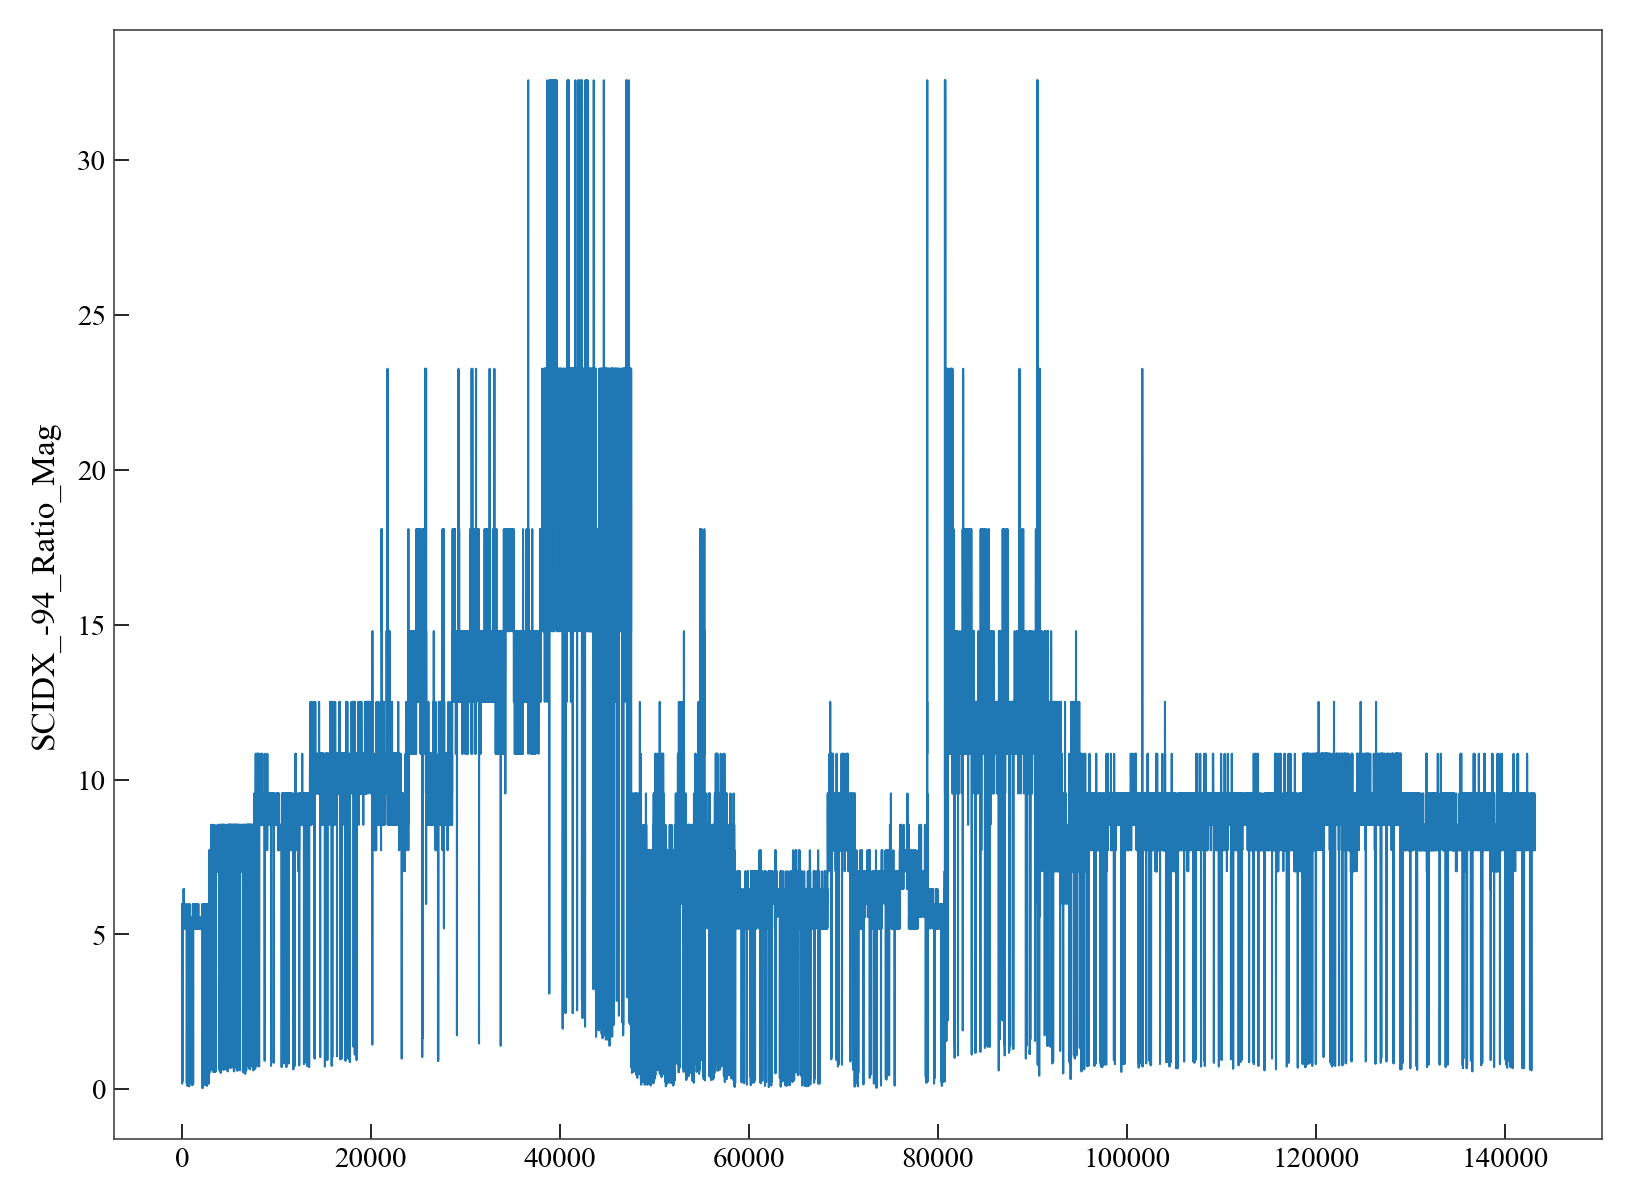

In [127]:
sns.lineplot(x = np.arange(len(df_median_filt)), y = df_median_filt[mag_cols[27]])
# sns.boxplot(data = df_median_filt[mag_cols[27]])

<Axes: ylabel='SCIDX_-94_Ratio_Mag'>

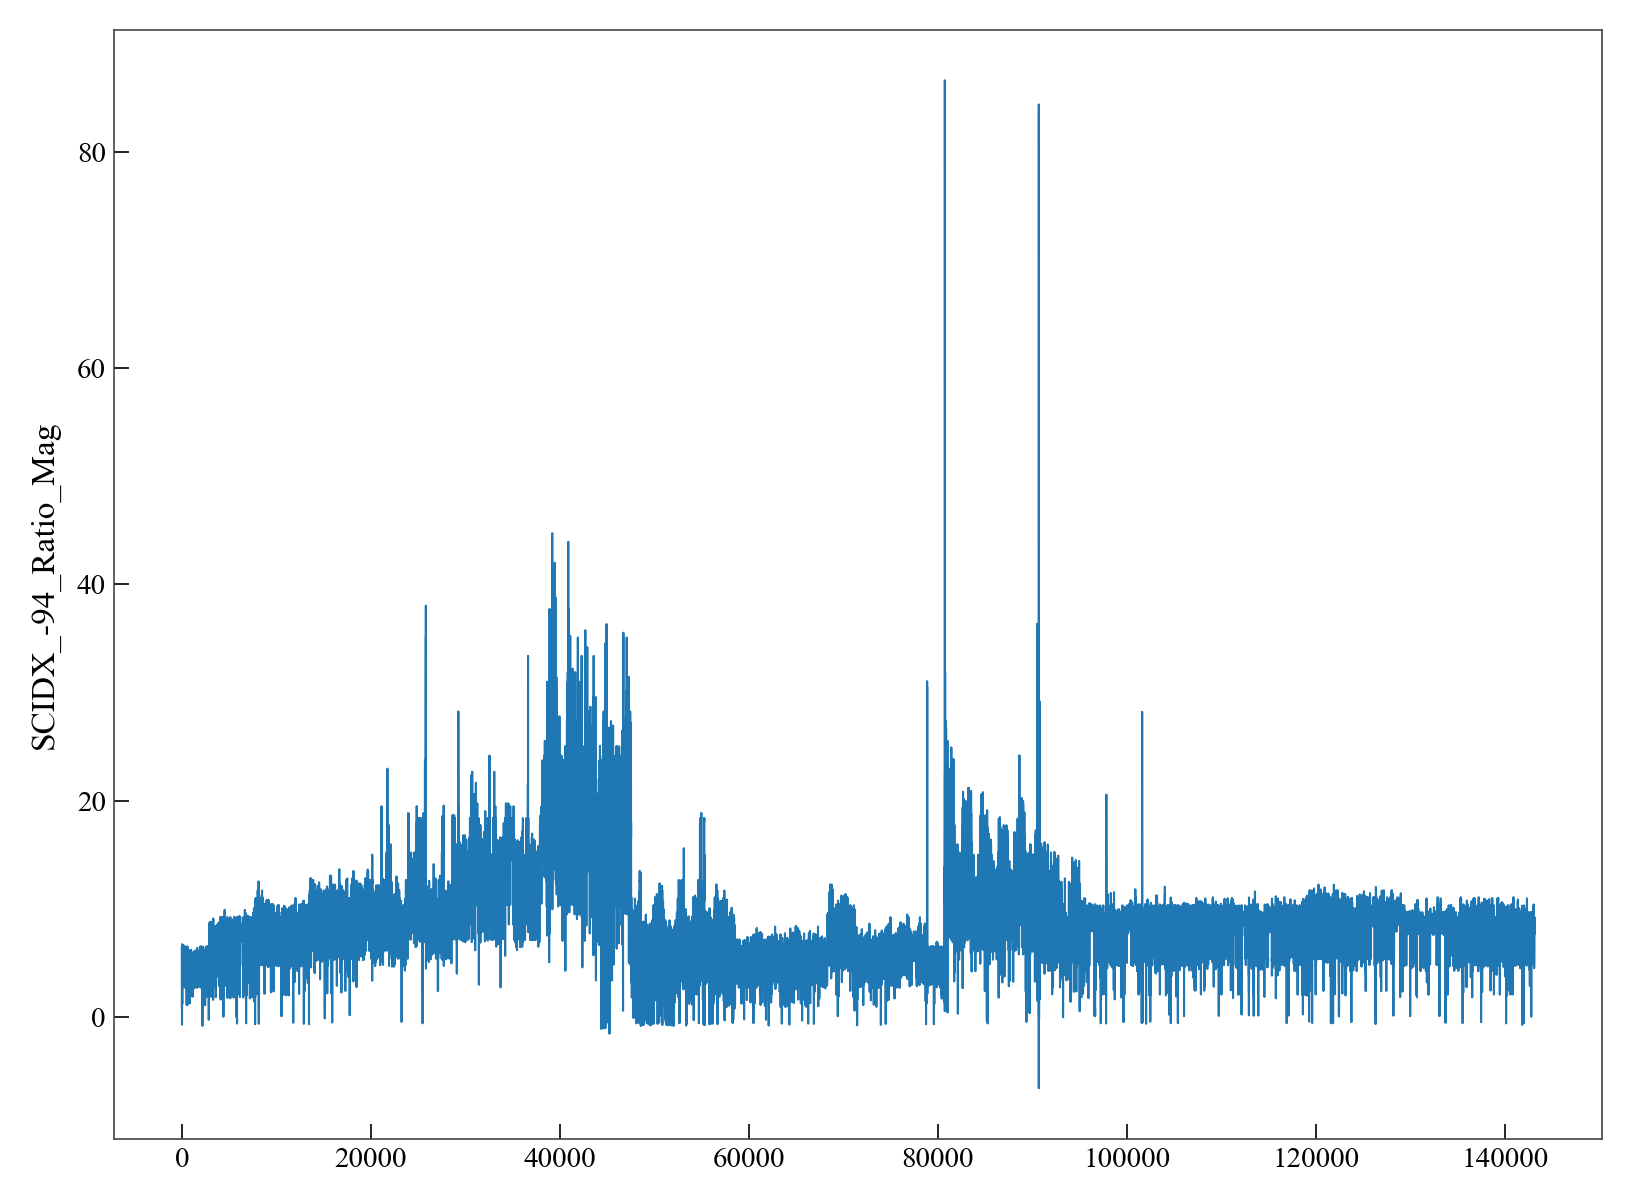

In [128]:
sns.lineplot(x = np.arange(len(df_sav_filt)), y = df_sav_filt[mag_cols[27]])
# sns.boxplot(data = df_sav_filt[mag_cols[27]])

<Axes: ylabel='Count'>

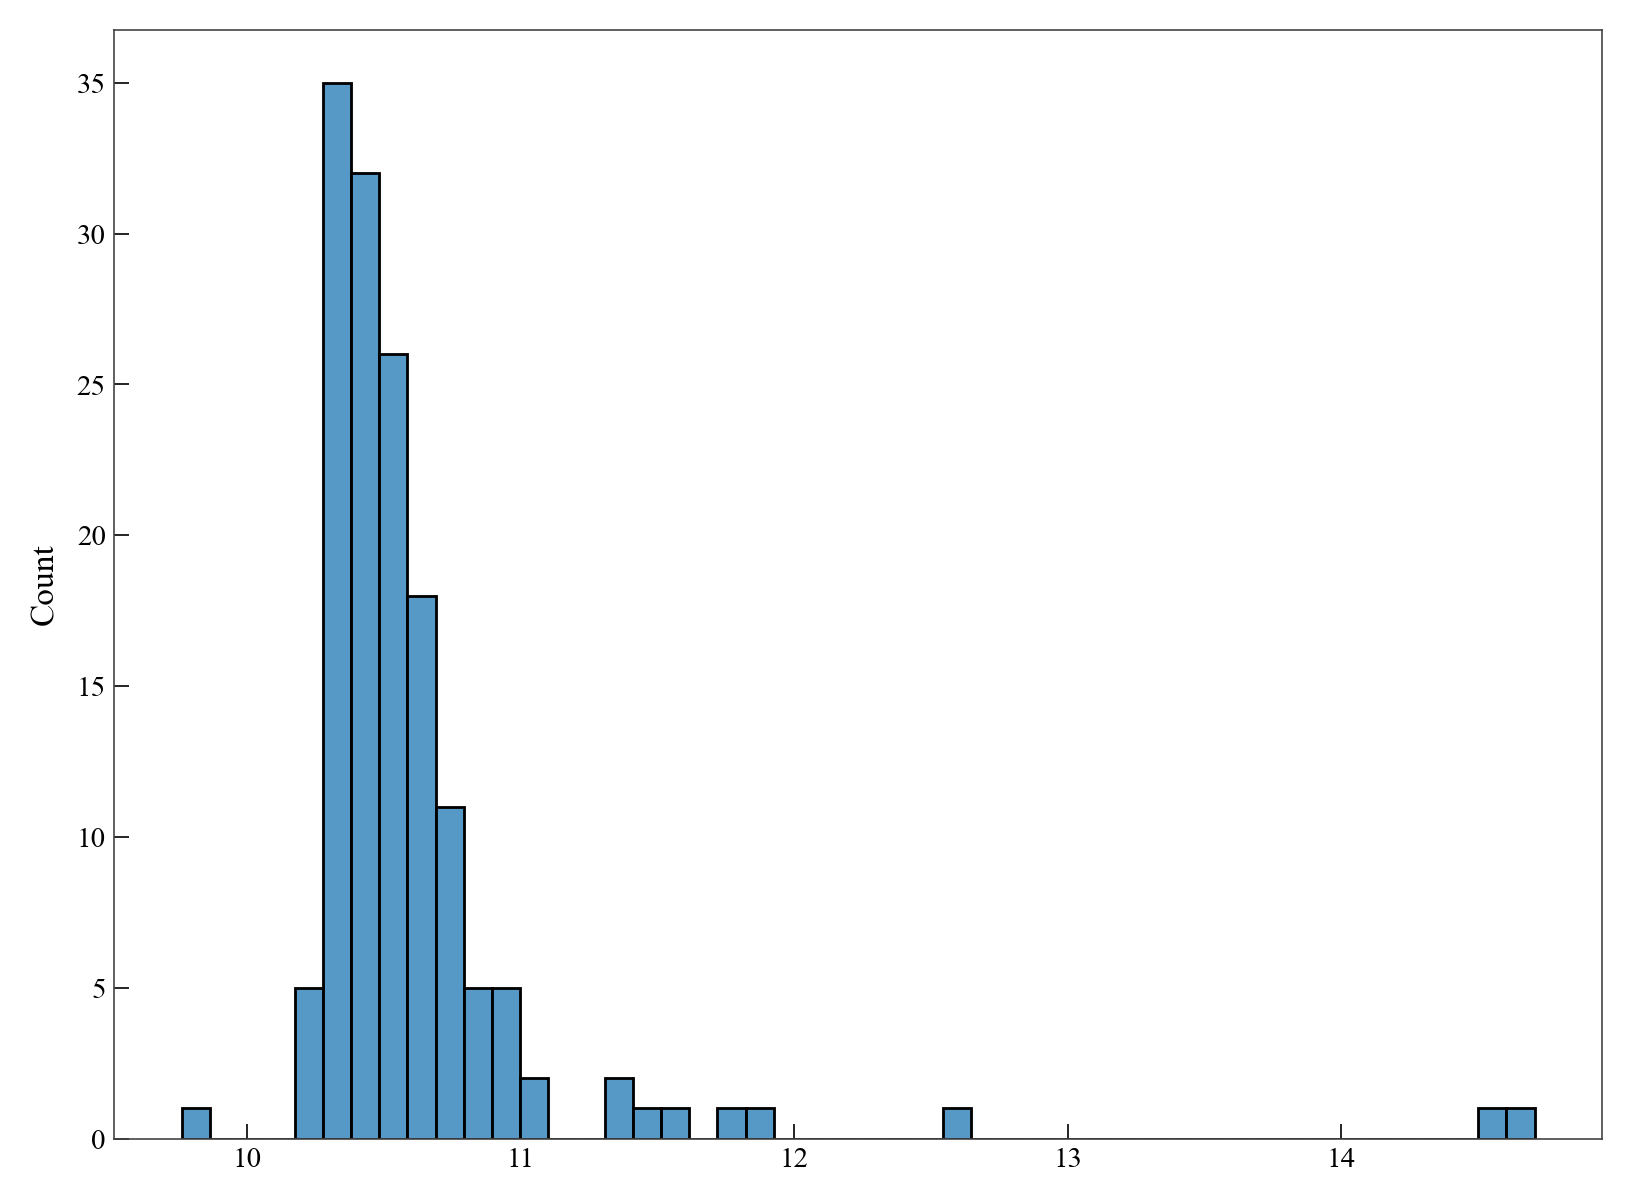

In [129]:

sampling_rates = pd.Series()

for session_id in df.session_id.unique():
    mask = df['session_id'] == session_id
    timestamp = df.loc[mask, 'timestamp']
    duration = (timestamp.iloc[-1] - timestamp.iloc[0]).total_seconds()
    sampling_rate = len(df[mask]) / duration
    sampling_rates[session_id] = sampling_rate

sns.histplot(sampling_rates)


In [130]:
print(sampling_rates.sort_values().index[len(sampling_rates) // 2])
print(sampling_rates['20251016_173252'])

20251016_173252
10.498729709019907


In [131]:
sampling_rates['20251016_173252']

10.498729709019907

In [132]:
session_id = '20251016_173252' 
fs = sampling_rates[session_id]
fc = 1.0
ORDER = 4


Wn = fc / (fs / 2)
b, a = butter(ORDER, Wn, btype='high', analog=False)

sc_columns = cols['mag_col']
sc_indices = [col.replace('_Ratio_Mag', '') for col in sc_columns]

df_filtered = df[df.session_id == session_id].copy()

for mag_col, phase_col in zip(cols['mag_col'], cols['phase_col']):
    complex_signal = df_filtered[mag_col].values * np.exp(1j * df_filtered[phase_col].values)

    filtered_complex_signal = filtfilt(b, a, complex_signal)

    df_filtered[mag_col] = np.abs(filtered_complex_signal)
    df_filtered[phase_col] = np.angle(filtered_complex_signal)


Text(0.5, 1.0, 'not_filtered')

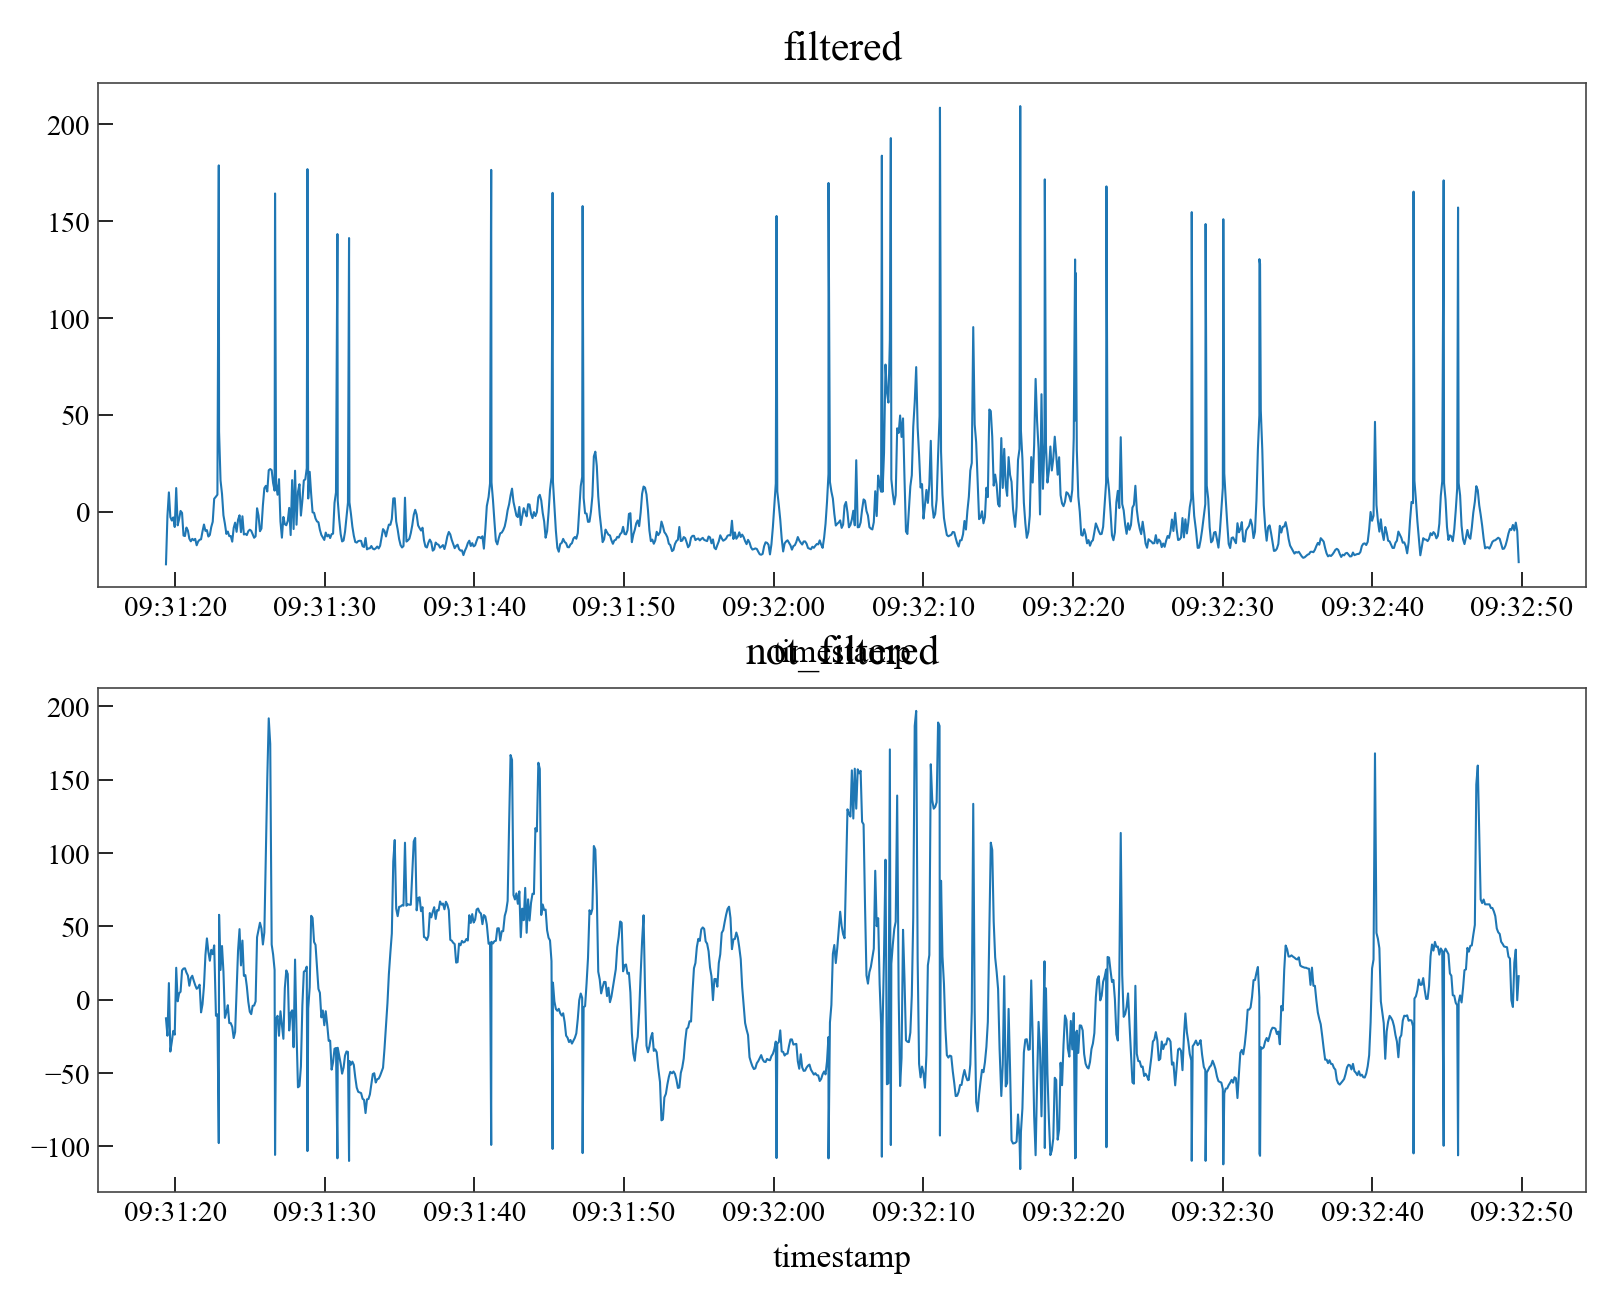

In [133]:
pca = PCA(n_components=1)

fig, (ax1, ax2) = plt.subplots(2, 1)
original_data = pca.fit_transform(df.loc[df.session_id == session_id, cols['mag_col'] + cols['phase_col']])
transformed_data = pca.fit_transform(df_filtered[cols['mag_col'] + cols['phase_col']])

sns.lineplot(x = df_filtered['timestamp'], y = transformed_data.reshape(-1), ax = ax1)
ax1.set_title('filtered')
sns.lineplot(x = df[df.session_id == session_id].timestamp, y = original_data.reshape(-1), ax = ax2)
ax2.set_title('not_filtered')


In [134]:
df_foil = df[df.environment == 'foil']
df_foil = df_foil[df_foil.session_id != '20251016_183114']

<Axes: ylabel='pca1'>

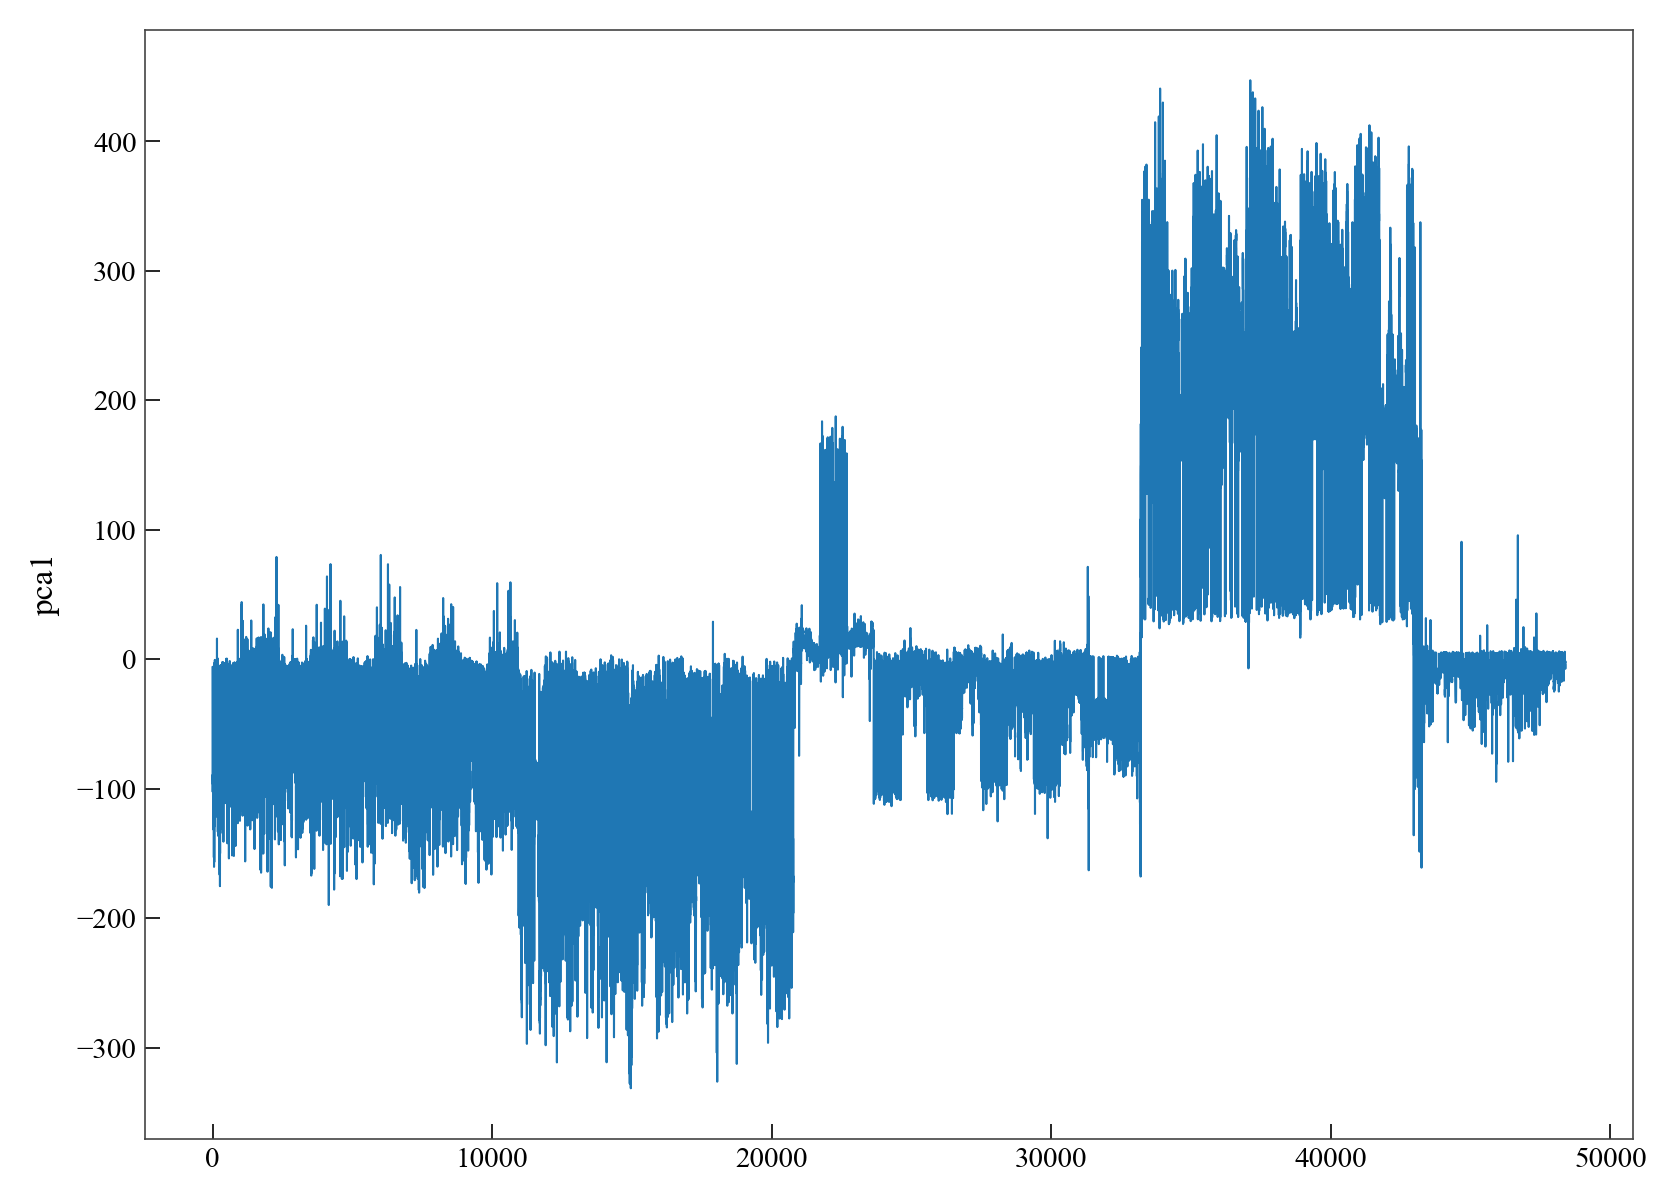

In [135]:
mag_cols = cols['mag_col']
phase_cols = cols['phase_col']

df_foil['pca1'] = pca.fit_transform(df_foil[mag_cols + phase_cols])

sns.lineplot(x=np.arange(len(df_foil)), y=df_foil['pca1'])

In [136]:
def butter_filter(df_in, session_id):
    fs = sampling_rates[session_id]
    fc = 1.0
    ORDER = 4

    Wn = fc / (fs / 2)
    b, a = butter(ORDER, Wn, btype='high', analog=False)

    df_filtered = df_in[df_in.session_id == session_id].copy()

    for mag_col, phase_col in zip(cols['mag_col'], cols['phase_col']):
        complex_signal = df_filtered[mag_col].values * np.exp(1j * df_filtered[phase_col].values)
        filtered_complex_signal = filtfilt(b, a, complex_signal)
        df_filtered[mag_col] = np.abs(filtered_complex_signal)
        df_filtered[phase_col] = np.angle(filtered_complex_signal)
    
    return df_filtered

df_butter_filtered = df_foil.copy()

for session_id in df_foil.session_id.unique():
    df_butter_filtered.loc[df_foil.session_id == session_id] = butter_filter(df_foil, session_id)

<Axes: ylabel='SCIDX_-98_Ratio_Phase'>

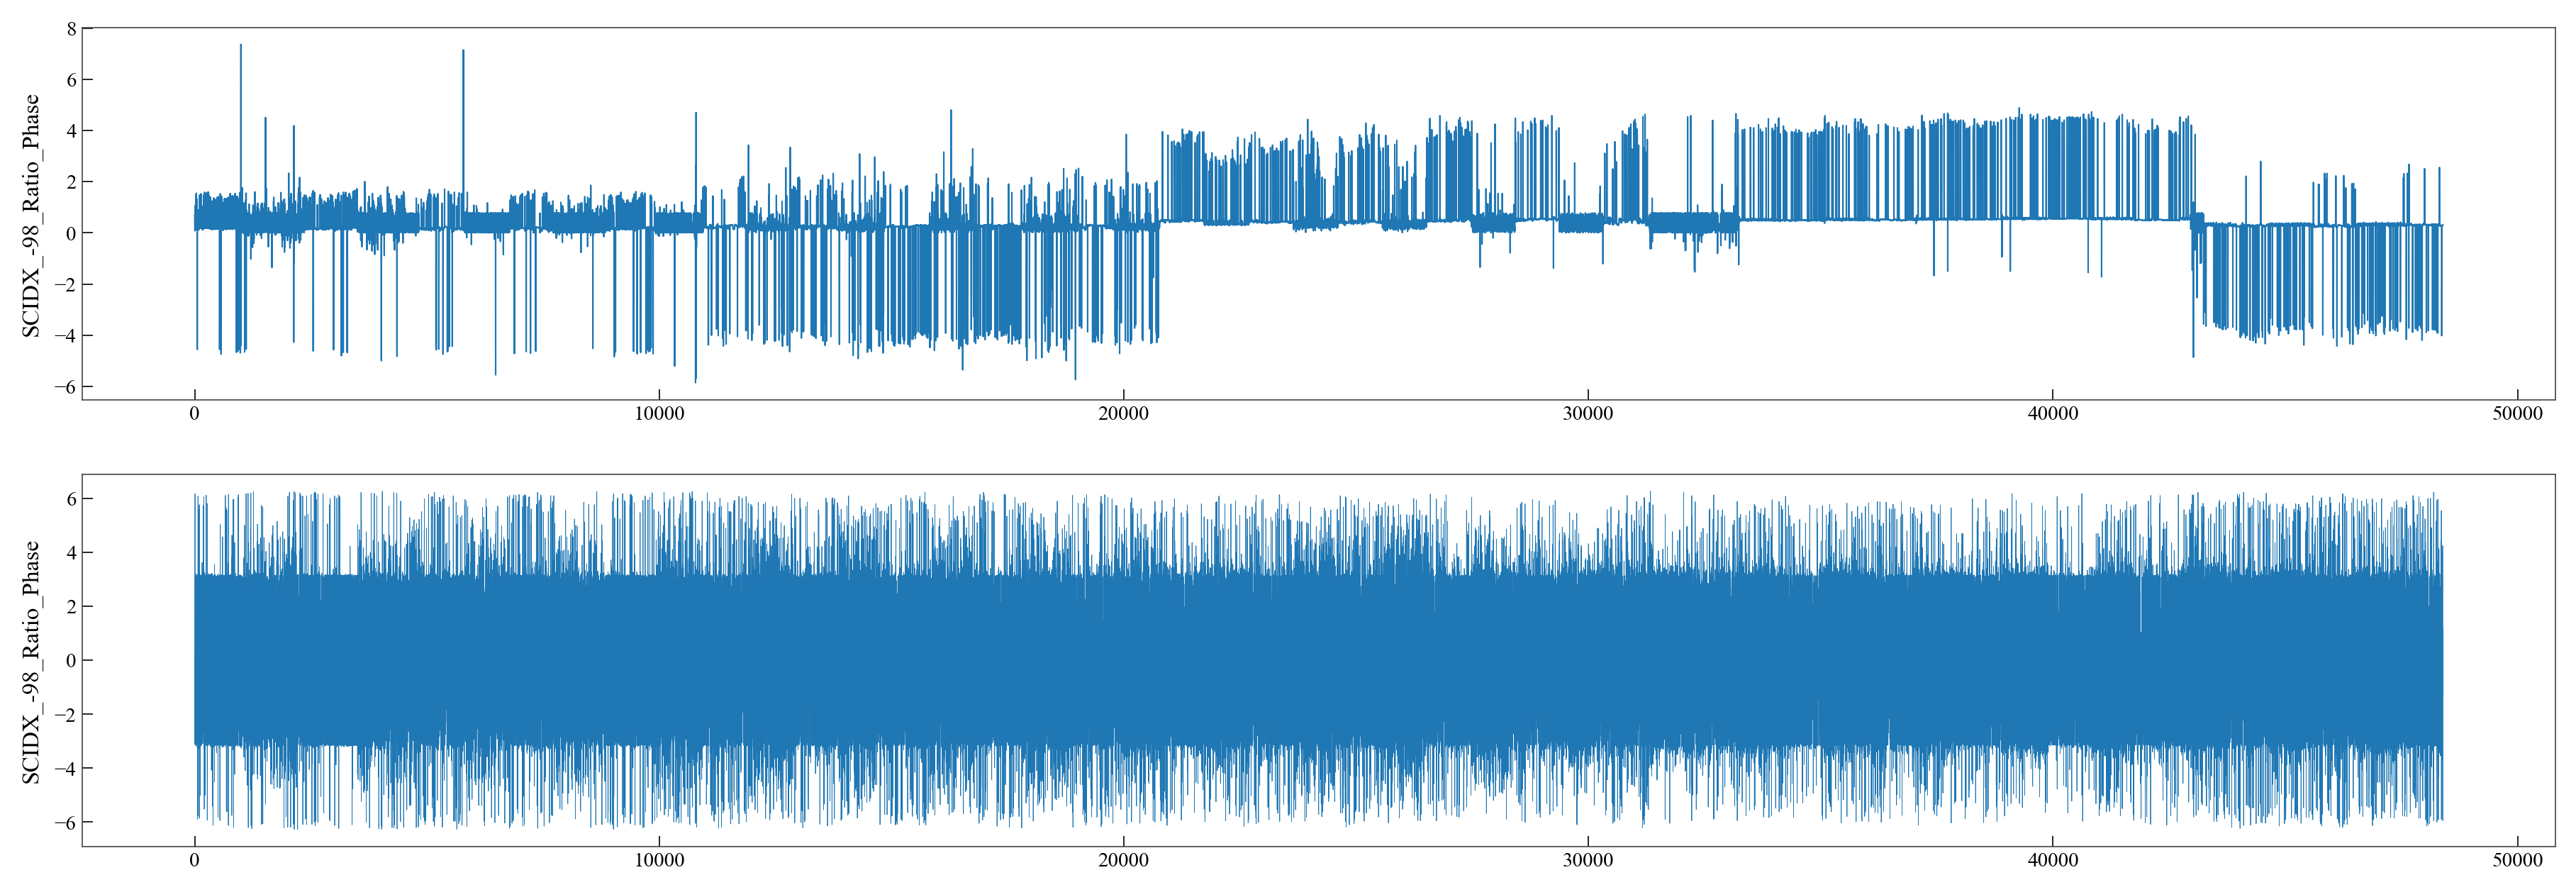

In [137]:
df_foil['pca1'] = pca.fit_transform(df_foil[mag_cols + phase_cols])
df_butter_filtered['pca1'] = pca.fit_transform(df_butter_filtered[mag_cols + phase_cols])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5))

sns.lineplot(x=np.arange(len(df_foil)), y=df_foil[phase_cols[23]], ax=ax1)
sns.lineplot(x=np.arange(len(df_butter_filtered)), y=df_butter_filtered[phase_cols[23]].diff(), ax=ax2, lw=0.2)

(-10.0, 10.0)

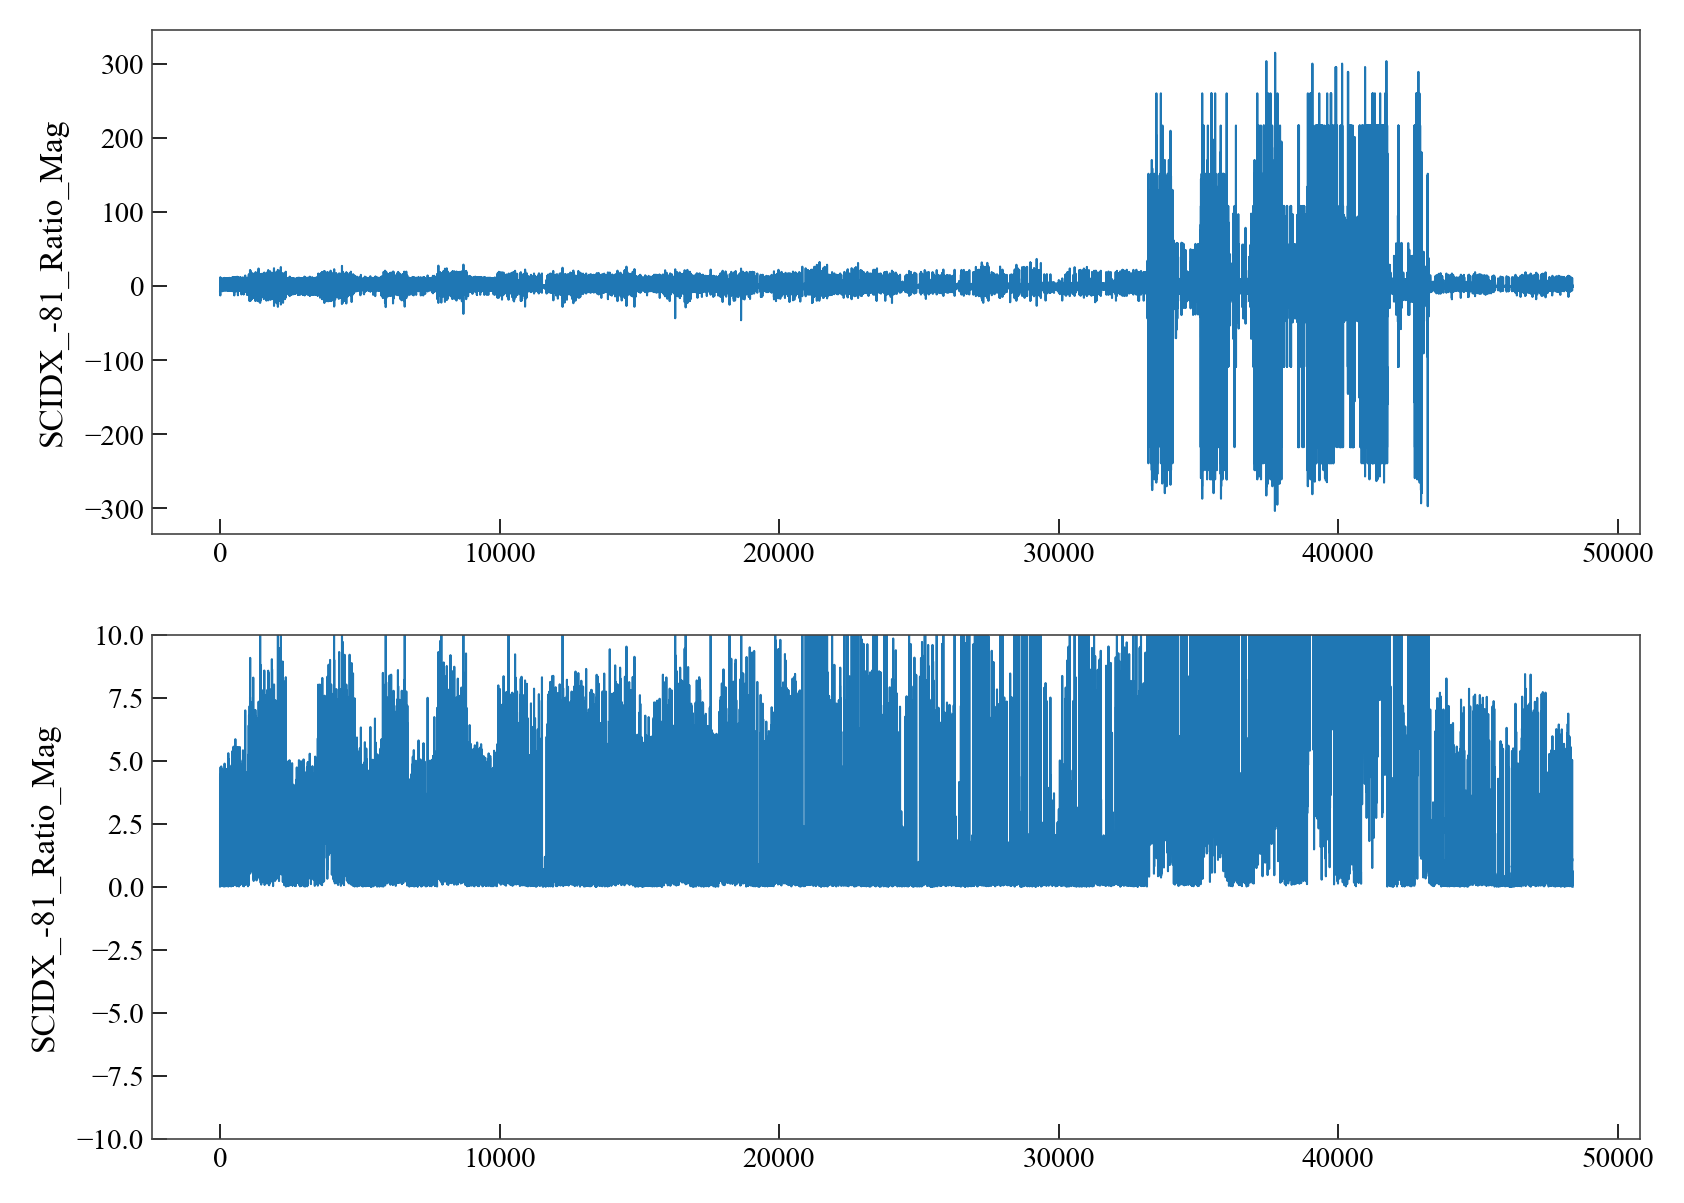

In [138]:
fig, (ax1, ax2) = plt.subplots(2, 1)
sns.lineplot(x=np.arange(len(df_foil)), y=df_foil[mag_cols[40]].diff().diff(), ax=ax1)
sns.lineplot(x=np.arange(len(df_butter_filtered)), y=df_butter_filtered[mag_cols[40]], ax=ax2)
ax2.set_ylim(-10, 10)

In [139]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
from scipy.stats import median_abs_deviation

warnings.filterwarnings('ignore')

# ============================================================================
# CONSTANTS (aligned with Cell 17 pipeline)
# ============================================================================
WINDOW_SIZE_SPREAD = 100   # Lookback for IQR winsorization and MAD scale
WINDOW_SIZE_LOCATION = 100 # Lookback for rolling median (centering baseline)
WINDOW_SIZE_FEATURE = 53   # ~5.3 seconds at 10 Hz
IQR_FACTOR = 1.5
DIFF_ORDER_LOCAL = 3       # 3rd-order difference

FEATURES = ['feature_phase_coherence_jerk']
TARGET = 'activity'

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def calculate_phase_coherence(phase_data):
    """Calculate phase coherence across subcarriers."""
    complex_phases = np.exp(1j * phase_data)
    mean_vector = np.nanmean(complex_phases)
    return np.abs(mean_vector)

def calculate_mad_scale(x):
    """Calculate MAD scale for robust standardization (scipy-consistent)."""
    x_clean = x[~np.isnan(x)]
    if len(x_clean) < 1:
        return np.nan
    return median_abs_deviation(x_clean, scale='normal', nan_policy='omit')

def calculate_log_mean_abs_accel(x):
    """Calculate log of mean absolute 3rd-order differences (LMAD)."""
    x_clean = x[~np.isnan(x)]
    if len(x_clean) < (DIFF_ORDER_LOCAL + 1):
        return np.nan
    
    d = np.diff(x_clean, n=DIFF_ORDER_LOCAL)
    mean_abs_d = np.mean(np.abs(d))
    
    if mean_abs_d == 0:
        return -np.inf
    
    return np.log(mean_abs_d)

def create_r_features_loop(df_in, base_col='Phase_Coherence'):
    """
    Loop-based feature engineering (for exploration/validation).
    Aligned with Cell 17 pipeline: W_SPREAD=100, W_LOCATION=100, W_FEATURE=53, diff_order=3.
    """
    df = df_in.copy()
    df = df.sort_values(by=['session_id', 'timestamp']).reset_index(drop=True)
    
    z_col_name = f"{base_col}_roll_z"
    jerk_col_name = f"feature_{base_col.lower()}_jerk"

    value_col = df[base_col].values
    session_ids = df['session_id'].values
    
    # Initialize output arrays
    roll_winsorized_value = np.full(len(df), np.nan)
    roll_median_winsor = np.full(len(df), np.nan)
    roll_mad_scale_winsor = np.full(len(df), np.nan)
    z_scores = np.full(len(df), np.nan)
    
    # Step 1: Rolling IQR Winsorization
    for session_id in df['session_id'].unique():
        session_mask = session_ids == session_id
        session_indices = np.where(session_mask)[0]
        
        for i, idx in enumerate(session_indices):
            if i == 0:
                roll_winsorized_value[idx] = value_col[idx]
                continue
            
            start_idx = max(0, i - WINDOW_SIZE_SPREAD)
            window_indices = session_indices[start_idx:i]
            window_vals = value_col[window_indices]
            
            if len(window_vals) >= 4:
                q1 = np.nanquantile(window_vals, 0.25)
                q3 = np.nanquantile(window_vals, 0.75)
                iqr = q3 - q1
                
                lower_bound = q1 - IQR_FACTOR * iqr
                upper_bound = q3 + IQR_FACTOR * iqr
                
                roll_winsorized_value[idx] = np.clip(value_col[idx], lower_bound, upper_bound)
            else:
                roll_winsorized_value[idx] = value_col[idx]
    
    df['roll_winsorized_value'] = roll_winsorized_value
    
    # Step 2: Calculate rolling median and MAD on winsorized values
    for session_id in df['session_id'].unique():
        session_mask = session_ids == session_id
        session_indices = np.where(session_mask)[0]
        
        for i, idx in enumerate(session_indices):
            if i == 0:
                continue
            
            # Rolling median (location)
            start_loc = max(0, i - WINDOW_SIZE_LOCATION)
            window_loc_indices = session_indices[start_loc:i]
            window_loc = roll_winsorized_value[window_loc_indices]
            
            if len(window_loc) >= 1:
                roll_median_winsor[idx] = np.nanmedian(window_loc)
            
            # Rolling MAD (spread)
            start_spread = max(0, i - WINDOW_SIZE_SPREAD)
            window_spread_indices = session_indices[start_spread:i]
            window_spread = roll_winsorized_value[window_spread_indices]
            
            if len(window_spread) >= 1:
                roll_mad_scale_winsor[idx] = calculate_mad_scale(window_spread)
    
    # Step 3: Calculate robust z-scores
    for i in range(len(df)):
        if not np.isnan(roll_mad_scale_winsor[i]) and roll_mad_scale_winsor[i] != 0:
            z_scores[i] = (roll_winsorized_value[i] - roll_median_winsor[i]) / roll_mad_scale_winsor[i]
        elif roll_mad_scale_winsor[i] == 0:
            z_scores[i] = 0
    
    df[z_col_name] = z_scores
    
    # Step 4: Calculate LMAD feature from z-scores
    jerk_values = np.full(len(df), np.nan)
    
    for session_id in df['session_id'].unique():
        session_mask = session_ids == session_id
        session_indices = np.where(session_mask)[0]
        
        for i, idx in enumerate(session_indices):
            if i >= WINDOW_SIZE_FEATURE - 1:
                window_start = i - WINDOW_SIZE_FEATURE + 1
                window_indices = session_indices[window_start:i+1]
                window = z_scores[window_indices]
                
                if len(window) == WINDOW_SIZE_FEATURE:
                    jerk_values[idx] = calculate_log_mean_abs_accel(window)
    
    df[jerk_col_name] = jerk_values
    df = df.drop(columns=['roll_winsorized_value'])
    
    return df

def preprocess_data(df_subset, scidx_mag_cols, scidx_phase_cols):
    """
    Apply preprocessing pipeline to a data subset.
    """
    df = df_subset.copy()
    
    # Calculate base features
    df['Magnitude'] = df[scidx_mag_cols].mean(axis=1)
    df['Phase_Coherence'] = df[scidx_phase_cols].apply(calculate_phase_coherence, axis=1)
    pca = PCA(n_components=1)
    df['pca1'] = pca.fit_transform(df[scidx_phase_cols])
    
    # Apply magnitude filter
    df = df[df['Magnitude'] > 5].copy()
    
    if len(df) == 0:
        return df
    
    # Convert timestamp and sort
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values(by=['session_id', 'timestamp']).reset_index(drop=True)
    
    # Feature engineering
    df_features = create_r_features_loop(df, base_col='pca1')
    
    return df_features

In [140]:
df_processed3 = preprocess_data(df_sav_filt, mag_cols, phase_cols)
df_processed4 = preprocess_data(df_median_filt, mag_cols, phase_cols)

In [141]:
df_processed1 = preprocess_data(df, cols['mag_col'], cols['phase_col'])
df_processed2 = preprocess_data(df_filtered, cols['mag_col'], cols['phase_col'])

<Axes: ylabel='feature_pca1_jerk'>

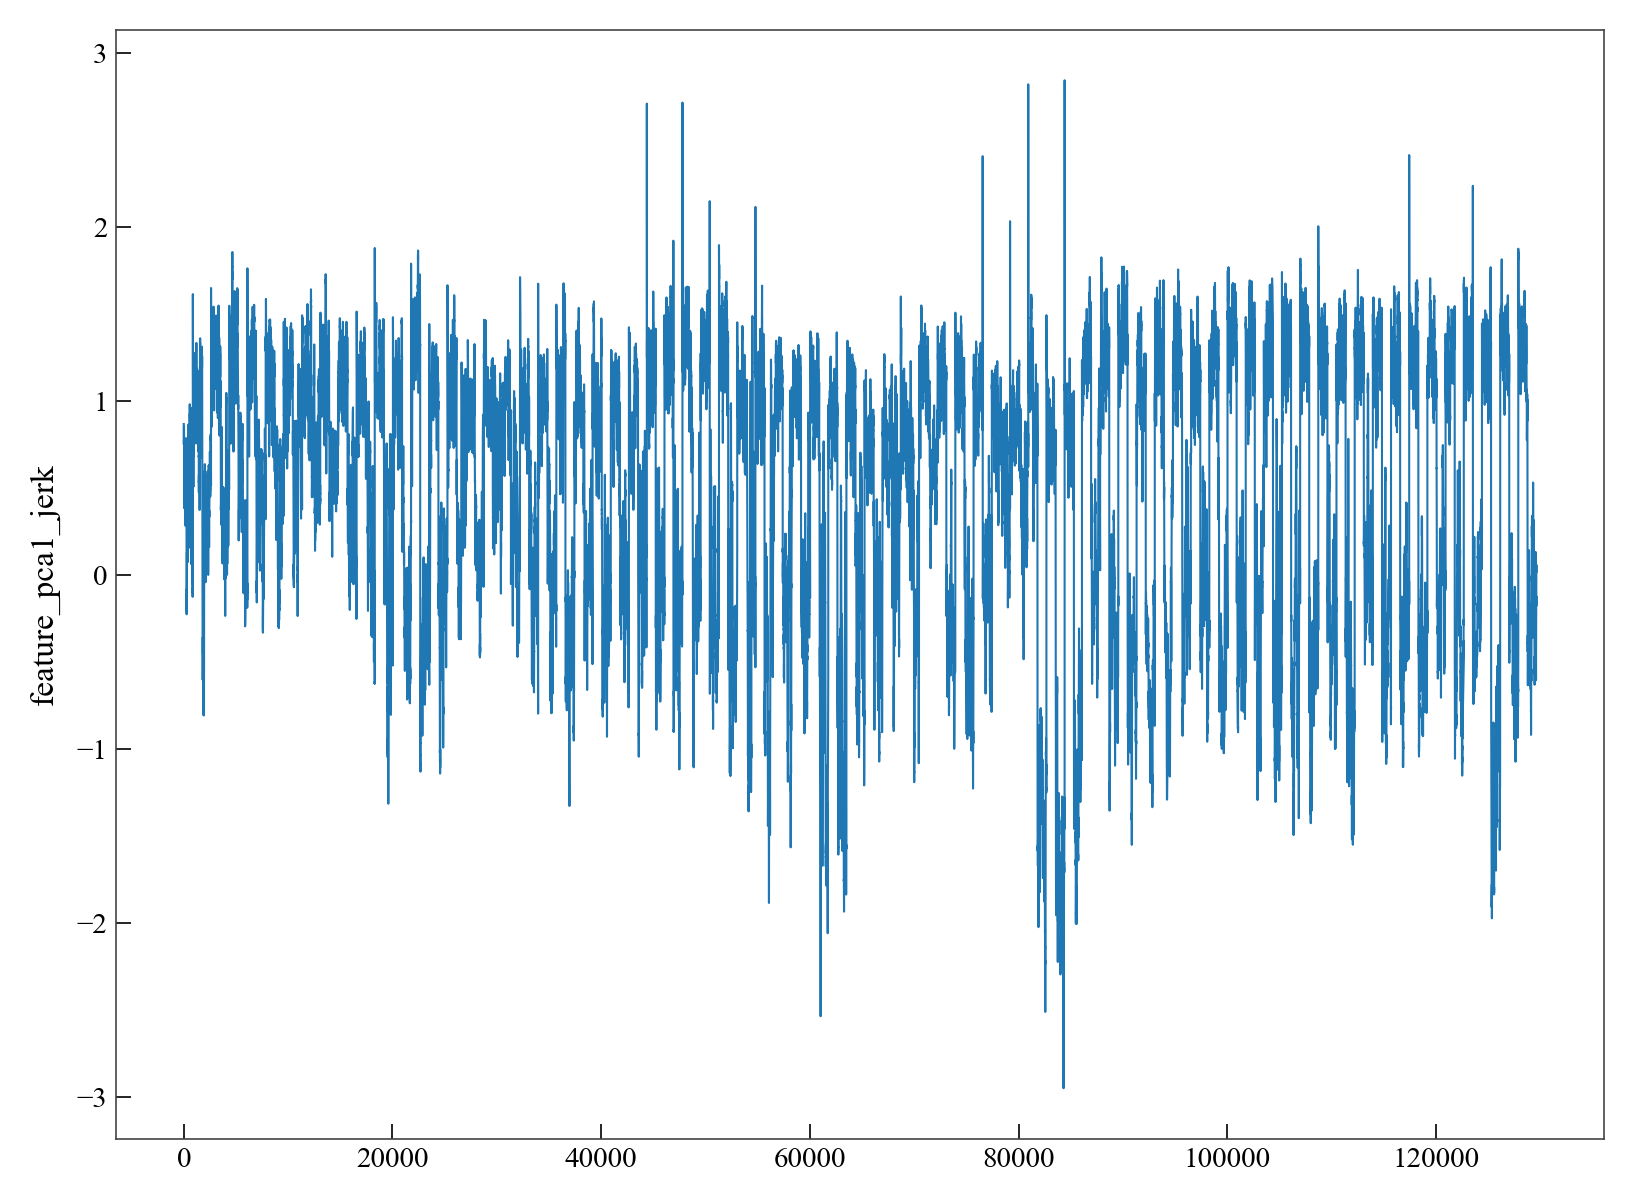

In [142]:
ph_coh = df_processed1.feature_pca1_jerk
ph_coh = ph_coh.dropna()

sns.lineplot(x = np.arange(len(ph_coh)), y = ph_coh)

<Axes: >

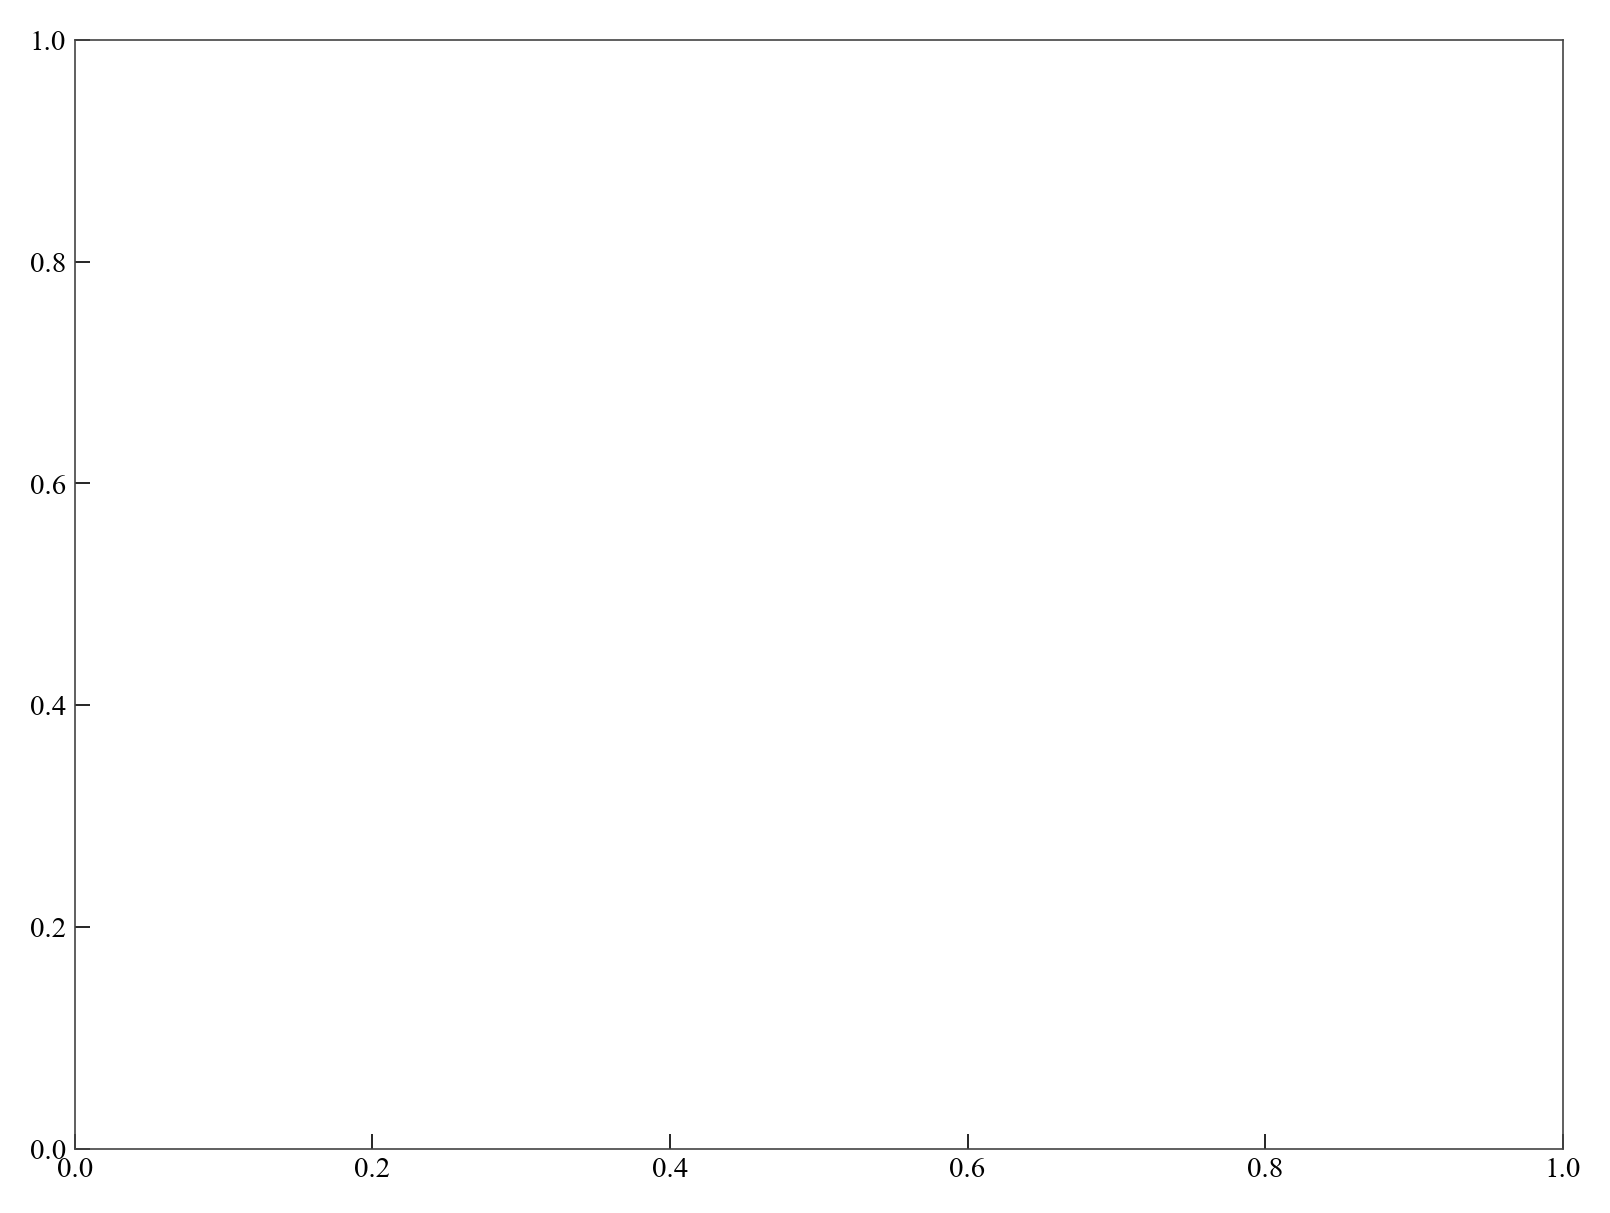

In [143]:
ph_coh = df_processed2.feature_pca1_jerk
ph_coh = ph_coh.dropna()

sns.lineplot(x = np.arange(len(ph_coh)), y = ph_coh)

<Axes: ylabel='Magnitude'>

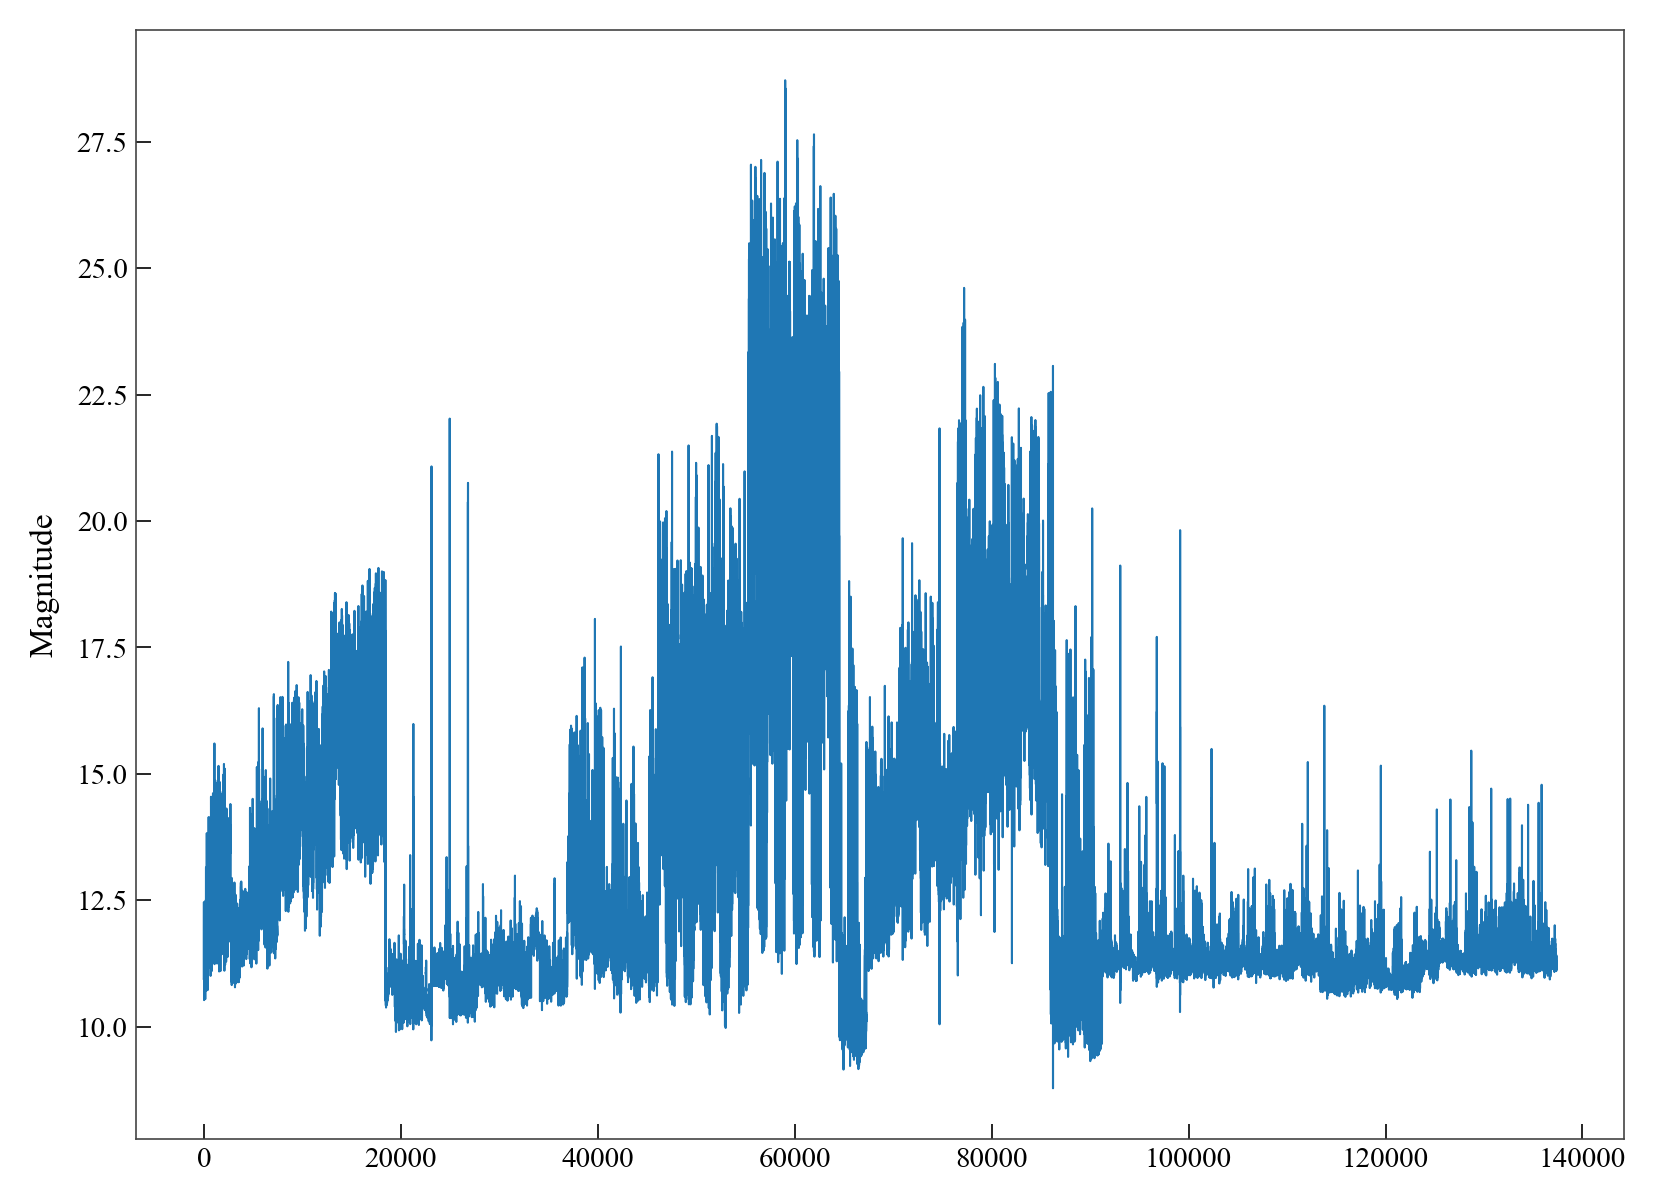

In [144]:
ax = plt.gca()
sns.lineplot(x=np.arange(len(df_processed1)), y=df_processed1.Magnitude, ax=ax)

<Axes: ylabel='Phase_Coherence'>

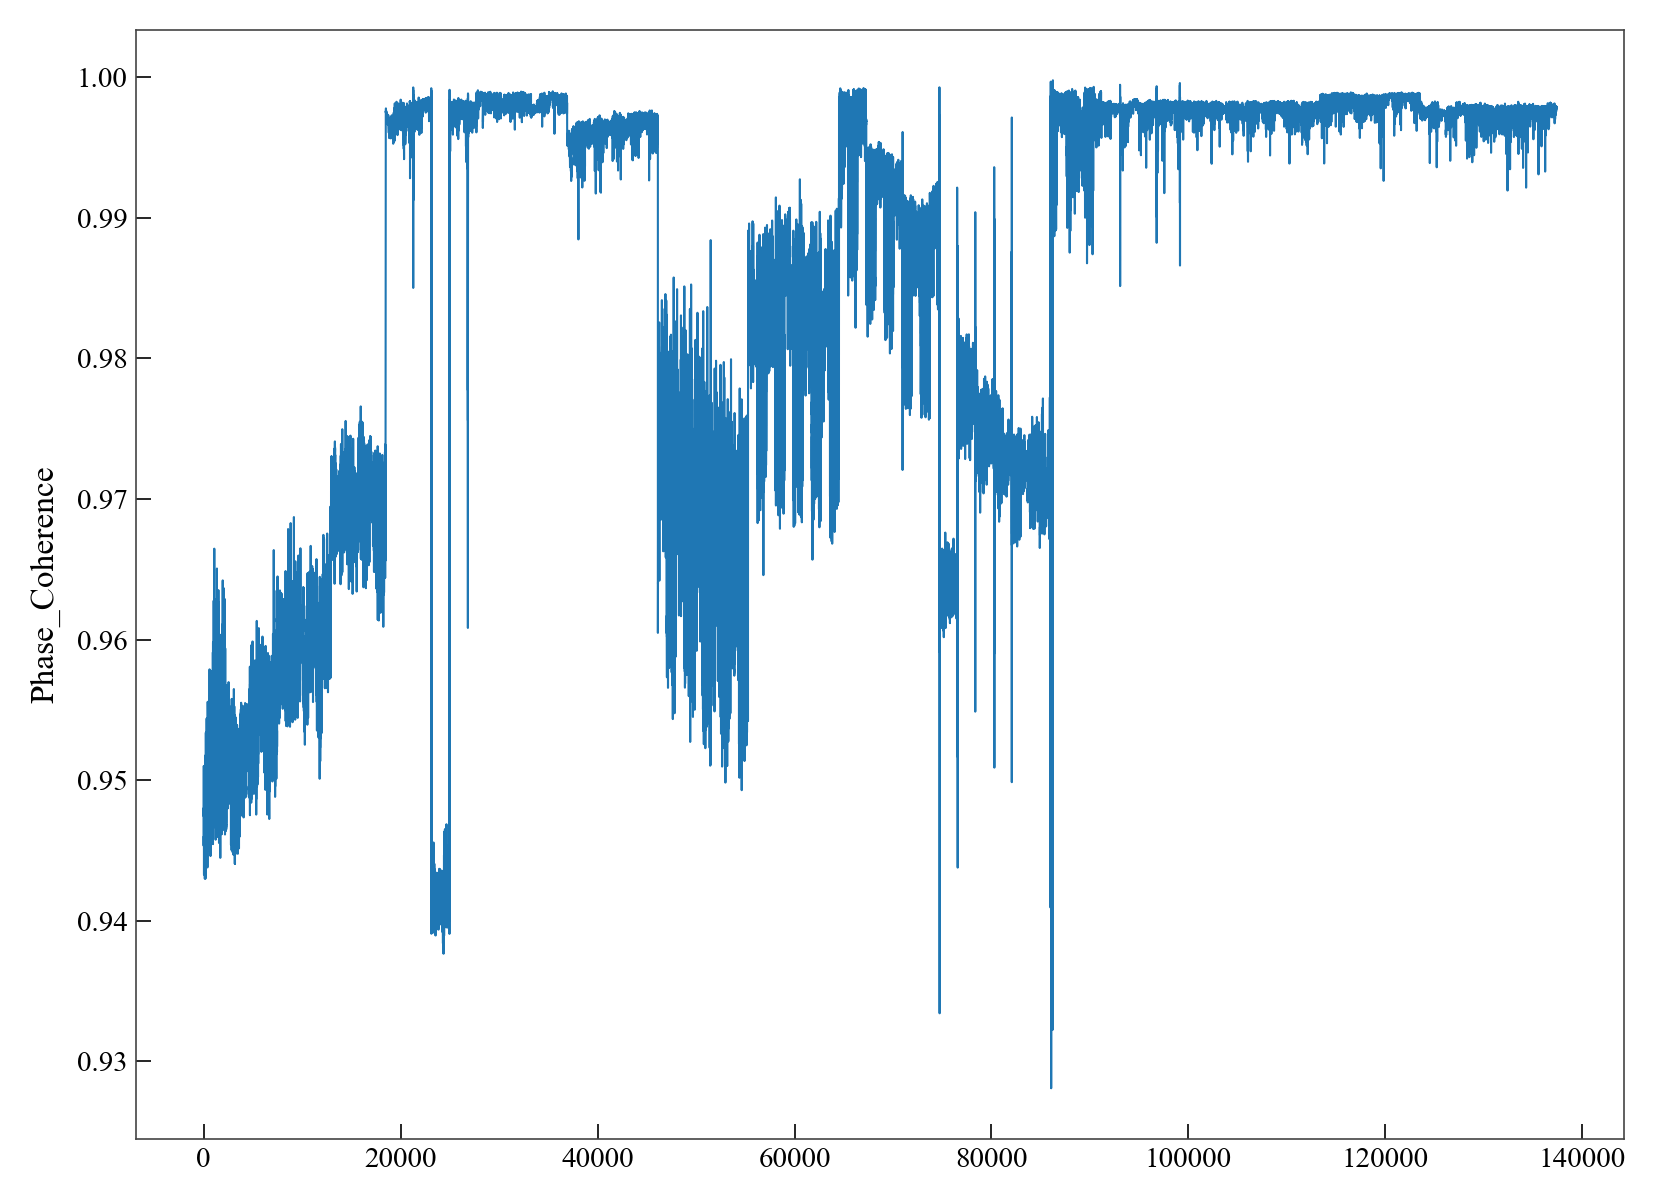

In [145]:
ax = plt.gca()
sns.lineplot(x=np.arange(len(df_processed1)), y=df_processed1.Phase_Coherence, ax=ax)

In [146]:
df.min()[mag_cols]
# df.max()[mag_cols]

SCIDX_-122_Ratio_Mag    0.006136
SCIDX_-121_Ratio_Mag    0.006136
SCIDX_-120_Ratio_Mag     0.05528
SCIDX_-119_Ratio_Mag    0.067598
SCIDX_-118_Ratio_Mag    0.030689
                          ...   
SCIDX_118_Ratio_Mag     0.067598
SCIDX_119_Ratio_Mag     0.067598
SCIDX_120_Ratio_Mag     0.067598
SCIDX_121_Ratio_Mag     0.079937
SCIDX_122_Ratio_Mag     0.079937
Length: 234, dtype: object

(0.0, 50.0)

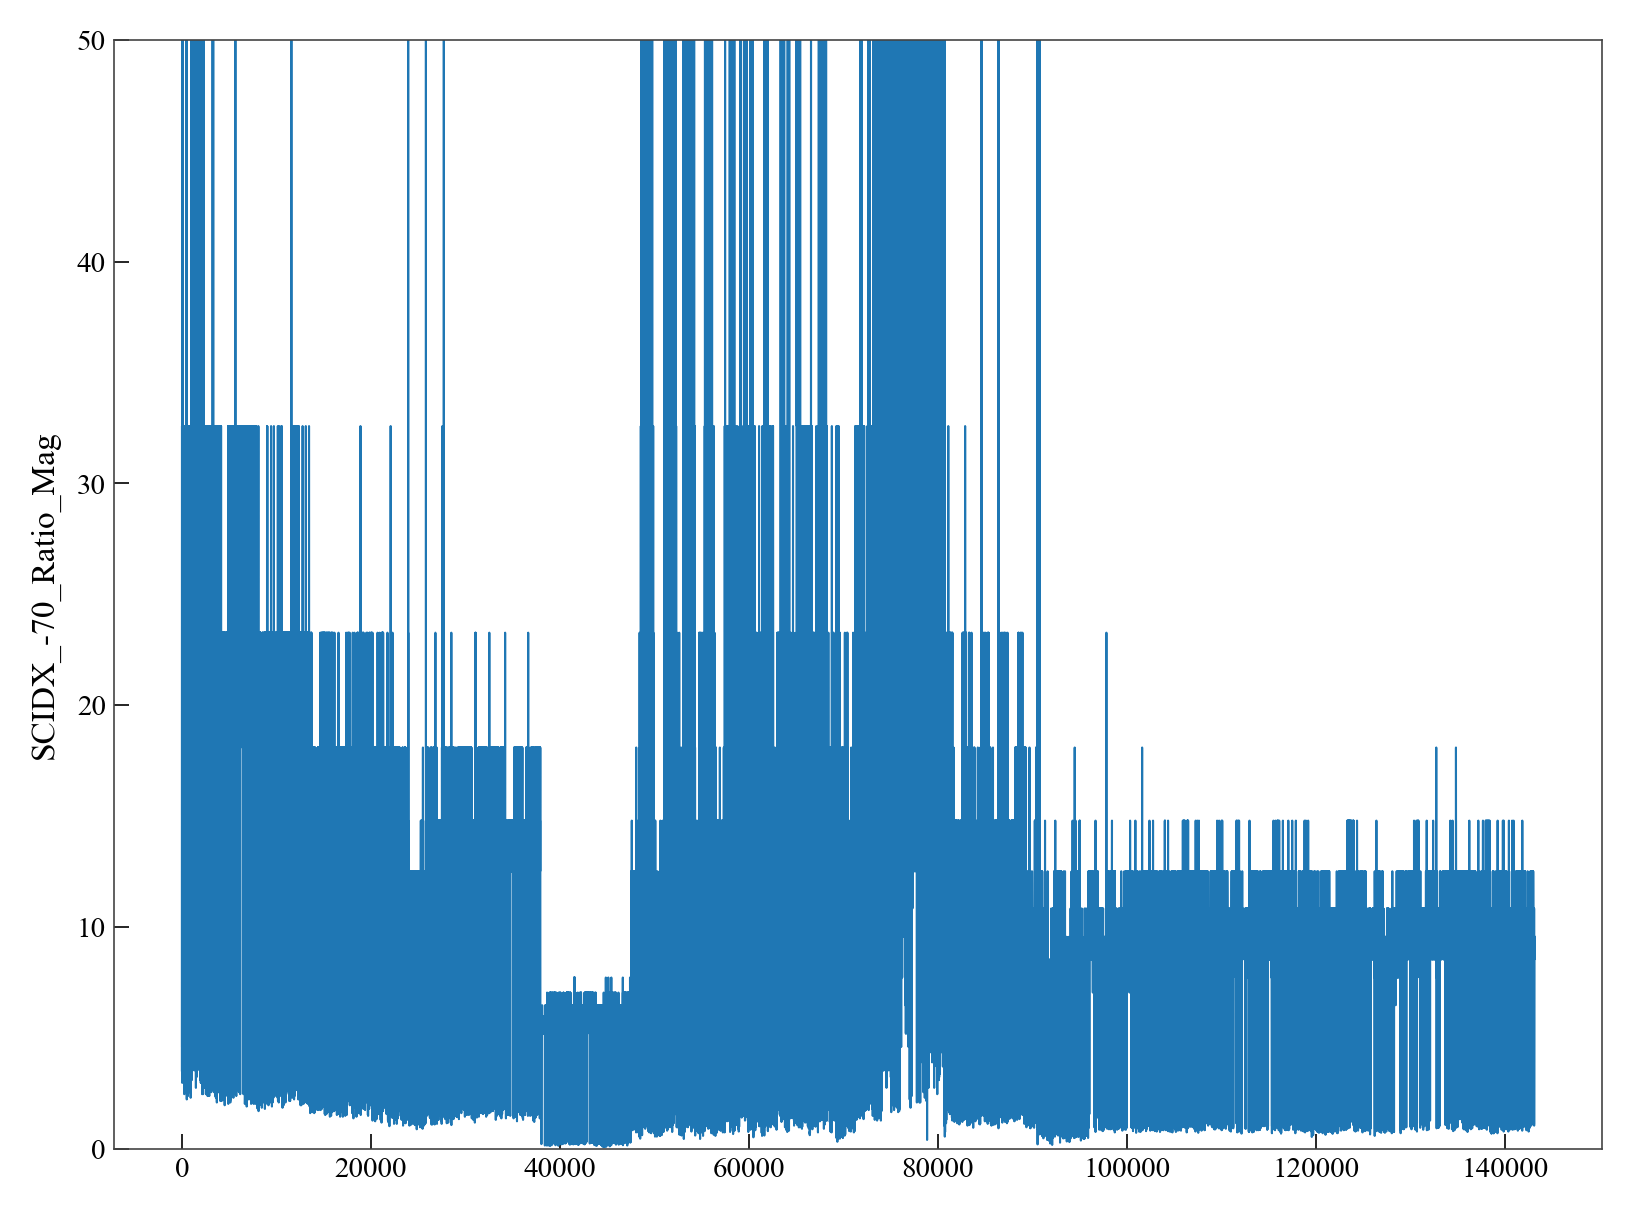

In [147]:


sns.lineplot(x = np.arange(len(df)), y = df['SCIDX_-70_Ratio_Mag'])
plt.ylim(0, 50)

In [148]:
len(cols['phase_scidx'])

234